In [43]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [44]:
import sunpy.map
import os
import re
import pickle
import glob
import matplotlib.pyplot as plt
from tqdm import tqdm
import numpy as np
from astropy.coordinates import SkyCoord
import glob
from astropy import units as u
from sunpy.physics.differential_rotation import solar_rotate_coordinate
import multiprocessing
import matplotlib.patches as mpatches
from skimage.filters import gaussian
from sunpy.coordinates.frames import Helioprojective
from sunpy.map import Map
from astropy.visualization import ImageNormalize
from astropy.io import fits
import eispac
from astropy.visualization import ImageNormalize
import matplotlib.patches as mpatches 
from matplotlib.patches import Rectangle
from iris_get_pfss_utils import hmi_daily_download
import matplotlib.patches as mpatches 
import scipy.ndimage
from matplotlib.colors import Normalize
from astropy.constants import R_sun
from astropy.io import fits
import pprint
from scipy.stats import linregress
from collections import defaultdict
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from sunpy.net import Fido, attrs as a
from sunpy.map import Map
from astropy.time import Time
import astropy.units as u
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib import gridspec
from mpl_toolkits.axes_grid1 import make_axes_locatable
from iris_get_pfss_utils import hmi_daily_download, get_pfss_from_map







In [46]:
iris_dir=  '/home/ug/orlovsd2/intra/pfss'
eis_map = sunpy.map.Map(f'{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_2014_02_05__10_41_27_intensity.fits')
# hmi_map = sunpy.map.Map(f'{iris_dir}_hmi.fits')
# sis_map = sunpy.map.Map(f'{iris_dir}_sis_fip_bias_aligned.fits')
# pfss_pickle = f'{iris_dir}_pfss_fieldlines.pickle'
# fe_12_map = sunpy.map.Map(f'{iris_dir}_fe_12_195_12_aligned.fits')
# # Open and load the pickle file
# with open(pfss_pickle, 'rb') as file:
#     all_lines = pickle.load(file)

# with open(pfss_pickle, 'rb') as file:
#     fieldlines = pickle.load(file)

In [8]:
# Titles

title = {
    "CaAr": "Ca XIV 193.87 Å / Ar XIV 194.40 Å",
    "FeS": "Fe XVI 262.98 Å / S XIII 256.69 Å",
    "sis": "Si X 258.37 Å / S X 264.23 Å",
    "sar": "S XI 188.68 Å / Ar XI 188.81 Å"
}

In [ ]:
plt.rcParams.update({ 
    "font.size": 20,               # Default font size
    "axes.labelsize": 20,          # X/Y axis label size
    "xtick.labelsize": 20,         # X tick labels
    "ytick.labelsize": 20,         # Y tick labels
    "legend.fontsize": 20,         # Legend text 
    "legend.labelspacing": 0.4,    # Legend line spacing
    "axes.titlesize": 20           # Panel title 
}) #scatter and hostrgram

In [26]:
plt.rcParams.update({
    "font.size": 18,               # Default font size
    "axes.labelsize": 18,          # X/Y axis label size
    "xtick.labelsize": 14,         # X tick labels
    "ytick.labelsize": 14,         # Y tick labels
    "legend.fontsize": 20,         # Legend text
    "legend.labelspacing": 0.4,    # Legend line spacing
    "axes.titlesize": 18           # Panel title
}) #compostion maps

In [ ]:
#singuler pfss calc
from iris_get_pfss_utils import hmi_daily_download, get_pfss_from_map
eis_map = hmi_daily_download("2014-02-03")
m_hmi = hmi_daily_download("2014-02-03")  
print(f"Map Data Shape: {eis_map.data.shape}")
print(f"Map Dimensions: {eis_map.dimensions}")
print(f"Min value: {np.nanmin(eis_map.data)}, Max value: {np.nanmax(eis_map.data)}")
print(f"Number of NaN values: {np.isnan(eis_map.data).sum()}")
print(f"Magnetic Field Min: {np.nanmin(eis_map.data)}, Max: {np.nanmax(eis_map.data)}")
print(m_hmi.unit)
import matplotlib.pyplot as plt
print(f"Map Coordinate Frame: {eis_map.coordinate_frame}")
print(f"Bottom Left Coord: {eis_map.bottom_left_coord}")
print(f"Top Right Coord: {eis_map.top_right_coord}")
m_hmi.plot()
plt.show()

open_fieldlines, closed_fieldlines = get_pfss_from_map(eis_map, min_gauss=-5, max_gauss=5, dimension = (1080, 540))



In [ ]:
#singuler pickle
# Extract filename from eis_map
fits_filename = os.path.basename(f'{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_2014_02_03__09_31_34_intensity.fits')
base_name = fits_filename.replace("aligned_", "").replace("_intensity.fits", "")
# pickle_filename = f"test_{iris_dir}/hmi_test_{base_name}_pfss_fieldlines.pickle"

# with open(pickle_filename, 'wb') as f:
#     pickle.dump(fieldlines, f)


open_pickle_filename = f"{iris_dir}/hmi_test_{base_name}_open_fieldlines.pickle"
closed_pickle_filename = f"{iris_dir}/hmi_test_{base_name}_closed_fieldlines.pickle"

with open(open_pickle_filename, 'wb') as f:
    pickle.dump(open_fieldlines, f)

with open(closed_pickle_filename, 'wb') as f:
    pickle.dump(closed_fieldlines, f)

print(f"Saved Open PFSS field lines to: {open_pickle_filename}")
print(f"Saved Closed PFSS field lines to: {closed_pickle_filename}\n")


In [ ]:
#aia map test
import time
from sunpy.net import Fido, attrs as a
import astropy.units as u

# Define the time range
aia_start_str = "2014-02-01T13:26:00"
aia_end_str = "2014-02-01T13:27:00"

# Search for AIA data
search_results = Fido.search(a.Time(aia_start_str, aia_end_str), a.Instrument.aia, a.Wavelength(193*u.angstrom))

# Define the download folder
download_path = "/home/ug/orlovsd2/sunpy/data/"

# Retry mechanism
max_retries = 5
retry_delay = 30  # Seconds

if search_results:
    for attempt in range(max_retries):
        print(f"Attempt {attempt+1} to download missing AIA files...")
        
        aia_downloads = Fido.fetch(search_results, path=download_path)
        
        # Check if all files were downloaded
        missing_files = []
        for file in aia_downloads:
            if not os.path.exists(file):
                missing_files.append(file)
        
        if not missing_files:
            print("All files downloaded successfully.")
            break  # Exit the loop if successful
        else:
            print(f"Some files failed to download: {missing_files}")
            if attempt < max_retries - 1:
                print(f"Retrying in {retry_delay} seconds...")
                time.sleep(retry_delay)
            else:
                print("Max retries reached. Some files are still missing.")
else:
    print("No AIA data found for this time range.")


In [ ]:
# Get a list of all existing pickles
existing_pickles = glob.glob(f"{iris_dir}/*.pickle")

# Extract base filenames ONLY if both open and closed field line files exist
# processed_files = set()

# for p in existing_pickles:
#     base_name = os.path.basename(p).replace("_open_fieldlines.pickle", "").replace("_closed_fieldlines.pickle", "")
    
#     open_pickle = f"{iris_dir}/{base_name}_open_fieldlines.pickle"
#     closed_pickle = f"{iris_dir}/{base_name}_closed_fieldlines.pickle"
    
#     if os.path.exists(open_pickle) and os.path.exists(closed_pickle):
#         processed_files.add(base_name)

# Extract base names from ONLY those that start with "correct_eis_"
base_names = set()
for path in existing_pickles:
    filename = os.path.basename(path)
    if filename.startswith("correct_eis_") and "_open_fieldlines.pickle" in filename:
        base = filename.replace("_open_fieldlines.pickle", "")
    elif filename.startswith("correct_eis_") and "_closed_fieldlines.pickle" in filename:
        base = filename.replace("_closed_fieldlines.pickle", "")
    else:
        continue
    base_names.add(base)

# Confirm both open and closed versions exist
processed_files = set()
for base in base_names:
    open_path = f"{iris_dir}/{base}_open_fieldlines.pickle"
    closed_path = f"{iris_dir}/{base}_closed_fieldlines.pickle"
    if os.path.exists(open_path) and os.path.exists(closed_path):
        processed_files.add(base)

# Print the list of fully processed files
print("Processed files detected:")
for file in sorted(processed_files):
    print(file)

2025-12-23 08:36:02 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2025-12-23 08:36:02 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


Processing: /home/ug/orlovsd2/intra/pfss/aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


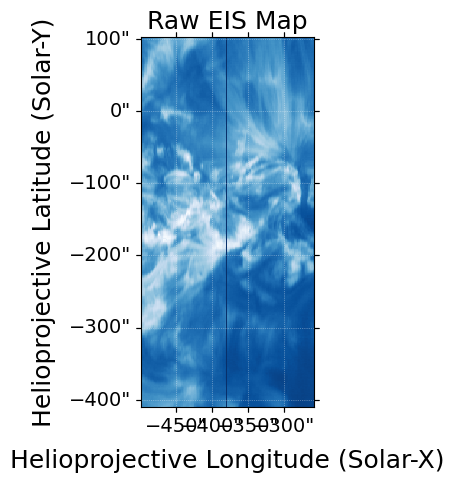

EIS map shape: (512, 120)
WCS dimensions: PixelPair(x=<Quantity 120. pix>, y=<Quantity 512. pix>)
Finding Data...
Results from 1 Provider:

1 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

         T_REC          TELESCOP  INSTRUME WAVELNTH CAR_ROT
----------------------- -------- --------- -------- -------
2014.02.01_12:00:00_TAI  SDO/HMI HMI_SIDE1   6173.0    2146




2025-12-23 08:36:16 - drms - INFO: Export request pending. [id=JSOC_20251223_003216_X_IN, status=2]
2025-12-23 08:36:16 - drms - INFO: Waiting for 0 seconds...
2025-12-23 08:36:16 - sunpy - INFO: 1 URLs found for download. Full request totaling 20MB


INFO: 1 URLs found for download. Full request totaling 20MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Transforming Data to the Correct Frame...
HMI Daily Synoptic Map captured at: 2014-02-01T11:55:30.410
Finding Data...
Results from 1 Provider:

1 Results from the JSOCClient:
Source: http://jsoc.stanford.edu

         T_REC          TELESCOP  INSTRUME WAVELNTH CAR_ROT
----------------------- -------- --------- -------- -------
2014.01.31_12:00:00_TAI  SDO/HMI HMI_SIDE1   6173.0    2146




2025-12-23 08:36:30 - drms - INFO: Export request pending. [id=JSOC_20251223_003219_X_IN, status=2]
2025-12-23 08:36:30 - drms - INFO: Waiting for 0 seconds...
2025-12-23 08:36:31 - drms - INFO: Export request pending. [id=JSOC_20251223_003219_X_IN, status=1]
2025-12-23 08:36:31 - drms - INFO: Waiting for 5 seconds...
2025-12-23 08:36:36 - sunpy - INFO: 1 URLs found for download. Full request totaling 20MB


INFO: 1 URLs found for download. Full request totaling 20MB [sunpy.net.jsoc.jsoc]


Files Downloaded:   0%|          | 0/1 [00:00<?, ?file/s]

Transforming Data to the Correct Frame...
HMI Daily Synoptic Map captured at: 2014-01-31T11:55:30.342
Selected HMI date: 2014-02-01T11:55:30.410 (closer to EIS time 2014-02-01T10:50:35.000)


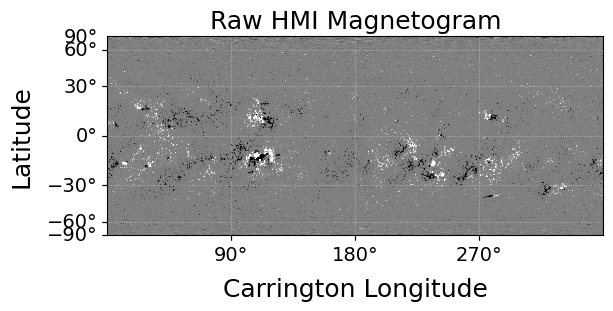

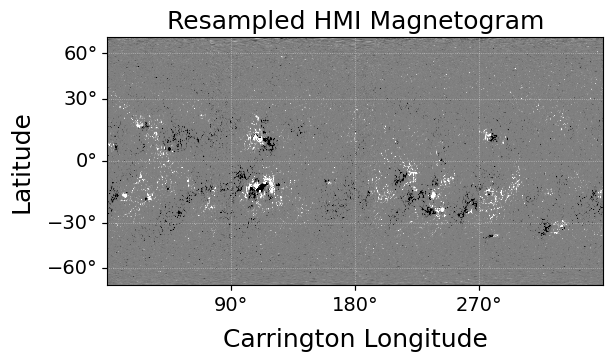

===== FRAME COMPARISON =====
EIS observer: <SkyCoord (HeliographicStonyhurst: obstime=2014-02-01T10:50:35.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (7.3028017e-15, -6.04608623, 1.4741572e+11)>
EIS obstime: 2014-02-01T10:50:35.000
HMI observer: <SkyCoord (HeliographicStonyhurst: obstime=2014-02-01T11:55:30.410, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (120.06084864, -6.04156113, 1.47433292e+11)>
HMI obstime: 2014-02-01T11:55:30.410
EIS coordinate frame: <Helioprojective Frame (obstime=2014-02-01T10:50:35.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2014-02-01T10:50:35.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (7.3028017e-15, -6.04608623, 1.4741572e+11)>)>
HMI coordinate frame: <HeliographicCarrington Frame (obstime=2014-02-01T11:55:30.410, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2014-02-01T11:55:30.410, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (12

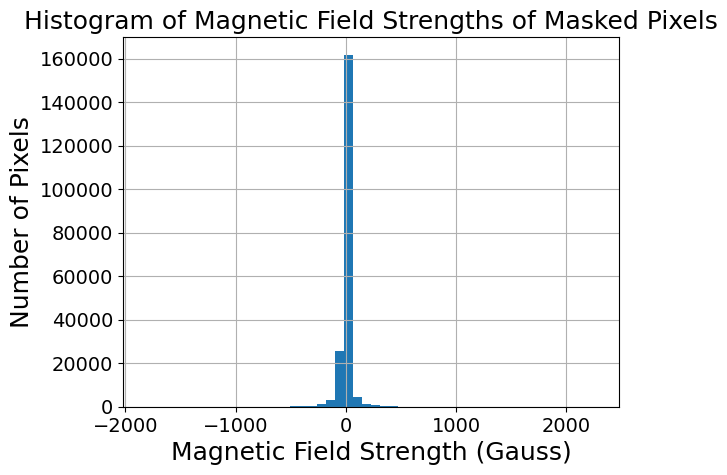

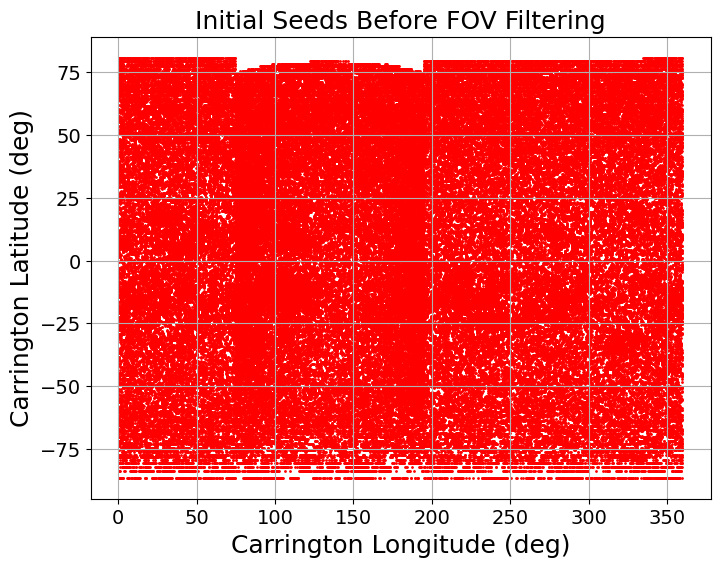

Number of initial seed points: 199858


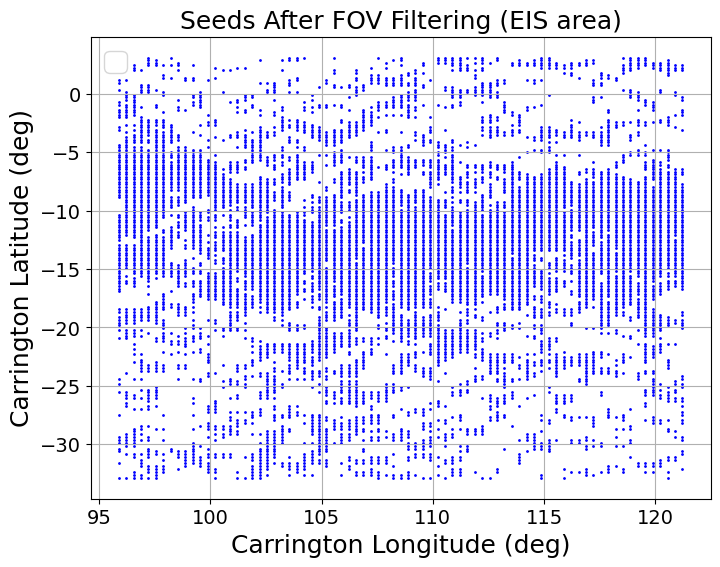

Number of seeds after FOV filtering: 6397
processing fieldlines
Fieldlines with empty coords: 172 / 6397
Δ Carrington Lon after rotation: -0.00612362633954433 deg
Δ Carrington Lat after rotation: -3.552713678800501e-15 deg


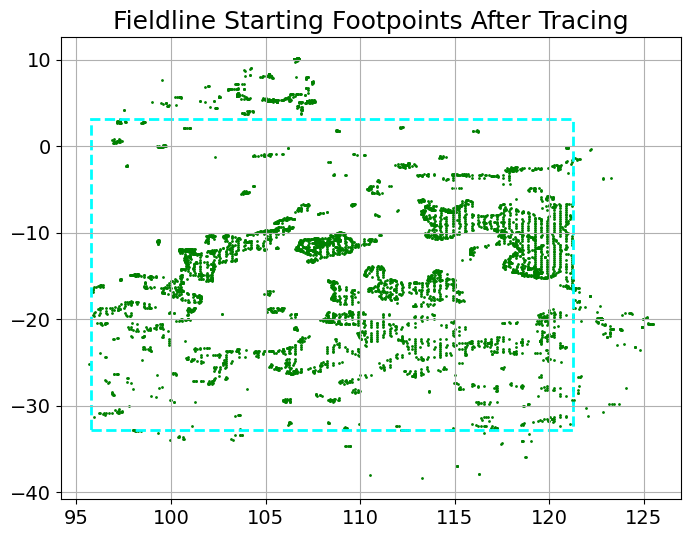

Adding seed metadata to fieldlines...
Seed frame before transformation: heliographic_carrington
Map frame (EIS): <Helioprojective Frame (obstime=2014-02-01T10:50:35.000, rsun=695700.0 km, observer=<HeliographicStonyhurst Coordinate (obstime=2014-02-01T10:50:35.000, rsun=695700.0 km): (lon, lat, radius) in (deg, deg, m)
    (7.3028017e-15, -6.04608623, 1.4741572e+11)>)>
Sample seed Carrington lon/lat before transform: 95.88333333333416 -32.860302864142064
Sample seed Solar-X/Y after transform: -513.476 arcsec -459.593 arcsec
Seed 0 world coordinate (Tx, Ty): -513.476 arcsec -459.593 arcsec
Mapped to pixel: PixelPair(x=<Quantity -7.71915017 pix>, y=<Quantity -50.30923492 pix>)
x_pix range: -56.787244888313225 pix to 153.2517342529513 pix
y_pix range: -50.30923492414284 pix to 560.8136676682648 pix
Map shape (Y, X): (512, 120)
Skipped 0 fieldlines due to invalid pixel mapping.
Fieldlines with valid length metadata: 6397 / 6397
Fieldlines with valid mean_B metadata: 6225 / 6397
Fieldlines 

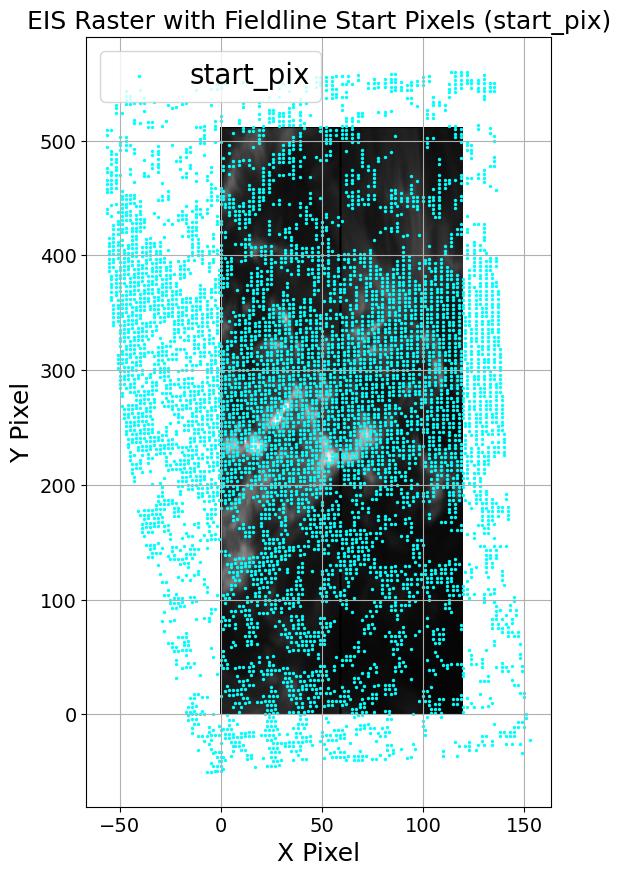

Pixel (0,0) round-trip lands at: (-7.480804864457014e-11 pix, -1.3986256597320335e-11 pix)


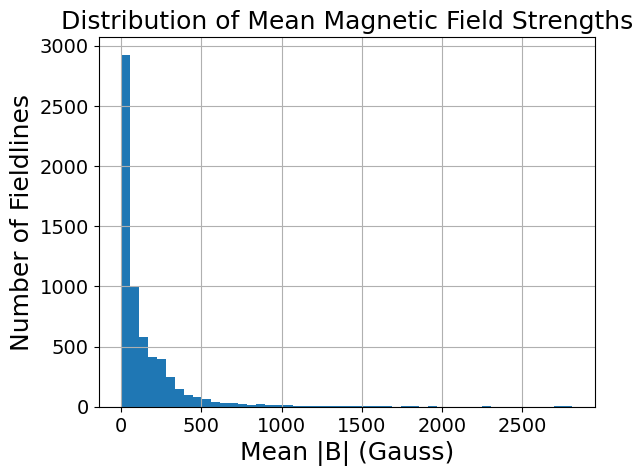

Total field lines: 6397
Open field lines: 0
Closed field lines: 6397
Saving 0 open field lines to /home/ug/orlovsd2/intra/pfss/adjusted_eis_2014_02_01__10_50_35_open_fieldlines.pickle
Saving 6397 closed field lines to /home/ug/orlovsd2/intra/pfss/adjusted_eis_2014_02_01__10_50_35_closed_fieldlines.pickle
Processing: /home/ug/orlovsd2/intra/pfss/aligned_fe12_intensity_maps/aligned_eis_2014_02_01__12_54_41_intensity.fits
Processing: /home/ug/orlovsd2/intra/pfss/aligned_fe12_intensity_maps/aligned_eis_2014_02_02__10_25_27_intensity.fits
Processing: /home/ug/orlovsd2/intra/pfss/aligned_fe12_intensity_maps/aligned_eis_2014_02_02__12_29_34_intensity.fits
Processing: /home/ug/orlovsd2/intra/pfss/aligned_fe12_intensity_maps/aligned_eis_2014_02_02__14_19_52_intensity.fits
Processing: /home/ug/orlovsd2/intra/pfss/aligned_fe12_intensity_maps/aligned_eis_2014_02_03__09_31_34_intensity.fits
Processing: /home/ug/orlovsd2/intra/pfss/aligned_fe12_intensity_maps/aligned_eis_2014_02_03__11_35_40_intensi

In [8]:
# automated pickle test_target = "2014_02_01__10_50_35"

from iris_get_pfss_utils import get_pfss_from_map, get_closest_aia

test_mode = False
test_target = "2014_02_01__10_50_35"

intensity_maps_dir = f"{iris_dir}/aligned_fe12_intensity_maps"
fits_files = sorted(glob.glob(f"{intensity_maps_dir}/*.fits"))

for fits_file in fits_files:
    print(f"Processing: {fits_file}")
    base_name = os.path.basename(fits_file).replace("aligned_", "").replace("_intensity.fits", "")

    if test_mode and test_target not in base_name:
        continue  # Skip all files except the test_target
    
    open_pickle_filename = f"{iris_dir}/adjusted_{base_name}_open_fieldlines.pickle"
    closed_pickle_filename = f"{iris_dir}/adjusted_{base_name}_closed_fieldlines.pickle"
    
    # if os.path.exists(open_pickle_filename) and os.path.exists(closed_pickle_filename):
    #     print(f"Skipping {fits_file}, already processed.")
    #     continue  # Skip to the next file

    eis_map = sunpy.map.Map(fits_file) #sunpy.map specialises in handeling 2D solar images, .Map takesin input and makes a proper solar image object
    
    open_fieldlines, closed_fieldlines = get_pfss_from_map(eis_map, min_gauss=-5, max_gauss=5, dimension=(1080, 540))

    print(f"Saving {len(open_fieldlines)} open field lines to {open_pickle_filename}")
    print(f"Saving {len(closed_fieldlines)} closed field lines to {closed_pickle_filename}")
    

    with open(open_pickle_filename, 'wb') as f:
        pickle.dump(open_fieldlines, f)

    with open(closed_pickle_filename, 'wb') as f:
        pickle.dump(closed_fieldlines, f)

In [ ]:
# automated pickle test_target = "2014_02_05__10_41_27"

from iris_get_pfss_utils import get_pfss_from_map, get_closest_aia

test_mode = True
test_target = "2014_02_05__10_41_27"

intensity_maps_dir = f"{iris_dir}/aligned_fe12_intensity_maps"
fits_files = sorted(glob.glob(f"{intensity_maps_dir}/*.fits"))

for fits_file in fits_files:
    print(f"Processing: {fits_file}")
    base_name = os.path.basename(fits_file).replace("aligned_", "").replace("_intensity.fits", "")

    if test_mode and test_target not in base_name:
        continue  # Skip all files except the test_target
    
    open_pickle_filename = f"{iris_dir}/adjusted_{base_name}_open_fieldlines.pickle"
    closed_pickle_filename = f"{iris_dir}/adjusted_{base_name}_closed_fieldlines.pickle"
    
    # if os.path.exists(open_pickle_filename) and os.path.exists(closed_pickle_filename):
    #     print(f"Skipping {fits_file}, already processed.")
    #     continue  # Skip to the next file

    eis_map = sunpy.map.Map(fits_file) #sunpy.map specialises in handeling 2D solar images, .Map takesin input and makes a proper solar image object
    
    open_fieldlines, closed_fieldlines = get_pfss_from_map(eis_map, min_gauss=-5, max_gauss=5, dimension=(1080, 540))

    print(f"Saving {len(open_fieldlines)} open field lines to {open_pickle_filename}")
    print(f"Saving {len(closed_fieldlines)} closed field lines to {closed_pickle_filename}")
    

    with open(open_pickle_filename, 'wb') as f:
        pickle.dump(open_fieldlines, f)


    with open(closed_pickle_filename, 'wb') as f:
        pickle.dump(closed_fieldlines, f)

In [57]:
# Load open and closed fieldlines from pickle

# open_pickle_filename = f"{iris_dir}/adjusted_eis_2014_02_01__10_50_35_open_fieldlines.pickle"
# closed_pickle_filename = f"{iris_dir}/adjusted_eis_2014_02_01__10_50_35_closed_fieldlines.pickle"
open_pickle_filename = f"{iris_dir}/adjusted_eis_2014_02_05__10_41_27_open_fieldlines.pickle"
closed_pickle_filename = f"{iris_dir}/adjusted_eis_2014_02_05__10_41_27_closed_fieldlines.pickle"

# Load the open field lines
with open(open_pickle_filename, "rb") as f:
    open_fieldlines = pickle.load(f)

# Load the closed field lines
with open(closed_pickle_filename, "rb") as f:
    closed_fieldlines = pickle.load(f)

# Load the AIA map
width_map = sunpy.map.Map(f'{iris_dir}/AIA/aia.lev1.193A_2014_02_05T10_41_30.84Z.image_lev1.fits')



In [58]:
# Define functions to change the observer time and frame
change_obstime = lambda x,y: SkyCoord(x.replicate(observer=x.observer.replicate(obstime=y), obstime=y))
change_obstime_frame = lambda x,y: x.replicate_without_data(observer=x.observer.replicate(obstime=y), obstime=y)


In [ ]:
# PFSS field lines on top of the composition map single

from astropy.visualization import ImageNormalize

open_pickle_filename = f"{iris_dir}/eis_2014_02_01__10_50_35_open_fieldlines.pickle"
closed_pickle_filename = f"{iris_dir}/eis_2014_02_01__10_50_35_closed_fieldlines.pickle"

# Load the open field lines
with open(open_pickle_filename, "rb") as f:
    open_fieldlines = pickle.load(f)

# Load the closed field lines
with open(closed_pickle_filename, "rb") as f:
    closed_fieldlines = pickle.load(f)

composition_map_path = f"{iris_dir}/results/eis_20140201_105035/eis_20140201_105035_CaAr.fits"
aligned_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"

# Define functions to change the observer time and frame
change_obstime = lambda x,y: SkyCoord(x.replicate(observer=x.observer.replicate(obstime=y), obstime=y))
change_obstime_frame = lambda x,y: x.replicate_without_data(observer=x.observer.replicate(obstime=y), obstime=y)

# Load the aligned Fe XII intensity FITS file to extract the header
fe12_map = sunpy.map.Map(aligned_fits_path)
header_fe12 = fe12_map.meta

# Load the composition map using the extracted header
composition_data = sunpy.map.Map(composition_map_path).data  # Use only data
composition_map = sunpy.map.Map(composition_data, header_fe12)  # Create new SunPy map
norm = ImageNormalize(vmin=1, vmax=4)
fig = plt.figure(figsize=(5,5))
print(f"Composition Map Data - Min: {np.nanmin(composition_map.data)}, Max: {np.nanmax(composition_map.data)}")

graph_name = os.path.basename(composition_map_path).replace(".fits", "") + "_fieldlines"

for i, m in enumerate([composition_map]):
    ax = fig.add_subplot(1,1,i+1,projection=m)
    im = composition_map.plot(axes=ax, vmin=1, vmax=4, cmap='viridis')
    plt.colorbar(im, ax=ax, label="CaAr Ratio")  # Add color bar
    # m.plot()
    bounds = ax.axis()
    ax.set_title(f'CaAr Composition Map - {graph_name}', fontsize=15)
    ax.set_xlabel('Solar-X (arcsec)', fontsize=10)
    ax.set_ylabel('Solar-Y (arcsec)', fontsize=10)
    ax.tick_params(axis='both', labelsize=10)

    if closed_fieldlines:
        for c in tqdm(closed_fieldlines[::50], desc="Plotting closed field lines"):
            coords = c.coords
            if coords.shape[0] > 0:
                coords_updated = change_obstime(coords, m.date)
                ax.plot_coord(coords_updated, lw=0.5, color='white', alpha=0.8)

    # Plot open field lines in blue
    if open_fieldlines:
        for c in tqdm(open_fieldlines[::2], desc="Plotting open field lines"):
            coords = c.coords
            if coords.shape[0] > 0:
                coords_updated = change_obstime(coords, m.date)
                ax.plot_coord(coords_updated, lw=0.5, color='blue', alpha=0.8)


    ax.axis(bounds)


# fig.savefig('Daves_IRIS_paper_PFSS.pdf',dpi=150)
plt.tight_layout(pad=0)
plt.savefig(f'composition_map_{graph_name}.png', dpi=150)
plt.show()

print(f'Saved as composition_map_{graph_name}.png')

In [ ]:
# PFSS field lines on top of the composition map automated


# Define functions to change the observer time and frame
change_obstime = lambda x, y: SkyCoord(x.replicate(observer=x.observer.replicate(obstime=y), obstime=y))
change_obstime_frame = lambda x, y: x.replicate_without_data(observer=x.observer.replicate(obstime=y), obstime=y)


def plot_pfss_on_all_composition_maps(date_time):
    # Convert date_time to match results folder format (2014_02_01__10_50_35 → 20140201_105035)
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    print(converted_date_time)
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    open_pickle_filename = f"{iris_dir}/eis_{date_time}_open_fieldlines.pickle"
    closed_pickle_filename = f"{iris_dir}/eis_{date_time}_closed_fieldlines.pickle"
    aligned_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"

    with open(open_pickle_filename, "rb") as f:
        open_fieldlines = pickle.load(f)

    with open(closed_pickle_filename, "rb") as f:
        closed_fieldlines = pickle.load(f)

    fe12_map = sunpy.map.Map(aligned_fits_path)
    header_fe12 = fe12_map.meta

    # Find all composition maps in the results directory (CaAr, FeS, sar, sis)
    composition_files = [f for f in os.listdir(results_dir) if f.endswith(".fits") and "_composition_" not in f]

    # Process each composition map
    for comp_filename in composition_files:
        comp_path = os.path.join(results_dir, comp_filename)
        
        element = comp_filename.split("_")[-1].replace(".fits", "")

        composition_data = sunpy.map.Map(comp_path).data
        composition_map = sunpy.map.Map(composition_data, header_fe12)

        if element == "sar":
            norm = ImageNormalize(vmin=1, vmax=1.5)
        else:
            norm = ImageNormalize(vmin=1, vmax=4)


        fig = plt.figure(figsize=(5, 5))
        print(f"Processing {element} - Min: {np.nanmin(composition_map.data)}, Max: {np.nanmax(composition_map.data)}")

        graph_name = f"composition_map_{date_time}_{element}_fieldlines"

        for i, m in enumerate([composition_map]):
            ax = fig.add_subplot(1, 1, i + 1, projection=m)
            composition_map.plot(axes=ax, norm=norm, cmap='viridis')
            bounds = ax.axis()
            ax.set_title(f'{element} Composition Map - {date_time}', fontsize=15)
            ax.set_xlabel('Solar-X (arcsec)', fontsize=10)
            ax.set_ylabel('Solar-Y (arcsec)', fontsize=10)
            ax.tick_params(axis='both', labelsize=10)

            # Plot closed field lines in white
            if closed_fieldlines:
                for c in tqdm(closed_fieldlines[::20], desc="Plotting closed field lines"):
                    coords = c.coords
                    if coords.shape[0] > 0:
                        coords_updated = change_obstime(coords, m.date)
                        ax.plot_coord(coords_updated, lw=0.5, color='white', alpha=0.8)

            # Plot open field lines in blue
            if open_fieldlines:
                for c in tqdm(open_fieldlines[::2], desc="Plotting open field lines"):
                    coords = c.coords
                    if coords.shape[0] > 0:
                        coords_updated = change_obstime(coords, m.date)
                        ax.plot_coord(coords_updated, lw=0.5, color='red', alpha=0.8)

            ax.axis(bounds)

        # Save and show the plot
        plt.tight_layout(pad=0)
        plt.savefig(f"{iris_dir}/{graph_name}.png", dpi=150)
        plt.show()

        print(f"Saved as {graph_name}.png\n")


# Example Usage
plot_pfss_on_all_composition_maps("2014_02_05__12_45_34")


In [ ]:
# PFSS field lines on top of the composition map with length as a factor automated


# Define functions to change the observer time and frame
change_obstime = lambda x, y: SkyCoord(x.replicate(observer=x.observer.replicate(obstime=y), obstime=y))
change_obstime_frame = lambda x, y: x.replicate_without_data(observer=x.observer.replicate(obstime=y), obstime=y)


def plot_pfss_on_all_composition_maps(date_time):
    # Convert date_time to match results folder format (2014_02_01__10_50_35 → 20140201_105035)
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    print(converted_date_time)
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    open_pickle_filename = f"{iris_dir}/eis_{date_time}_open_fieldlines.pickle"
    closed_pickle_filename = f"{iris_dir}/eis_{date_time}_closed_fieldlines.pickle"
    aligned_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"

    with open(open_pickle_filename, "rb") as f:
        open_fieldlines = pickle.load(f)

    with open(closed_pickle_filename, "rb") as f:
        closed_fieldlines = pickle.load(f)

    fe12_map = sunpy.map.Map(aligned_fits_path)
    header_fe12 = fe12_map.meta

    # Find all composition maps in the results directory (CaAr, FeS, sar, sis)
    composition_files = [f for f in os.listdir(results_dir) if f.endswith(".fits") and "_composition_" not in f]

    # Process each composition map
    for comp_filename in composition_files:
        comp_path = os.path.join(results_dir, comp_filename)
        
        element = comp_filename.split("_")[-1].replace(".fits", "")

        composition_data = sunpy.map.Map(comp_path).data
        composition_map = sunpy.map.Map(composition_data, header_fe12)

        if element == "sar":
            norm = ImageNormalize(vmin=1, vmax=1.5)
        else:
            norm = ImageNormalize(vmin=1, vmax=4)


        fig = plt.figure(figsize=(5, 5))
        print(f"Processing {element} - Min: {np.nanmin(composition_map.data)}, Max: {np.nanmax(composition_map.data)}")

        graph_name = f"composition_map_by_length_{date_time}_{element}_fieldlines"

        for i, m in enumerate([composition_map]):
            ax = fig.add_subplot(1, 1, i + 1, projection=m)
            composition_map.plot(axes=ax, norm=norm, cmap='viridis')
            bounds = ax.axis()
            ax.set_title(f'{element} Composition Map - {date_time}', fontsize=15)
            ax.set_xlabel('Solar-X (arcsec)', fontsize=10)
            ax.set_ylabel('Solar-Y (arcsec)', fontsize=10)
            ax.tick_params(axis='both', labelsize=10)

            # Categorize closed field lines by length
            short_fieldlines = [
                change_obstime(c.coords, m.date) 
                for c in closed_fieldlines[::40] 
                if c.coords.shape[0] > 0 and c.coords.shape[0] < 1800
            ]
            
            medium_fieldlines = [
                change_obstime(c.coords, m.date) 
                for c in closed_fieldlines[::10] 
                if c.coords.shape[0] > 0 and 1800 <= c.coords.shape[0] < 9000
            ]
            
            long_fieldlines = [
                change_obstime(c.coords, m.date) 
                for c in closed_fieldlines[::2] 
                if c.coords.shape[0] > 0 and c.coords.shape[0] >= 9000
            ]
                        
            # Plot categorized closed field lines with different colors
            for c in tqdm(long_fieldlines, desc="Plotting long field lines"):
                ax.plot_coord(c, lw=2, color='#E6BC52', alpha=0.8)  # Yellow for long field lines
            
            for c in tqdm(medium_fieldlines, desc="Plotting medium field lines"):
                ax.plot_coord(c, lw=1, color='firebrick', alpha=0.8)  # Red for medium field lines
            
            for c in tqdm(short_fieldlines, desc="Plotting short field lines"):
                ax.plot_coord(c, lw=1, color='black', alpha=0.8)  # Black for short field lines


            # Plot open field lines in WHITE
            # Convert all open field lines at once (before plotting)
            open_fieldlines_coords = [
                change_obstime(c.coords, m.date) 
                for c in open_fieldlines 
                if c.coords.shape[0] > 0
            ]
            
            # Plot open field lines in white
            for c in tqdm(open_fieldlines_coords, desc="Plotting open field lines"):
                ax.plot_coord(c, lw=2, color='green', alpha=1)

            ax.axis(bounds)

        legend_patches = [
            mpatches.Patch(color='#E6BC52', label="Long Closed Field Lines"),
            mpatches.Patch(color='firebrick', label="Medium Closed Field Lines"),
            mpatches.Patch(color='black', label="Short Closed Field Lines"),
            mpatches.Patch(color='green', label="Open Field Lines")
        ]
        ax.legend(handles=legend_patches, bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=8, frameon=True)

        # Save and show the plot
        plt.tight_layout(pad=0)
        plt.savefig(f"{iris_dir}/{graph_name}.png", dpi=150)
        plt.show()

        print(f"Saved as {graph_name}.png\n")


# Example Usage
plot_pfss_on_all_composition_maps("2014_02_03__09_31_34")


Width Map Data - Min: -14.0, Max: 9642.0
EIS FOV Pixel Coordinates - Bottom-left: PixelPair(x=<Quantity 774.33660107 pix>, y=<Quantity 457.17881606 pix>), Top-right: PixelPair(x=<Quantity 1170.59428091 pix>, y=<Quantity 1307.27359013 pix>)


<Figure size 500x500 with 0 Axes>

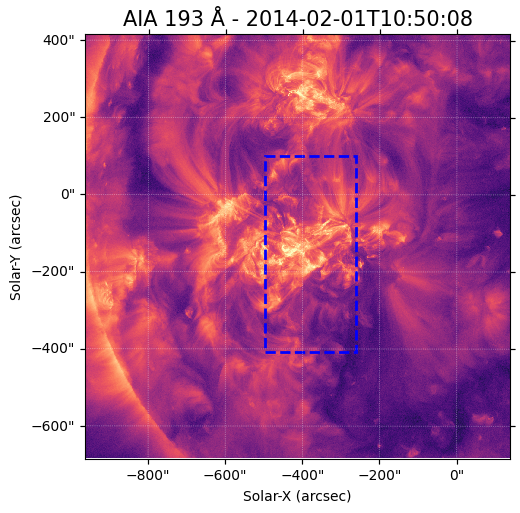

Plotting closed field lines: 100%|████████████████████████████████████████████████████████████████████████████████| 586/586 [00:22<00:00, 25.89it/s]


EIS FOV Pixel Coordinates - Bottom-left: PixelPair(x=<Quantity 774.33660107 pix>, y=<Quantity 457.17881606 pix>), Top-right: PixelPair(x=<Quantity 1170.59428091 pix>, y=<Quantity 1307.27359013 pix>)


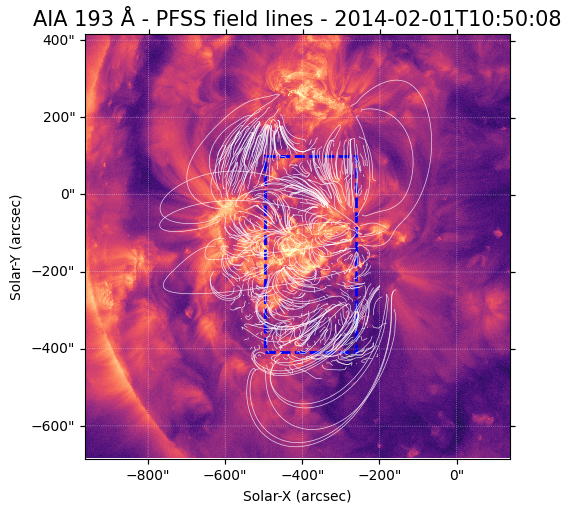

Saved as iris_map_2014_02_01__10_50_35_closed_open_overlayed_fieldlines.png


In [15]:
# AIA at the base, EIS FOV on top, with PFSS closed and opened fields
from sunpy.physics.differential_rotation import solar_rotate_coordinate

fig = plt.figure(figsize=(5,5))
print(f"Width Map Data - Min: {np.nanmin(width_map.data)}, Max: {np.nanmax(width_map.data)}")

graph_name = os.path.basename(open_pickle_filename).replace("_open_fieldlines.pickle", "").replace("_closed_fieldlines.pickle", "").replace("eis_", "") + "_closed_open_overlayed_fieldlines"

cropping = True

if cropping:
    original_time = "2014-01-29T20:00:08.22"
    original_center = SkyCoord(
        (-600 + -1050) / 2 * u.arcsec, 
        (0 - 350) / 2 * u.arcsec, 
        frame='helioprojective',
        obstime=original_time,
        observer='earth'
    )
    
    
    rotated_center = solar_rotate_coordinate(original_center, time=width_map.date)
    
    margin = 550 * u.arcsec
    new_bottom_left = SkyCoord(
        rotated_center.Tx - margin, rotated_center.Ty - margin, frame=width_map.coordinate_frame
    )
    new_top_right = SkyCoord(
        rotated_center.Tx + margin, rotated_center.Ty + margin, frame=width_map.coordinate_frame
    )
    
    cropped_map = width_map.submap(new_bottom_left, top_right=new_top_right)
    map_to_plot = cropped_map  # Use cropped version
else:
    map_to_plot = width_map  # Use the full map if cropping is disabled

from matplotlib.patches import Rectangle

# AIA only
fig = plt.figure(figsize=(5,5))
graph_name_simple = graph_name + "_AIA_only"

for i,m in enumerate([map_to_plot]):
    ax = fig.add_subplot(1,1,i+1,projection=m)
    map_to_plot.plot(axes=ax, vmin=0, vmax=2000, cmap='magma')
    bounds = ax.axis()
    ax.set_title(f'AIA 193 Å - 2014-02-01T10:50:08', fontsize=15)
    ax.set_xlabel('Solar-X (arcsec)', fontsize=10)
    ax.set_ylabel('Solar-Y (arcsec)', fontsize=10)
    ax.tick_params(axis='both', labelsize=10)

    # Plot EIS FOV rectangle
    bottom_left = eis_map.bottom_left_coord
    top_right = eis_map.top_right_coord


    bl_pixel = map_to_plot.world_to_pixel(bottom_left)
    tr_pixel = map_to_plot.world_to_pixel(top_right)
    print(f"EIS FOV Pixel Coordinates - Bottom-left: {bl_pixel}, Top-right: {tr_pixel}")

    rect = Rectangle((bl_pixel.x.value, bl_pixel.y.value), 
                     tr_pixel.x.value - bl_pixel.x.value, 
                     tr_pixel.y.value - bl_pixel.y.value, 
                     edgecolor='blue', facecolor='none', linestyle='--', linewidth=2)
    ax.add_patch(rect)
    ax.axis(bounds)

plt.tight_layout(pad=0)
plt.show()


##For Debugging Cropping
# print(f"Original center: {original_center}")
# print(f"Rotated center: {rotated_center}")
# print(f"New Bottom Left: {new_bottom_left}, New Top Right: {new_top_right}")
# print(f"Cropped Map Dimensions: {cropped_map.dimensions}")

fig = plt.figure(figsize=(5,5))

for i,m in enumerate([map_to_plot]):
    ax = fig.add_subplot(1,1,i+1,projection=m)
    map_to_plot.plot(axes=ax, vmin=0, vmax=2000, cmap='magma')
    # m.plot()
    bounds = ax.axis()
    ax.set_title(f'AIA 193 Å - PFSS field lines - 2014-02-01T10:50:08', fontsize=15)
    ax.set_xlabel('Solar-X (arcsec)', fontsize=10)
    ax.set_ylabel('Solar-Y (arcsec)', fontsize=10)
    ax.tick_params(axis='both', labelsize=10)
    # print(f"Fieldlines count: {len(fieldlines)}")
    # for c in tqdm(lines[::4]):
    #     ax.plot_coord(c, lw=3.3, color='white',alpha=.5)
    # for c in tqdm(long_lines[::2]):
    #     ax.plot_coord(c, lw=3.3, color='green',alpha=.8)

#Removed because not seperate open and closed lines
    # for c in tqdm(fieldlines[::10]):
    #     coords = c.coords
    #     if coords.shape[0] > 0:  # Only plot if there are coordinates

    #         # # Print first fieldline coordinate shape and frame
    #         # print(f"Fieldline first coord shape: {coords.shape}")
    #         # print(f"Fieldline first coord frame: {coords.frame.name}")

    #         # # Print X and Y coordinate range
    #         # print(f"Fieldline Longitude range: {np.nanmin(coords.lon)}, {np.nanmax(coords.lon)}")
    #         # print(f"Fieldline Latitude range: {np.nanmin(coords.lat)}, {np.nanmax(coords.lat)}")

    #         # # Ensure correct observer transformation
    #         # print(f"AIA Map Time: {m.date}")

    #         # Change the observer time of the coordinates to match the AIA map
    #         coords_updated = change_obstime(coords, m.date)
    #         ax.plot_coord(coords_updated, lw=0.5, color='white',alpha=.8)
    # # for c in tqdm(long_lines[0]):
    # #     ax.plot_coord(c, lw=5, color='black',alpha=.8)
    
    # Plot closed field lines in white
    if closed_fieldlines:
        for c in tqdm(closed_fieldlines[::20], desc="Plotting closed field lines"):
            coords = c.coords
            if coords.shape[0] > 0:
                coords_updated = change_obstime(coords, m.date)
                ax.plot_coord(coords_updated, lw=0.5, color='white', alpha=0.8)

    # Plot open field lines in blue
    if open_fieldlines:
        for c in tqdm(open_fieldlines[::2], desc="Plotting open field lines"):
            coords = c.coords
            if coords.shape[0] > 0:
                coords_updated = change_obstime(coords, m.date)
                ax.plot_coord(coords_updated, lw=0.5, color='blue', alpha=0.8)

    #rectangle
    bottom_left = eis_map.bottom_left_coord
    top_right = eis_map.top_right_coord
    # Convert world coordinates to pixel coordinates in AIA map
    bl_pixel = map_to_plot.world_to_pixel(bottom_left)
    tr_pixel = map_to_plot.world_to_pixel(top_right)

    print(f"EIS FOV Pixel Coordinates - Bottom-left: {bl_pixel}, Top-right: {tr_pixel}")

    # Draw rectangle on AIA map
    rect = Rectangle((bl_pixel.x.value, bl_pixel.y.value), 
                     tr_pixel.x.value - bl_pixel.x.value, 
                     tr_pixel.y.value - bl_pixel.y.value, 
                     edgecolor='blue', facecolor='none', linestyle='--', linewidth=2)
    
    ax.add_patch(rect)
    ax.axis(bounds)


# fig.savefig('Daves_IRIS_paper_PFSS.pdf',dpi=150)
plt.tight_layout(pad=0)
# plt.savefig(f'iris_map_{graph_name}.png', dpi=150)
plt.show()

print(f'Saved as iris_map_{graph_name}.png')

In [ ]:
# Check .npz for amount of lines, spatial map, bar chart, checking if labled

def check_spectral_lines(date_time):
    output_dir = f"{iris_dir}/results"
    converted_date_time = f"2014{date_time}"
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    print(f"Checking directory: {results_dir}")
    
    # Locate all .npz composition files
    npz_files = [f for f in os.listdir(results_dir) if f.endswith(".npz")]
    
    line_counts = {}
    labels_exist = {}
    spatial_data = {}
    print(f"Found .npz files: {npz_files}")
    for npz_filename in npz_files:
        npz_path = os.path.join(results_dir, npz_filename)
        data = np.load(npz_path)

        print(f"Processing: {npz_filename}, keys: {list(data.files)}")
        for key in data.files:
            print(f"\n=== FULL CONTENT OF {npz_filename} - Key: {key} ===")
            print(data[key])

        for key in data.files:
            print(f"DEBUG: {npz_filename} - Key: {key}, Shape: {data[key].shape}, Unique Values: {np.unique(data[key])}")


        
        # Count the number of lines by checking array sizes
        num_lines = len(data.files)  # Number of stored arrays
        line_counts[npz_filename] = num_lines

        # Check if any saved labels exist
        identity_keys = {}

        for key in data.files:
            if any(term in key.lower() for term in ["label", "identity", "feature", "type"]):
                if npz_filename not in identity_keys:
                    identity_keys[npz_filename] = []
                identity_keys[npz_filename].append(key)

        print(f"Available keys in {npz_filename}: {list(data.files)}")
        
        # Extract spatial map data (assuming a 2D array exists)
        spectral_keys = ["no_lines", "lines_used"]  # Keys likely to contain spectral line counts
        selected_key = None
        
        for key in spectral_keys:
            if key in data.files:
                selected_key = key
                break  # Stop at the first matching key
        
        if selected_key:
            spatial_data[npz_filename] = data[selected_key]
            print(f"DEBUG: Selected {selected_key} for {npz_filename}")
            print(f"DEBUG: {npz_filename} - Min: {np.nanmin(spatial_data[npz_filename])}, Max: {np.nanmax(spatial_data[npz_filename])}")
        else:
            print(f"Warning: No valid spectral line count map found in {npz_filename}")

    # Save results to a text file
    output_file = os.path.join(output_dir, "checked_npz.txt")
    with open(output_file, "a") as f:
        f.write(f"Checking directory: {results_dir}\n")
        f.write(f"Found .npz files: {npz_files}\n\n")
        f.write("Final Summary:\n")
        for filename, count in line_counts.items():
            label_status = "Yes" if filename in identity_keys else "No"
            f.write(f"{filename}: {count} lines, Labels saved: {label_status}\n")
        f.write("\n")
    
    print(f"Results saved to {output_file}")

    # Plot bar chart
    fig, ax = plt.subplots(figsize=(6, 6))
    file_names = list(line_counts.keys())
    line_values = list(line_counts.values())

    ax.barh(file_names, line_values, color="blue")
    ax.set_xlabel("Number of Spectral Lines")
    ax.set_ylabel("Composition Maps (.npz)")
    ax.set_title(f"Spectral Line Counts for {date_time}")

    bar_chart_path = os.path.join(output_dir, f"spectral_line_counts_{date_time}.png")
    plt.savefig(bar_chart_path, dpi=150)
    plt.close()  # Close the figure to free memory
    print(f"Bar chart saved to {bar_chart_path}")



    # Plot spatial maps (if available)
    for filename, data_array in spatial_data.items():
        print(f"DEBUG ARRAY ({filename}): Shape={data_array.shape}, Unique Values={np.unique(data_array)}")
        print(f"DEBUG: {filename} - Min: {np.min(data_array)}, Max: {np.max(data_array)}")
        fig, ax = plt.subplots(figsize=(6, 6))
        im = ax.imshow(data_array, origin='lower', cmap='viridis')

        ax.set_title(f"Spectral Line Spatial Density - {filename}")
        ax.set_xlabel("X Pixels")
        ax.set_ylabel("Y Pixels")
        plt.colorbar(im, ax=ax, label="Number of Spectral Lines")

        spatial_map_path = os.path.join(output_dir, f"spatial_map_{filename}.png")
        plt.savefig(spatial_map_path, dpi=150)
        plt.close()  # Close the figure to free memory
        print(f"Spatial map saved to {spatial_map_path}")
        # Print all found spectral line identity keys at the very end
        print("\n=== Spectral Line Identity Check ===")
        if identity_keys:
            print("Potential spectral line identity keys found in:")
            for filename, key in identity_keys.items():
                print(f"{filename}: {key}")
        else:
            print("No spectral line identity keys found.")

# Example Usage
check_spectral_lines("0202_141952")


In [ ]:
# (doesn't work) Generates a footpoint map color-coded by field length and overlays it on an AIA 193 Å image.

import matplotlib.patches as mpatches
from astropy.visualization import ImageNormalize
from skimage.filters import gaussian, unsharp_mask
from sunpy.coordinates.frames import HeliographicStonyhurst
from sunpy.coordinates.frames import Helioprojective



# Define function to extract footpoints
def extract_footpoints(fieldlines):
    footpoints = []
    for line in fieldlines:
        if line.coords.shape[0] > 0:  # Ensure valid points exist
            footpoints.append(line.coords[0])  # Use first coordinate as footpoint
    return footpoints

# def change_obstime(coord, new_obstime):
#     if 'observer' in coord.frame.frame_attributes:
#         new_frame = coord.frame.replicate(obstime=new_obstime, observer=coord.observer.replicate(obstime=new_obstime))
#     else:
#         new_frame = coord.frame.replicate(obstime=new_obstime)
#     return coord.transform_to(new_frame)

# def change_obstime(coord, new_obstime, new_observer):
#     return coord.transform_to(coord.frame.replicate(obstime=new_obstime, observer=new_observer))

# def change_obstime(coord, new_obstime, new_observer):
#     print(f"Changing obstime to {new_obstime}, observer: {new_observer}")    
#     if 'observer' in coord.frame.frame_attributes:
#         new_frame = coord.frame.replicate(obstime=new_obstime, observer=new_observer)
#     else:
#         new_frame = coord.frame.replicate(obstime=new_obstime)  # No observer for Stonyhurst
#     return coord.transform_to(new_frame)

# def change_obstime(coord, new_obstime, aia_observer):
#     print(f"Changing obstime to {new_obstime}, observer: {aia_observer}")  
#     new_frame = HeliographicStonyhurst(obstime=new_obstime, observer=aia_observer)
#     return coord.transform_to(new_frame)

def change_obstime(coord, new_obstime):
    print(f"Changing obstime to {new_obstime}")  
    new_frame = coord.frame.replicate(obstime=new_obstime)  # No observer update
    return coord.transform_to(new_frame)

    
# Function to plot the footpoint map with AIA 193 Å
def plot_footpoint_map(date_time):

    # Load PFSS field line data
    iris_dir = "/home/ug/orlovsd2/gazelle/pfss"
    open_pickle_filename = f"{iris_dir}/eis_{date_time}_open_fieldlines.pickle"
    closed_pickle_filename = f"{iris_dir}/eis_{date_time}_closed_fieldlines.pickle"
    aia_193_fits_path = f"{iris_dir}/AIA/aia.lev1.193A_2014_02_01T10_50_08.93Z.image_lev1.fits"

    with open(open_pickle_filename, "rb") as f:
        open_fieldlines = pickle.load(f)
    with open(closed_pickle_filename, "rb") as f:
        closed_fieldlines = pickle.load(f)

    aia_map = sunpy.map.Map(aia_193_fits_path)
    # Debugging: Ensure rsun_meters is in meters and not squared
    print(f"AIA rsun_meters: {aia_map.rsun_meters}, Unit: {aia_map.rsun_meters.unit}")

    
    # Ensure rsun_meters is in meters
    if aia_map.rsun_meters.unit != u.m:
        aia_map.rsun_meters = aia_map.rsun_meters.to(u.m)
    aia_map_enhanced = aia_map
    
    # Extract footpoints
    short_footpoints = [c.coords[0] for c in closed_fieldlines if 0 < c.coords.shape[0] < 1800]
    medium_footpoints = [c.coords[0] for c in closed_fieldlines if 1800 <= c.coords.shape[0] < 9000]
    long_footpoints = [c.coords[0] for c in closed_fieldlines if c.coords.shape[0] >= 9000]
    open_footpoints = [c.coords[0] for c in open_fieldlines if c.coords.shape[0] > 0]

    # # Gaussian filtering to highlight enhanced S regions
    # smoothed_data = gaussian(aia_map.data, sigma=5)
    
    print(f"Extracted footpoints - Short: {len(short_footpoints)}, Medium: {len(medium_footpoints)}, Long: {len(long_footpoints)}, Open: {len(open_footpoints)}")

    
    # Overlay footpoints with gradient color coding
    if short_footpoints:
        print(f"First few short footpoints (pre-transform): {short_footpoints[:5]}")
        print(f"AIA Map Frame: {aia_map.coordinate_frame}")
        print(f"AIA Map Observer: {aia_map.observer_coordinate}")
        print(f"Closed Fieldlines Frame: {closed_fieldlines[0].coords.frame}")

        
        # # # short_footpoints = SkyCoord(
        # # #     [c.lon for c in short_footpoints], 
        # # #     [c.lat for c in short_footpoints], 
        # # #     [c.radius for c in short_footpoints],  
        # # #     frame=closed_fieldlines[0].coords.frame.replicate(
        # # #         obstime=aia_map.date, 
        # # #         observer=aia_map.observer_coordinate  # Force AIA observer
        # # #     )
        # # # )

        # # short_footpoints = SkyCoord(
        # #     [c.lon for c in short_footpoints], 
        # #     [c.lat for c in short_footpoints], 
        # #     [c.radius for c in short_footpoints],  
        # #     frame=closed_fieldlines[0].coords.frame  # Keep original PFSS frame
        # # )
        # # short_footpoints = change_obstime(short_footpoints, aia_map.date)


        # # # Normalize radius to match AIA
        # # short_footpoints = SkyCoord(
        # #     short_footpoints.lon, 
        # #     short_footpoints.lat, 
        # #     aia_map.rsun_meters,  # Replace radius with AIA's radius
        # #     frame=short_footpoints.frame
        # # )
  
        
        # # # Convert to Helioprojective
        # # short_footpoints = short_footpoints.transform_to(aia_map.coordinate_frame)

        # # # Convert list to SkyCoord object
        # # short_footpoints = SkyCoord(short_footpoints)
        # # print(f"Initial frame: {short_footpoints.frame}")


        # # # Convert Carrington → Stonyhurst (aligning with AIA)
        # # short_footpoints = short_footpoints.transform_to("heliographic_stonyhurst")
        # # print(f"After Stonyhurst conversion (.frame) {short_footpoints.frame}")
        # # print(f"After Stonyhurst conversion: {short_footpoints}")


        # # # Ensure observer time matches AIA map
        # # print(f"Before change_obstime: {short_footpoints.frame}, Observer: {short_footpoints.observer if hasattr(short_footpoints, 'observer') else 'N/A'}")
        # # short_footpoints = change_obstime(short_footpoints, aia_map.date)
        # # # short_footpoints = change_obstime(short_footpoints, aia_map.date, aia_map.observer_coordinate)
        # # print(f"After change_obstime: {short_footpoints.frame}, Observer: {short_footpoints.observer if hasattr(short_footpoints, 'observer') else 'N/A'}")
        # # print(f"After change_obstime: {short_footpoints}")
        
        # # # Convert Stonyhurst → Helioprojective (AIA frame)
        # # short_footpoints = short_footpoints.transform_to(aia_map.coordinate_frame)
        # # print(f"After Helioprojective conversion: {short_footpoints.frame}")
        # # print(f"After Helioprojective conversion: {short_footpoints}")
        # # Convert list to SkyCoord object
        # short_footpoints = SkyCoord(short_footpoints)
        # print(f"Radius before transformation: {short_footpoints.radius}")
        # print(f"Radius unit: {short_footpoints.radius.unit}")

        # # Step 1: Transform from Heliographic Carrington → Heliographic Stonyhurst
        # short_footpoints = short_footpoints.transform_to("heliographic_stonyhurst")
        # print(f"Step 1 - After Carrington → Stonyhurst: {short_footpoints[:5]}")
        
        # # Step 2: Update obstime and observer
        # short_footpoints = short_footpoints.transform_to(
        #     HeliographicStonyhurst(obstime=aia_map.date)
        # )

        # print(f"Step 2 - After Updating Time & Observer: {short_footpoints[:5]}")
        # print(f"Before fixing radius: {short_footpoints.radius}")

        # # Step 3: Normalize the radius to match AIA (important for correct projection)
        # print(f"Step 3 - Before Radius Normalization: {short_footpoints.radius}, Unit: {short_footpoints.radius.unit}")
        
        # # Ensure rsun_meters is in meters before applying
        # rsun_corrected = aia_map.rsun_meters.to(u.m)
        
        # # Apply the normalized solar radius
        # short_footpoints = SkyCoord(
        #     short_footpoints.lon, 
        #     short_footpoints.lat, 
        #     rsun_corrected,  # Explicitly convert and use AIA's solar radius
        #     frame=short_footpoints.frame
        # )
        
        # print(f"Step 3 - After Radius Normalization: {short_footpoints.radius}, Unit: {short_footpoints.radius.unit}")


        # print(f"AIA rsun_meters unit: {aia_map.rsun_meters.unit}")

        # print(f"Step 3 - After Radius Normalization: {short_footpoints[:5]}")

        # print(f"Before transformation - Radius: {short_footpoints.radius}, Unit: {short_footpoints.radius.unit}")

        # # Step 4: Convert to Helioprojective (AIA frame)
        # # Ensure rsun_corrected is in meters
        # rsun_corrected = aia_map.rsun_meters.to(u.m)
        
        # print(f"Before Helioprojective transformation: {short_footpoints}")
        # print(f"Radius before transformation: {short_footpoints.radius}, Unit: {short_footpoints.radius.unit}")
        
        # # Convert to Helioprojective (AIA frame)
        # short_footpoints = short_footpoints.transform_to(
        #     Helioprojective(
        #         obstime=aia_map.date,
        #         observer=aia_map.observer_coordinate,
        #         rsun=rsun_corrected  # Ensure correct unit
        #     )
        # )
        
        # print(f"After Helioprojective transformation: {short_footpoints}")


        # print(f"Step 4 - Final Helioprojective Footpoints: {short_footpoints[:5]}")
        # print(f"Step 4 - Min/Max Tx: {np.min(short_footpoints.Tx.to_value('arcsec'))}, {np.max(short_footpoints.Tx.to_value('arcsec'))}")
        # print(f"Step 4 - Min/Max Ty: {np.min(short_footpoints.Ty.to_value('arcsec'))}, {np.max(short_footpoints.Ty.to_value('arcsec'))}")
        # print(f"AIA Sun Center: {aia_map.center}")

        # # Extract Tx and Ty for plotting
        # tx = short_footpoints.Tx.to_value('arcsec')
        # ty = short_footpoints.Ty.to_value('arcsec')

        # print(f"First few short footpoints (post-transform): {short_footpoints[:5]}")
        # print(f"Extracted Tx: {tx[:5]}, Ty: {ty[:5]}")      
        # # Check if there are unintended squares
        # print(f"rsun before transformation: {rsun_corrected}")
        # print(f"AIA rsun_meters: {aia_map.rsun_meters}")
        # print(f"AIA rsun_meters unit: {aia_map.rsun_meters.unit}")
    
        # Convert list to SkyCoord object
        short_footpoints = SkyCoord(short_footpoints)
        
        # Debugging: Print radius before transformation
        print(f"Radius before transformation: {short_footpoints.radius}")
        print(f"Radius unit: {short_footpoints.radius.unit}")
        
        # Step 1: Transform from Heliographic Carrington → Heliographic Stonyhurst with correct observer
        short_footpoints = short_footpoints.transform_to(
            HeliographicStonyhurst(obstime=aia_map.date)
        )

        

        # Debugging: Print footpoints after first transformation
        print(f"Step 1 - After Carrington → Stonyhurst: {short_footpoints[:5]}")
        
        # Ensure longitude stays within -180° to 180°
        short_footpoints = SkyCoord(
            short_footpoints.lon.wrap_at(180 * u.deg),  # Ensure longitude is within range
            short_footpoints.lat,
            short_footpoints.radius,
            frame=short_footpoints.frame
        )
        
        # Debugging: Print longitude after wrapping
        print(f"Step 1.5 - After Longitude Wraparound: {short_footpoints[:5]}")
        
        # Step 2: Normalize the radius to match AIA's solar radius
        rsun_corrected = aia_map.rsun_meters.to(u.m)
        
        short_footpoints = SkyCoord(
            short_footpoints.lon,
            short_footpoints.lat,
            rsun_corrected,  # Force exact match to AIA radius
            frame=short_footpoints.frame
        )

        #STEP 2
        rsun_corrected = aia_map.rsun_meters.to(u.m)
        
        short_footpoints = SkyCoord(
            short_footpoints.lon,
            short_footpoints.lat,
            rsun_corrected,  # Force exact match to AIA radius
            frame=short_footpoints.frame
        )
        
        # Debugging: Print radius after normalization
        print(f"Step 2 - After Radius Normalization: {short_footpoints.radius}, Unit: {short_footpoints.radius.unit}")
        
        print(f"AIA rsun_meters unit: {aia_map.rsun_meters.unit}")
        print(f"Step 2 - After Radius Normalization: {short_footpoints[:5]}")
        
        # Debugging: Print before final transformation
        print(f"Before transformation - Radius: {short_footpoints.radius}, Unit: {short_footpoints.radius.unit}")
        
        # Step 3: Convert to Helioprojective (AIA frame)
        print(f"Before Helioprojective transformation: {short_footpoints}")
        print(f"Radius before transformation: {short_footpoints.radius}, Unit: {short_footpoints.radius.unit}")
        
        aia_observer = HeliographicStonyhurst(
            lon=aia_map.observer_coordinate.lon,
            lat=aia_map.observer_coordinate.lat,
            radius=aia_map.observer_coordinate.radius,
            obstime=aia_map.date
        )
        
        short_footpoints = short_footpoints.transform_to(
            Helioprojective(
                obstime=aia_map.date,
                observer=aia_observer,
                rsun=rsun_corrected  # Ensure correct unit
            )
        )

        
        # Debugging: Print after Helioprojective transformation
        print(f"After Helioprojective transformation: {short_footpoints}")
        print(f"Step 3 - Final Helioprojective Footpoints: {short_footpoints[:5]}")
        
        # Extract Tx and Ty for plotting
        tx = short_footpoints.Tx.to_value('arcsec')
        ty = short_footpoints.Ty.to_value('arcsec')
        
        # Debugging: Check transformed coordinates
        print(f"Step 3 - Min/Max Tx: {np.min(tx)}, {np.max(tx)}")
        print(f"Step 3 - Min/Max Ty: {np.min(ty)}, {np.max(ty)}")
        print(f"AIA Sun Center: {aia_map.center}")
        
        print(f"First few short footpoints (post-transform): {short_footpoints[:5]}")
        print(f"Extracted Tx: {tx[:5]}, Ty: {ty[:5]}")      
        
        # Final checks on rsun
        print(f"rsun before transformation: {rsun_corrected}")
        print(f"AIA rsun_meters: {aia_map.rsun_meters}")
        print(f"AIA rsun_meters unit: {aia_map.rsun_meters.unit}")



    # if medium_footpoints:
    #     medium_footpoints = SkyCoord(medium_footpoints).transform_to(aia_map.coordinate_frame)
    #     ax.scatter(
    #         medium_footpoints.Tx.value,
    #         medium_footpoints.Ty.value,
    #         color="red",
    #         s=5,
    #         label="Medium Field Lines",
    #         alpha=0.7
    #     )

    # if long_footpoints:
    #     long_footpoints = SkyCoord(long_footpoints).transform_to(aia_map.coordinate_frame)
    #     ax.scatter(
    #         long_footpoints.Tx.value,
    #         long_footpoints.Ty.value,
    #         color="yellow",
    #         s=5,
    #         label="Long Field Lines",
    #         alpha=0.7
    #     )

    # if open_footpoints:
    #     open_footpoints = SkyCoord(open_footpoints).transform_to(aia_map.coordinate_frame)
    #     ax.scatter(
    #         open_footpoints.Tx.value,
    #         open_footpoints.Ty.value,
    #         color="green",
    #         s=5,
    #         label="Open Field Lines",
    #         alpha=0.7
    #     )

    # # Create plot
    # fig = plt.figure(figsize=(6, 6))
    # ax = fig.add_subplot(1, 1, 1, projection=aia_map_enhanced)
    # aia_map_enhanced.plot(axes=ax, vmin=0, vmax=1000, cmap="Blues")

    # if short_footpoints:
    #     ax.scatter(
    #         short_footpoints.Tx.to_value('arcsec'),
    #         short_footpoints.Ty.to_value('arcsec'),  
    #         color="black",
    #         s=5,
    #         label="Short Field Lines",
    #         alpha=0.7
    #     )

    print(f"Tx min/max: {np.min(tx)}, {np.max(tx)}")
    print(f"Ty min/max: {np.min(ty)}, {np.max(ty)}")
    print(f"Final Tx min/max: {np.min(short_footpoints.Tx.to_value('arcsec'))}, {np.max(short_footpoints.Tx.to_value('arcsec'))}")
    print(f"Final Ty min/max: {np.min(short_footpoints.Ty.to_value('arcsec'))}, {np.max(short_footpoints.Ty.to_value('arcsec'))}")


    print(f"AIA Image Min: {np.nanmin(aia_map_enhanced.data)}, Max: {np.nanmax(aia_map_enhanced.data)}")
    ax.set_title(f"PFSS Footpoint Map ({date_time}) - AIA 193 Å Overlay")
    ax.legend(loc="upper right", fontsize=8)
    plt.savefig(f"{iris_dir}/footpoint_map_{date_time}.png", dpi=150)
    plt.show()
    print(f"AIA observer: {aia_map.observer_coordinate}")
    print(f"Footpoints observer: {short_footpoints.observer if hasattr(short_footpoints, 'observer') else 'N/A'}")
    print(f"Final Frame: {short_footpoints.frame}")



plot_footpoint_map("2014_02_01__10_50_35")




In [ ]:
# (not usefull) Check if fieldlines or footpoints are at (-200,-50) and investigate PFSS field strength



# Load field line data
iris_dir = "/home/ug/orlovsd2/gazelle/pfss"
date_time = "2014_02_03__09_31_34"
closed_pickle_filename = f"{iris_dir}/eis_{date_time}_closed_fieldlines.pickle"
open_pickle_filename = f"{iris_dir}/eis_{date_time}_open_fieldlines.pickle"
eis_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"

with open(closed_pickle_filename, "rb") as f:
    closed_fieldlines = pickle.load(f)

with open(open_pickle_filename, "rb") as f:
    open_fieldlines = pickle.load(f)

# Load EIS map for coordinate conversion
eis_map = sunpy.map.Map(eis_fits_path)

# Convert footpoints to pixel coordinates
footpoints = [
    change_obstime(c.coords[0], eis_map.date)
    for c in list(closed_fieldlines) + list(open_fieldlines)
    if c.coords.shape[0] > 0  
]

print("Closed field lines count:", len(closed_fieldlines))
print("Open field lines count:", len(open_fieldlines))

# if footpoints:
#     coords = SkyCoord(footpoints)
#     px, py = eis_map.wcs.world_to_pixel(coords)
#     px, py = np.round(px).astype(int), np.round(py).astype(int)

#     # Check if any footpoints are near (-200, -50)
#     target_x, target_y = -200, -50
#     tolerance = 10  # Adjust if needed

#     found_footpoints = np.any(
#         (px > target_x - tolerance) & (px < target_x + tolerance) &
#         (py > target_y - tolerance) & (py < target_y + tolerance)
#     )

#     if found_footpoints:
#         print(f"Footpoints detected near ({target_x}, {target_y})")
#     else:
#         print(f"No footpoints found near ({target_x}, {target_y})")

# # **Check if full field lines pass through (-200, -50)**
# found_fieldlines = [
#     c for c in list(closed_fieldlines) + list(open_fieldlines)
#     if np.any(
#         (c.coords.helioprojective.Tx.value > target_x - tolerance) & 
#         (c.coords.helioprojective.Tx.value < target_x + tolerance) &
#         (c.coords.helioprojective.Ty.value > target_y - tolerance) & 
#         (c.coords.helioprojective.Ty.value < target_y + tolerance)
#     )
# ]

# print(f"Field lines passing near (-200, -50): {len(found_fieldlines)}")

# **Check if PFSS 7 Gauss threshold caused missing field lines**
# Investigate whether the strict 7 Gauss filtering caused missing field lines


## Load HMI synoptic map
m_hmi = hmi_daily_download(eis_map.date.value)

# Ensure target coordinates are defined
target_x, target_y = -200, -50  

# Resample the HMI data to match the working resolution
dimension = (1080, 540)  # Same as used in get_pfss_from_map
m_hmi_resample = m_hmi.resample(dimension * u.pix)

# Convert EIS coordinates to HeliographicStonyhurst (Sun-centered frame)
coords_hgs = SkyCoord(target_x * u.arcsec, target_y * u.arcsec, frame=eis_map.coordinate_frame).transform_to('heliographic_stonyhurst')

# Now transform to HMI's Carrington frame
coords_hmi = coords_hgs.transform_to(m_hmi_resample.coordinate_frame)

print("Helioprojective -> HeliographicStonyhurst:", coords_hgs)
print("HeliographicStonyhurst -> HeliographicCarrington (HMI Frame):", coords_hmi)

# Convert to pixel indices
px_hmi, py_hmi = m_hmi_resample.wcs.world_to_pixel(coords_hmi)
px_hmi, py_hmi = np.round(px_hmi).astype(int), np.round(py_hmi).astype(int)

# Extract the magnetic field value if within bounds
if 0 <= px_hmi < m_hmi_resample.data.shape[1] and 0 <= py_hmi < m_hmi_resample.data.shape[0]:
    B_r_value = m_hmi_resample.data[py_hmi, px_hmi]
    print(f"Magnetic field strength at (-200,-50) from HMI: {B_r_value:.2f} Gauss")

# Apply the same filtering as get_pfss_from_map()
min_gauss, max_gauss = 7, 7  # Adjustable to match get_pfss_from_map logic
masked_pix_y, masked_pix_x = np.where((m_hmi_resample.data >= max_gauss) | (m_hmi_resample.data < min_gauss))

# Print debug info
print(f"HMI Data Type: {type(m_hmi)}")
print(f"HMI Min/Max: {np.min(m_hmi.data)}, {np.max(m_hmi.data)}")

# Local region check
x_min, x_max = max(0, px_hmi - 5), min(m_hmi_resample.data.shape[1], px_hmi + 5)
y_min, y_max = max(0, py_hmi - 5), min(m_hmi_resample.data.shape[0], py_hmi + 5)
print(f"Local Min: {np.min(m_hmi_resample.data[y_min:y_max, x_min:x_max])}")

# Check how many valid points remain after filtering
filtered_values = m_hmi_resample.data[masked_pix_y, masked_pix_x]
print("Filtered Values (Kept for PFSS tracing):", filtered_values[:10])  # Print first 10 for verification

print("EIS Coordinate Frame:", eis_map.coordinate_frame)
print("HMI Coordinate Frame:", m_hmi_resample.coordinate_frame)




In [ ]:
#Defines functions used for getting footpoints




def bresenham(x1, y1, x2, y2):
    """
    Returns an array of all pixel coordinates which the line defined by `x1, y1` and
    `x2, y2` crosses. Uses Bresenham's line algorithm.

    Parameters
    ----------
    x1, y1, x2, y2 : int
        Pixel coordinates of the line endpoints.

    Returns
    -------
    np.array
        Array of pixel coordinates.
    """
    for x in [x1, y1, x2, y2]:
        if type(x) not in (int, np.int64):  
            raise TypeError("All pixel coordinates must be of type int")

    dx, dy = abs(x2 - x1), abs(y2 - y1) # determines the distance.
    sx, sy = (1 if x1 < x2 else -1), (1 if y1 < y2 else -1) # determines direction.
    err = dx - dy # inital error term used to decide if we step in x or y.
    res = []
    x, y = x1, y1

    while True:
        res.append((x, y)) # adds to res.
        if x == x2 and y == y2: 
            break # checks wther the intial x and y have reached the end point.
        e2 = 2 * err # gives you room to compare against both dx and dy to choose the best next pixel.
        if e2 > -dy:
            err -= dy
            x += sx # sx is either 1 or -1 depending on if x2 > x1, so if there istoo much y offset we go right to compensate.
        if e2 < dx:
            err += dx
            y += sy
            
    return np.array(res)


def get_intersecting_pixels(coord, image_wcs):
    """
    Finds pixels between each loop segment.

    Parameters
    ----------
    coord : SkyCoord
        The coordinates of the field line.
    image_wcs : WCS
        The WCS object of the AIA map.

    Returns
    -------
    np.array
        Array of pixel coordinates the field line intersects.
    """
    if len(coord) == 0:  # Check for empty input
        return np.array([])

    px, py = image_wcs.world_to_pixel(coord) # converts Skycoord to pixel coords.
    px, py = np.round(px).astype(int), np.round(py).astype(int) # converts floats to whole pixels, for Numpy.

    loop_pix = []
    
    for i in range(len(px) - 1): # Loops over each pair of consecutive points along the field line in pixel coords.
        b = bresenham(px[i], py[i], px[i + 1], py[i + 1]) # px[i], py[i] = start pixel of the segment, px[i+1], py[i+1] = end pixel of the segment.
        
        if b.size > 0:  # Ensure Bresenham output is not empty
            loop_pix.append(b[:-1] if i < len(px) - 2 else b) # For all segments except the last, avoids double counting.

    return np.vstack(loop_pix) if loop_pix else np.array([])  # Ensure non-empty output, vstack stacks all pixel coords arrays inot one single 2D array

In [ ]:
from datetime import datetime, timedelta

def find_closest_aia(date_time, aia_dir="/home/ug/orlovsd2/gazelle/pfss/AIA/"):
    # Convert EIS timestamp format to match AIA filenames (YYYY_MM_DDTHH_MM_)
    base_time_str = date_time[:10] + "T" + date_time[12:17] + "_"  # "YYYY_MM_DDTHH_MM_"
    # Get a sorted list of available AIA files
    aia_files = sorted(glob.glob(f"{aia_dir}/aia.lev1.193A_*.fits"))
    closest_file = None
    closest_time_diff = timedelta.max  # Start with the maximum possible difference
    for aia_file in aia_files:
        match = re.search(r"aia\.lev1\.193A_(\d{4}_\d{2}_\d{2}T\d{2}_\d{2}_\d{2})", aia_file)
        if match:
            filename_time_str = match.group(1)  # Extract timestamp from filename
            filename_time = datetime.strptime(filename_time_str, "%Y_%m_%dT%H_%M_%S")  # Convert to datetime
            # Convert input date_time to datetime object
            input_time = datetime.strptime(date_time, "%Y_%m_%d__%H_%M_%S")
            # Calculate time difference
            time_diff = abs(filename_time - input_time)
            # Check if it's the closest match (only consider files within a 2-minute window)
            if time_diff < timedelta(minutes=5) and time_diff < closest_time_diff:
                closest_file = aia_file
                closest_time_diff = time_diff
    if closest_file:
        print(f"Using closest AIA file: {closest_file}")
        return closest_file  # Return the file path instead of a SunPy map
    print(f"No local AIA file found within ±2 minutes for {date_time}")
    return None  # Return None if no suitable file is found

In [ ]:
# AIA at the base, EIS FOV on top, with footpoint map color-coded by field length via bresenham




def plot_footpoint_map(date_time, Crop = False, area = 450):

    iris_dir = "/home/ug/orlovsd2/gazelle/pfss"
    closed_pickle_filename = f"{iris_dir}/eis_{date_time}_closed_fieldlines.pickle"
    open_pickle_filename = f"{iris_dir}/eis_{date_time}_open_fieldlines.pickle"
    aia_193_fits_path = find_closest_aia(date_time)
    eis_map = sunpy.map.Map(f'{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits')


    with open(closed_pickle_filename, "rb") as f:
        closed_fieldlines = pickle.load(f)

    with open(open_pickle_filename, "rb") as f:
        open_fieldlines = pickle.load(f)

    aia_map = Map(aia_193_fits_path)
    
    # Cropping logic
    cropping = Crop  
    
    if cropping:
        original_time = "2014-01-29T20:00:08.22"
        original_center = SkyCoord(
            (-600 + -1050) / 2 * u.arcsec, 
            (0 - 350) / 2 * u.arcsec, 
            frame='helioprojective',
            obstime=original_time,
            observer='earth'
        )
        
        rotated_center = solar_rotate_coordinate(original_center, time=aia_map.date)
        
        margin = area * u.arcsec
        new_bottom_left = SkyCoord(
            rotated_center.Tx - margin, rotated_center.Ty - margin, frame=aia_map.coordinate_frame
        )
        new_top_right = SkyCoord(
            rotated_center.Tx + margin, rotated_center.Ty + margin, frame=aia_map.coordinate_frame
        )
        
        cropped_map = aia_map.submap(new_bottom_left, top_right=new_top_right)
        map_to_plot = cropped_map  # Use cropped version
    else:
        map_to_plot = aia_map  # Use full map if cropping is disabled

    fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': map_to_plot})
    map_to_plot.plot(axes=ax, title=f"test_footpoint_map_{date_time}_blurred", vmin=100, vmax=8000, cmap='magma')


    # **Classify footpoints based on field line length**
    short_footpoints = [change_obstime(c.coords[0], map_to_plot.date) for c in closed_fieldlines[::10] if 0 < c.coords.shape[0] < 1800]
    medium_footpoints = [change_obstime(c.coords[0], map_to_plot.date) for c in closed_fieldlines if 1800 <= c.coords.shape[0] < 9000]
    long_footpoints = [change_obstime(c.coords[0], map_to_plot.date) for c in closed_fieldlines if c.coords.shape[0] >= 9000]
    open_footpoints = [change_obstime(c.coords[0], map_to_plot.date) for c in open_fieldlines if c.coords.shape[0] > 0]



    # **Convert footpoints to pixel coordinates**
    # Combine all footpoints
    all_footpoints = short_footpoints + medium_footpoints + long_footpoints + open_footpoints
    if all_footpoints:
        # Priority classification per pixel
        grid = np.full(map_to_plot.data.shape, -1)
        priority_dict = {'open': 3, 'long': 2, 'medium': 1, 'short': 0}
    
        for footpoints, label in [(open_footpoints, 'open'), (long_footpoints, 'long'),
                                  (medium_footpoints, 'medium'), (short_footpoints, 'short')]:
            if footpoints:
                coords = SkyCoord(footpoints)
                px, py = map_to_plot.wcs.world_to_pixel(coords)
                px, py = np.round(px).astype(int), np.round(py).astype(int)
    
                for x, y in zip(px, py):
                    if 0 <= x < grid.shape[1] and 0 <= y < grid.shape[0]:
                        priority_to_label = {v: k for k, v in priority_dict.items()}
                        if grid[y, x] == -1 or priority_dict[label] > priority_dict[priority_to_label[int(grid[y, x])]]:
                            grid[y, x] = priority_dict[label]
    
        # Extract filtered pixel groups
        priority_to_label = {v: k for k, v in priority_dict.items()}
        filtered_footpoints = {'short': [], 'medium': [], 'long': [], 'open': []}
        for priority_value, label in priority_to_label.items():
            indices = np.argwhere(grid == priority_value)
            if indices.size > 0:
                filtered_footpoints[label] = indices[:, 1], indices[:, 0]
    
        # Build individual heatmaps
        heatmap_short = np.zeros(map_to_plot.data.shape)
        heatmap_medium = np.zeros(map_to_plot.data.shape)
        heatmap_long = np.zeros(map_to_plot.data.shape)
        heatmap_open = np.zeros(map_to_plot.data.shape)
    
        for x, y in zip(*filtered_footpoints['short']):
            if 0 <= x < heatmap_short.shape[1] and 0 <= y < heatmap_short.shape[0]:
                heatmap_short[y, x] += 1
        for x, y in zip(*filtered_footpoints['medium']):
            if 0 <= x < heatmap_medium.shape[1] and 0 <= y < heatmap_medium.shape[0]:
                heatmap_medium[y, x] += 1
        for x, y in zip(*filtered_footpoints['long']):
            if 0 <= x < heatmap_long.shape[1] and 0 <= y < heatmap_long.shape[0]:
                heatmap_long[y, x] += 1
        for x, y in zip(*filtered_footpoints['open']):
            if 0 <= x < heatmap_open.shape[1] and 0 <= y < heatmap_open.shape[0]:
                heatmap_open[y, x] += 1
    
        # Apply Gaussian blur (same sigma=10 as comp map)
        blurred_short = scipy.ndimage.gaussian_filter(heatmap_short, sigma=10)
        blurred_medium = scipy.ndimage.gaussian_filter(heatmap_medium, sigma=10)
        blurred_long = scipy.ndimage.gaussian_filter(heatmap_long, sigma=10)
        blurred_open = scipy.ndimage.gaussian_filter(heatmap_open, sigma=10)
    
        # Overlay each heatmap
        ax.imshow(blurred_short, alpha=0.2, extent=ax.get_xlim() + ax.get_ylim(), origin='lower')
        ax.imshow(blurred_medium, alpha=0.12, extent=ax.get_xlim() + ax.get_ylim(), origin='lower')
        ax.imshow(blurred_long, alpha=0.15, extent=ax.get_xlim() + ax.get_ylim(), origin='lower')
        ax.imshow(blurred_open, alpha=0.2, extent=ax.get_xlim() + ax.get_ylim(), origin='lower')


    # **Function to plot footpoints in a given color**
    def plot_footpoints(ax, footpoints, color, label):
        if footpoints:
            coords = SkyCoord(footpoints)
            px, py = map_to_plot.wcs.world_to_pixel(coords)
            px, py = np.round(px).astype(int), np.round(py).astype(int)
            ax.scatter(px, py, color=color, marker='o', s=30, label=label, alpha=0.5)

    # Draw rectangle to indicate EIS FOV
    bottom_left = eis_map.bottom_left_coord
    top_right = eis_map.top_right_coord
    
    # Convert world coordinates to pixel coordinates in cropped AIA map
    bl_pixel = map_to_plot.world_to_pixel(bottom_left)
    tr_pixel = map_to_plot.world_to_pixel(top_right)
    
    print(f"EIS FOV Pixel Coordinates - Bottom-left: {bl_pixel}, Top-right: {tr_pixel}")
    
    # Draw rectangle on AIA map
    rect = Rectangle((bl_pixel.x.value, bl_pixel.y.value), 
                     tr_pixel.x.value - bl_pixel.x.value, 
                     tr_pixel.y.value - bl_pixel.y.value, 
                     edgecolor='blue', facecolor='none', linestyle='--', linewidth=3)
    
    bounds = ax.axis()  # Store original bounds before adding rectangle
    ax.add_patch(rect)  # Add rectangle
    ax.axis(bounds)  # Restore original zoom

    print(f"Open Field Points: {len(open_footpoints)}")
    print(f"Long Closed Field Points: {len(long_footpoints)}")
    print(f"Medium Closed Field Points: {len(medium_footpoints)}")
    print(f"Short Closed Field Points: {len(short_footpoints)}")

    # **Plot each category with assigned colors**
    plot_footpoints(ax, open_footpoints, 'green', "Open Field Lines")
    plot_footpoints(ax, long_footpoints, '#E6BC52', "Long Closed Field Lines")
    plot_footpoints(ax, medium_footpoints, 'firebrick', "Medium Closed Field Lines")
    plot_footpoints(ax, short_footpoints, 'black', "Short Closed Field Lines")


    # **Create legend**
    legend_patches = [
        mpatches.Patch(color='#E6BC52', label="Long Closed Field Lines"),
        mpatches.Patch(color='firebrick', label="Medium Closed Field Lines"),
        mpatches.Patch(color='black', label="Short Closed Field Lines"),
        mpatches.Patch(color='green', label="Open Field Lines")
    ]

    ax.legend(handles=legend_patches)

    plt.savefig(f"{iris_dir}/footpoint_AIA_map_{date_time}_blurred.png", dpi=150)
    plt.show()



plot_footpoint_map("2014_02_02__12_29_34", True, 450)




In [ ]:
# Footpoint map using Bresenham's, overlays it on composition map, by field line length, color-coded, with Gaussian blur
from matplotlib.colors import Normalize


def plot_footpoint_map_on_composition(date_time, zoom):
    
    ycroppedmax = 502
    ycroppedmin = 104
    plt.clf()  # Clears the current figure
    plt.cla()  # Clears current axes
    plt.close()  # Closes the current figure window
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    print(converted_date_time)
    iris_dir=  '/home/ug/orlovsd2/gazelle/pfss'
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    closed_pickle_filename = f"{iris_dir}/adjusted_eis_{date_time}_closed_fieldlines.pickle"
    open_pickle_filename = f"{iris_dir}/adjusted_eis_{date_time}_open_fieldlines.pickle"
    eis_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"

    with open(closed_pickle_filename, "rb") as f:
        closed_fieldlines = pickle.load(f)

    with open(open_pickle_filename, "rb") as f:
        open_fieldlines = pickle.load(f)

    fe12_map = sunpy.map.Map(eis_fits_path)

    # expected_num_seeds = fe12_map.data.shape[0] * fe12_map.data.shape[1]
    # actual_num_closed = len(closed_fieldlines)
    # print(f"Expected number of fieldlines (1 per pixel): {expected_num_seeds}")
    # print(f"Actual number of closed fieldlines in pickle: {actual_num_closed}")
    
    header_fe12 = fe12_map.meta


    composition_files = [f for f in os.listdir(results_dir) if f.endswith(".fits") and "_composition_" not in f]


    for comp_filename in composition_files:
        comp_path = os.path.join(results_dir, comp_filename)
        element = comp_filename.split("_")[-1].replace(".fits", "")

        composition_data = sunpy.map.Map(comp_path).data # extracts only data.
        composition_map = sunpy.map.Map(composition_data, header_fe12) # assign fe12 header.

        print(f"Composition Map Coordinate Frame: {composition_map.coordinate_frame}")

        # Get image dimensions
        ymax, xmax = composition_map.data.shape
        xmin, ymin = 0, 0
        
        # Convert pixel corners to solar coordinates
        bottom_left = composition_map.pixel_to_world(xmin * u.pixel, ymin * u.pixel)
        top_right = composition_map.pixel_to_world(xmax * u.pixel, ymax * u.pixel)
        
        print("Map bounds in Solar-Y:")
        print(f"Bottom left Solar-Y: {bottom_left.Ty.to(u.arcsec).value:.2f}")
        print(f"Top right Solar-Y:   {top_right.Ty.to(u.arcsec).value:.2f}")
                
        # Count how many fieldlines have a start or end footpoint inside the EIS FOV
        in_eis = 0
        for line in closed_fieldlines:
            if line.coords.shape[0] == 0:
                continue
        
            foot_start = change_obstime(line.coords[0], composition_map.date)
            foot_end = change_obstime(line.coords[-1], composition_map.date)

        
            for foot in [foot_start, foot_end]:
                try:
                    px, py = composition_map.wcs.world_to_pixel(foot)  # Converts start and end pixel to coords
                    if 0 <= px < composition_map.data.shape[1] and 0 <= py < composition_map.data.shape[0]: # checks if each fieldline exists within the comp map bounds
                        in_eis += 1
                        break  # Count each line only once
                except Exception:
                    continue
        
        print(f"Start or end footpoints inside EIS FOV: {in_eis} / {len(closed_fieldlines)}")




        norm = ImageNormalize(vmin=1, vmax=1.5 if element == "sar" else 4)

        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': composition_map})
        composition_map.plot(axes=ax, norm=norm, cmap='viridis')

        # Pad view around EIS FOV by "zoom" arcsec in each direction
        xrange = ax.get_xlim()
        yrange = ax.get_ylim()
        
        ax.set_xlim(xrange[0] - zoom, xrange[1] + zoom)
        ax.set_ylim(yrange[0] - zoom, yrange[1] + zoom)
        # The padding applied is why we get green dots even though they fall outside the eis map, good for visuals but later ignored in scatter plots
        
        ax.set_title(f'{element} Composition Map - {date_time}', fontsize=15)

        short_footpoints = [
            pt
            for c in closed_fieldlines[::30] if 0 < c.coords.shape[0] < 1800
            for pt in [change_obstime(c.coords[0], composition_map.date), # .coords[0] extracts the start coord
                       change_obstime(c.coords[-1], composition_map.date)] # .coords[-1] extracts the end coord
        ]
        medium_footpoints = [
            pt
            for c in closed_fieldlines if 1800 <= c.coords.shape[0] < 9000
            for pt in [change_obstime(c.coords[0], composition_map.date),
                       change_obstime(c.coords[-1], composition_map.date)]
        ]
        long_footpoints = [
            pt
            for c in closed_fieldlines if c.coords.shape[0] >= 9000
            for pt in [change_obstime(c.coords[0], composition_map.date),
                       change_obstime(c.coords[-1], composition_map.date)]
        ]
        open_footpoints = [
            pt
            for c in open_fieldlines if c.coords.shape[0] > 0
            for pt in [change_obstime(c.coords[0], composition_map.date),
                       change_obstime(c.coords[-1], composition_map.date)]
        ]



        # Convert footpoints to pixel coordinates
        all_footpoints = short_footpoints + medium_footpoints + long_footpoints + open_footpoints # A flat list of every point we want to plot
        if all_footpoints:

            # for foot in all_footpoints:
            #     try:
            #         ax.plot_coord(foot, marker='x', color='red', markersize=3, alpha=0.3)
            #     except Exception as e:
            #         print(f"Failed to plot footpoint in WCS: {foot} — {e}")

            
            # Creates a 2D array same shape as composition map
            grid = np.full(composition_map.data.shape, -1)  # -1 means no footpoint
            priority_dict = {'open': 3, 'long': 2, 'medium': 1, 'short': 0}  # Priority levels
    
            # Loop through footpoint categories and assign the highest priority at each pixel
            for footpoints, label in [(open_footpoints, 'open'), (long_footpoints, 'long'), 
                                      (medium_footpoints, 'medium'), (short_footpoints, 'short')]:
                if footpoints:
                    coords = SkyCoord(footpoints)
                    px, py = composition_map.wcs.world_to_pixel(coords)
                    px, py = np.round(px).astype(int), np.round(py).astype(int)

                    # print(f"--- DEBUG: Pixel conversion info for {label} ---")
                    # print(f"Num coords: {len(coords)}")
                    # for i in range(min(3, len(px))):
                    #     hp_coord = coords[i].transform_to('helioprojective')
                    #     lon = hp_coord.spherical.lon.arcsec
                    #     lat = hp_coord.spherical.lat.arcsec
                    #     print(f"  Footpoint {i}: WCS = ({lon:.2f}, {lat:.2f}), Pixel = ({px[i]}, {py[i]})")

                    
                    # out_of_bounds = sum(
                    #     not (0 <= x < composition_map.data.shape[1] and 0 <= y < composition_map.data.shape[0])
                    #     for x, y in zip(px, py)
                    # )
                    # print(f"Out of bounds: {out_of_bounds} / {len(px)}")


                    for x, y in zip(px, py):
                        # if 0 <= x < grid.shape[1] and 0 <= y < grid.shape[0]:  # Ensure within bounds
                        #     # print(f"Footpoint out of bounds: (x={x}, y={y}), grid size = {grid.shape[::-1]}")
                        #     priority_to_label = {v: k for k, v in priority_dict.items()}  # Reverse lookup
                            
                        #     if grid[y, x] == -1 or priority_dict[label] > priority_dict[priority_to_label[int(grid[y, x])]]:

                        #         grid[y, x] = priority_dict[label]  # Store the integer priority

                        if 0 <= x < grid.shape[1] and 0 <= y < grid.shape[0]:
                            world = composition_map.pixel_to_world(x * u.pixel, y * u.pixel) # Converts the pixel location into a real-world solar coords
                            solar_y = world.Ty.to(u.arcsec).value # Gets the Solar-Y position in arcseconds for the footpoint.
                            if solar_y < ycroppedmin or solar_y > ycroppedmax: # Solar y cropping
                                continue  # Skip entirely if out of Solar-Y range
                        
                            priority_to_label = {v: k for k, v in priority_dict.items()} # Reverses dictionary so we can look up in reverse
                            if grid[y, x] == -1 or priority_dict[label] > priority_dict[priority_to_label[int(grid[y, x])]]:
                                grid[y, x] = priority_dict[label] # Checks the priority value and overwrites it, so if it's 1 (short), it will be over written by open

            
            priority_to_label = {v: k for k, v in priority_dict.items()}  # Reverses back so we can loop over numbers knowing what list they belong to.
            
            # Extract filtered footpoints to plot
            filtered_footpoints = {'short': [], 'medium': [], 'long': [], 'open': []}
    
            for priority_value, label in priority_to_label.items():  
                indices = np.argwhere(grid == priority_value)  # Checks integer value
                if indices.size > 0: # If it's above 0
                    filtered_footpoints[label] = indices[:, 1], indices[:, 0]  # (px, py) format

            
            coords = SkyCoord(all_footpoints)
            px, py = composition_map.wcs.world_to_pixel(coords)
            px, py = np.round(px).astype(int), np.round(py).astype(int)

            # Separate heatmaps for each footpoint type
            heatmap_short = np.zeros(composition_map.data.shape)
            heatmap_medium = np.zeros(composition_map.data.shape)
            heatmap_long = np.zeros(composition_map.data.shape)
            heatmap_open = np.zeros(composition_map.data.shape)
            
            # Populate heatmaps

            for x, y in zip(*filtered_footpoints['short']):
                if 0 <= x < heatmap_short.shape[1] and 0 <= y < heatmap_short.shape[0]:

                    #filtering based on solar y position
                    world = composition_map.pixel_to_world(x * u.pixel, y * u.pixel)
                    # print(f"x={x}, y={y} - Solar-Y = {world.Ty.to(u.arcsec).value:.2f}")
                    solar_y = world.Ty.to(u.arcsec).value
                    if solar_y < ycroppedmin or solar_y > ycroppedmax:
                        continue

                    heatmap_short[y, x] += 1



            for x, y in zip(*filtered_footpoints['medium']):
                if 0 <= x < heatmap_medium.shape[1] and 0 <= y < heatmap_medium.shape[0]:

                    #filtering based on solar y position
                    world = composition_map.pixel_to_world(x * u.pixel, y * u.pixel)
                    # print(f"x={x}, y={y} - Solar-Y = {world.Ty.to(u.arcsec).value:.2f}")
                    solar_y = world.Ty.to(u.arcsec).value
                    if solar_y < ycroppedmin or solar_y > ycroppedmax:
                        continue

                    heatmap_medium[y, x] += 1



            for x, y in zip(*filtered_footpoints['long']):
                if 0 <= x < heatmap_long.shape[1] and 0 <= y < heatmap_long.shape[0]:

                    #filtering based on solar y position
                    world = composition_map.pixel_to_world(x * u.pixel, y * u.pixel)
                    # print(f"x={x}, y={y} - Solar-Y = {world.Ty.to(u.arcsec).value:.2f}")
                    solar_y = world.Ty.to(u.arcsec).value
                    if solar_y < ycroppedmin or solar_y > ycroppedmax:
                        continue

                    heatmap_long[y, x] += 1

                

            for x, y in zip(*filtered_footpoints['open']):
                if 0 <= x < heatmap_open.shape[1] and 0 <= y < heatmap_open.shape[0]:

                    #filtering based on solar y position
                    world = composition_map.pixel_to_world(x * u.pixel, y * u.pixel)
                    # print(f"x={x}, y={y} - Solar-Y = {world.Ty.to(u.arcsec).value:.2f}")
                    solar_y = world.Ty.to(u.arcsec).value
                    if solar_y < ycroppedmin or solar_y > ycroppedmax:
                        continue
                    
                    heatmap_open[y, x] += 1


            blurred_short = scipy.ndimage.gaussian_filter(heatmap_short, sigma=10)
            blurred_medium = scipy.ndimage.gaussian_filter(heatmap_medium, sigma=10)
            blurred_long = scipy.ndimage.gaussian_filter(heatmap_long, sigma=10)
            blurred_open = scipy.ndimage.gaussian_filter(heatmap_open, sigma=10)
            
            # Overlay each heatmap with different colormaps
            ax.imshow(blurred_short, alpha=0.2, origin='lower')
            ax.imshow(blurred_medium, alpha=0.12, origin='lower')
            ax.imshow(blurred_long, alpha=0.15, origin='lower')
            ax.imshow(blurred_open, alpha=0.2, origin='lower')


        # Function to plot footpoints in a given color
        def plot_footpoints(ax, footpoints, color, label):
            if footpoints:
                coords = SkyCoord(footpoints)
                px, py = composition_map.wcs.world_to_pixel(coords)
                px, py = np.round(px).astype(int), np.round(py).astype(int)
                ax.scatter(px, py, color=color, marker='o', s=30, label=label, alpha=0.5)


        plot_footpoints(ax, open_footpoints, 'green', "Open Field Lines")
        plot_footpoints(ax, long_footpoints, '#E6BC52', "Long Closed Field Lines")
        plot_footpoints(ax, medium_footpoints, 'firebrick', "Medium Closed Field Lines")
        plot_footpoints(ax, short_footpoints, 'black', "Short Closed Field Lines")

        legend_patches = [
            mpatches.Patch(color='#E6BC52', label="Long Closed Field Lines"),
            mpatches.Patch(color='firebrick', label="Medium Closed Field Lines"),
            mpatches.Patch(color='black', label="Short Closed Field Lines"),
            mpatches.Patch(color='green', label="Open Field Lines")
        ]
        ax.legend(handles=legend_patches, loc='upper right', fontsize=12, frameon=True)

        # ax.axhline(ycroppedmin, color='white', linestyle='--', alpha=0.5)
        # ax.axhline(ycroppedmax, color='white', linestyle='--', alpha=0.5)


        # plt.savefig(f"{iris_dir}/corrected_footpoint_composition_map_{date_time}_{element}_blurred.png", dpi=150)
        plt.show()

        print(f"Short: {len(short_footpoints)}, Medium: {len(medium_footpoints)}, Long: {len(long_footpoints)}, Open: {len(open_footpoints)}")
        print(f"Saved as footpoint_composition_map_{date_time}_{element}_blurred.png")
        print(f"Composition map resolution: {composition_map.data.shape}")
        print(f"EIS map resolution: {fe12_map.data.shape}\n")




# plot_footpoint_map_on_composition("2014_02_01__10_50_35", 100)
# # plot_footpoint_map_on_composition("2014_02_01__12_54_41", 25)
# plot_footpoint_map_on_composition("2014_02_02__10_25_27", 100)
# # plot_footpoint_map_on_composition("2014_02_02__12_29_34", 25)
# # plot_footpoint_map_on_composition("2014_02_02__14_19_52", 25)
# plot_footpoint_map_on_composition("2014_02_03__09_31_34", 100)
# # plot_footpoint_map_on_composition("2014_02_03__11_35_40", 25)

# #needs to be a special case of solar_y < -387 or solar_y > -382.9
# # plot_footpoint_map_on_composition("2014_02_05__10_41_27", 100)
# # plot_footpoint_map_on_composition("2014_02_05__12_45_34", 25)


In [ ]:
# UPDATED Footpoint map using Bresenham's, overlays it on composition map, by field line length, color-coded, with Gaussian blur


def plot_footpoint_map_on_composition(date_time):
    
    plt.clf()  # Clears the current figure
    plt.cla()  # Clears current axes
    plt.close()  # Closes the current figure window
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    print(converted_date_time)
    iris_dir=  '/home/ug/orlovsd2/gazelle/pfss'
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    closed_pickle_filename = f"{iris_dir}/adjusted_eis_{date_time}_closed_fieldlines.pickle"
    open_pickle_filename = f"{iris_dir}/adjusted_eis_{date_time}_open_fieldlines.pickle"
    eis_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"

    with open(closed_pickle_filename, "rb") as f:
        closed_fieldlines = pickle.load(f)

    with open(open_pickle_filename, "rb") as f:
        open_fieldlines = pickle.load(f)

    fe12_map = sunpy.map.Map(eis_fits_path)
    header_fe12 = fe12_map.meta
    composition_files = [f for f in os.listdir(results_dir) if f.startswith("cleaned_") and f.endswith(".fits")]


    for comp_filename in composition_files:
        comp_path = os.path.join(results_dir, comp_filename)
        element = comp_filename.split("_")[-1].replace(".fits", "")

        composition_data = sunpy.map.Map(comp_path).data # extracts only data.
        composition_map = sunpy.map.Map(composition_data, header_fe12) # assign fe12 header.

        print(f"Composition Map Coordinate Frame: {composition_map.coordinate_frame}")

        # Get image dimensions
        ymax, xmax = composition_map.data.shape
        xmin, ymin = 0, 0
        
        # Convert pixel corners to solar coordinates
        bottom_left = composition_map.pixel_to_world(xmin * u.pixel, ymin * u.pixel)
        top_right = composition_map.pixel_to_world(xmax * u.pixel, ymax * u.pixel)
        
        print("Map bounds in Solar-Y:")
        print(f"Bottom left Solar-Y: {bottom_left.Ty.to(u.arcsec).value:.2f}")
        print(f"Top right Solar-Y:   {top_right.Ty.to(u.arcsec).value:.2f}")
                
        # Count how many fieldlines have a start footpoint inside the EIS FOV
        in_eis = 0
        for line in closed_fieldlines:
            if line.coords.shape[0] == 0:
                continue
        
            foot_start = change_obstime(line.coords[0], composition_map.date)


        
            for foot in [foot_start]:
                try:
                    px, py = composition_map.wcs.world_to_pixel(foot)  # Converts start and end pixel to coords
                    if 0 <= px < composition_map.data.shape[1] and 0 <= py < composition_map.data.shape[0]: # checks if each fieldline exists within the comp map bounds
                        in_eis += 1
                        break  # Count each line only once
                except Exception:
                    continue
        
        print(f"Start footpoints inside EIS FOV: {in_eis} / {len(closed_fieldlines)}")




        norm = ImageNormalize(vmin=1, vmax=1.5 if element == "sar" else 4)

        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': composition_map})
        composition_map.plot(axes=ax, norm=norm, cmap='bone')
  
        ax.set_title(f'{element} Composition Map - {date_time}', fontsize=15)

        short_footpoints = [
            pt
            for c in closed_fieldlines[::30] if 0 < c.coords.shape[0] < 1800
            for pt in [change_obstime(c.coords[0], composition_map.date)] # .coords[0] extracts the start coord
        ]
        medium_footpoints = [
            pt
            for c in closed_fieldlines if 1800 <= c.coords.shape[0] < 9000
            for pt in [change_obstime(c.coords[0], composition_map.date)]
        ]
        
        long_footpoints = [
            pt
            for c in closed_fieldlines if c.coords.shape[0] >= 9000
            for pt in [change_obstime(c.coords[0], composition_map.date)]
        ]
        
        open_footpoints = [
            pt
            for c in open_fieldlines if c.coords.shape[0] > 0
            for pt in [change_obstime(c.coords[0], composition_map.date)]
        ]



        # Convert footpoints to pixel coordinates
        all_footpoints = short_footpoints + medium_footpoints + long_footpoints + open_footpoints # A flat list of every point we want to plot
        if all_footpoints:

            # Creates a 2D array same shape as composition map
            grid = np.full(composition_map.data.shape, -1)  # -1 means no footpoint
            priority_dict = {'open': 3, 'long': 2, 'medium': 1, 'short': 0}  # Priority levels
    
            # Loop through footpoint categories and assign the highest priority at each pixel
            for footpoints, label in [(open_footpoints, 'open'), (long_footpoints, 'long'), 
                                      (medium_footpoints, 'medium'), (short_footpoints, 'short')]:
                if footpoints:
                    coords = SkyCoord(footpoints)
                    px, py = composition_map.wcs.world_to_pixel(coords)
                    px, py = np.round(px).astype(int), np.round(py).astype(int)




                    for x, y in zip(px, py):


                        if 0 <= x < grid.shape[1] and 0 <= y < grid.shape[0]:
                        
                            priority_to_label = {v: k for k, v in priority_dict.items()} # Reverses dictionary so we can look up in reverse
                            if grid[y, x] == -1 or priority_dict[label] > priority_dict[priority_to_label[int(grid[y, x])]]:
                                grid[y, x] = priority_dict[label] # Checks the priority value and overwrites it, so if it's 1 (short), it will be over written by open

            
            priority_to_label = {v: k for k, v in priority_dict.items()}  # Reverses back so we can loop over numbers knowing what list they belong to.
            
            # Extract filtered footpoints to plot
            filtered_footpoints = {'short': [], 'medium': [], 'long': [], 'open': []}
    
            for priority_value, label in priority_to_label.items():  
                indices = np.argwhere(grid == priority_value)  # Checks integer value
                if indices.size > 0: # If it's above 0
                    filtered_footpoints[label] = indices[:, 1], indices[:, 0]  # (px, py) format

            # Separate heatmaps for each footpoint type
            heatmap_short = np.zeros(composition_map.data.shape)
            heatmap_medium = np.zeros(composition_map.data.shape)
            heatmap_long = np.zeros(composition_map.data.shape)
            heatmap_open = np.zeros(composition_map.data.shape)
            
            # Populate heatmaps
            for x, y in zip(*filtered_footpoints['short']):
                if 0 <= x < heatmap_short.shape[1] and 0 <= y < heatmap_short.shape[0]:
                    heatmap_short[y, x] += 1



            for x, y in zip(*filtered_footpoints['medium']):
                if 0 <= x < heatmap_medium.shape[1] and 0 <= y < heatmap_medium.shape[0]:
                    heatmap_medium[y, x] += 1



            for x, y in zip(*filtered_footpoints['long']):
                if 0 <= x < heatmap_long.shape[1] and 0 <= y < heatmap_long.shape[0]:
                    heatmap_long[y, x] += 1

                

            for x, y in zip(*filtered_footpoints['open']):
                if 0 <= x < heatmap_open.shape[1] and 0 <= y < heatmap_open.shape[0]:                  
                    heatmap_open[y, x] += 1


            blurred_short = scipy.ndimage.gaussian_filter(heatmap_short, sigma=10)
            blurred_medium = scipy.ndimage.gaussian_filter(heatmap_medium, sigma=10)
            blurred_long = scipy.ndimage.gaussian_filter(heatmap_long, sigma=10)
            blurred_open = scipy.ndimage.gaussian_filter(heatmap_open, sigma=10)
            
            # Overlay each heatmap with different colormaps
            ax.imshow(blurred_short, alpha=0.2, origin='lower')
            ax.imshow(blurred_medium, alpha=0.12, origin='lower')
            ax.imshow(blurred_long, alpha=0.15, origin='lower')
            ax.imshow(blurred_open, alpha=0.2, origin='lower')


        # Function to plot footpoints in a given color
        def plot_footpoints(ax, footpoints, color, label):
            if footpoints:
                coords = SkyCoord(footpoints)
                px, py = composition_map.wcs.world_to_pixel(coords)
                px, py = np.round(px).astype(int), np.round(py).astype(int)
                ax.scatter(px, py, color=color, marker='o', s=30, label=label, alpha=0.5)


        plot_footpoints(ax, open_footpoints, 'green', "Open Field Lines")
        plot_footpoints(ax, long_footpoints, '#E6BC52', "Long Closed Field Lines")
        plot_footpoints(ax, medium_footpoints, 'firebrick', "Medium Closed Field Lines")
        plot_footpoints(ax, short_footpoints, 'black', "Short Closed Field Lines")

        legend_patches = [
            mpatches.Patch(color='#E6BC52', label="Long Closed Field Lines"),
            mpatches.Patch(color='firebrick', label="Medium Closed Field Lines"),
            mpatches.Patch(color='black', label="Short Closed Field Lines"),
            mpatches.Patch(color='green', label="Open Field Lines")
        ]
        ax.legend(handles=legend_patches, loc='upper right', fontsize=12, frameon=True)
        ax.set_xlim(0, composition_map.data.shape[1])
        ax.set_ylim(0, composition_map.data.shape[0])

        # plt.savefig(f"{iris_dir}/final_footpoint_composition_map_{date_time}_{element}_blurred.png", dpi=150)
        plt.show()

        print(f"Short: {len(short_footpoints)}, Medium: {len(medium_footpoints)}, Long: {len(long_footpoints)}, Open: {len(open_footpoints)}")
        print(f"Saved as final_footpoint_composition_map_{date_time}_{element}_blurred.png")
        print(f"Composition map resolution: {composition_map.data.shape}")
        print(f"EIS map resolution: {fe12_map.data.shape}\n")




plot_footpoint_map_on_composition("2014_02_01__10_50_35")
# plot_footpoint_map_on_composition("2014_02_01__12_54_41")
# # plot_footpoint_map_on_composition("2014_02_02__10_25_27")
# plot_footpoint_map_on_composition("2014_02_02__12_29_34")
# plot_footpoint_map_on_composition("2014_02_02__14_19_52")
# plot_footpoint_map_on_composition("2014_02_03__09_31_34")
# plot_footpoint_map_on_composition("2014_02_03__11_35_40")
# plot_footpoint_map_on_composition("2014_02_05__10_41_27")
# plot_footpoint_map_on_composition("2014_02_05__12_45_34")


In [ ]:
#singular fieldline length map

from astropy.constants import R_sun

iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
date_time = "2014_02_01__10_50_35"
comp_path = f"{iris_dir}/results/eis_20140201_105035/eis_20140201_105035_CaAr.fits"
eis_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
closed_pickle_path = f"{iris_dir}/corrected_eis_{date_time}_closed_fieldlines.pickle"

with open(closed_pickle_path, 'rb') as f:
    closed_fieldlines = pickle.load(f)

fe12_map = sunpy.map.Map(eis_fits_path)
header_fe12 = fe12_map.meta

composition_data = sunpy.map.Map(comp_path).data
composition_map = sunpy.map.Map(composition_data, header_fe12)

# Generate loop length map (2D array)
def generate_loop_length_map(closed_fieldlines, seed_resolution=(1080, 540)):
    nx, ny = seed_resolution
    loop_map = np.full((ny, nx), np.nan)
    for fieldline in closed_fieldlines:
        if hasattr(fieldline, 'start_pix'):
            x, y = fieldline.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                # loop_map[y, x] = fieldline.length
                loop_map[y, x] = fieldline.length / R_sun.to_value(u.m)
                # if np.isnan(loop_map[y, x]) or loop_len_rsun > loop_map[y, x]:
                #     loop_map[y, x] = loop_len_rsun
    return loop_map

# Select same fieldlines as used in footpoint classification

# short = [f for f in closed_fieldlines if 0 < f.coords.shape[0] < 1800]
# medium = [f for f in closed_fieldlines if 1800 <= f.coords.shape[0] < 9000]
# long = [f for f in closed_fieldlines if f.coords.shape[0] >= 9000]

# More sensitive medium range
short = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) < 0.5]
medium = [f for f in closed_fieldlines if 0.5 <= f.length / R_sun.to_value(u.m) < 1.4]
long = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) >= 1.4]

selected_fieldlines = short + medium + long

# loop_map = generate_loop_length_map(selected_fieldlines)
loop_map = generate_loop_length_map(selected_fieldlines)


# Crop
ys = [f.start_pix[1] for f in selected_fieldlines if hasattr(f, 'start_pix')]
xs = [f.start_pix[0] for f in selected_fieldlines if hasattr(f, 'start_pix')]


ymin, ymax = min(ys), max(ys) + 1
xmin, xmax = min(xs), max(xs) + 1

# pad = 20 
# ymin = max(0, min(ys) - pad)
# ymax = min(loop_map.shape[0], max(ys) + 1 + pad)
# xmin = max(0, min(xs) - pad)
# xmax = min(loop_map.shape[1], max(xs) + 1 + pad)


cropped_loop_map = loop_map[ymin:ymax, xmin:xmax]

# Convert pixel corners to solar coordinates for overlay
bottom_left = fe12_map.pixel_to_world(xmin * u.pixel, ymin * u.pixel)
top_right = fe12_map.pixel_to_world(xmax * u.pixel, ymax * u.pixel)
# extent = [
#     bottom_left.Tx.to_value(u.arcsec),
#     top_right.Tx.to_value(u.arcsec),
#     bottom_left.Ty.to_value(u.arcsec),
#     top_right.Ty.to_value(u.arcsec)
# ]
# extent = ax.get_xlim() + ax.get_ylim()


fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': composition_map})


norm = ImageNormalize(vmin=1, vmax=4)
composition_map.plot(axes=ax, cmap='viridis', norm=norm, alpha=1.0, zorder=0)

# Overlay loop length map
masked_loop_map = np.ma.masked_invalid(cropped_loop_map)
alpha_array = np.where(np.isnan(cropped_loop_map), 0.0, 0.3)

extent = ax.get_xlim() + ax.get_ylim()

im = ax.imshow(masked_loop_map, origin='lower', extent=extent, cmap='plasma', zorder=1, alpha=alpha_array)
# im.set_alpha(alpha_array)

plt.colorbar(im, ax=ax, label='Loop Length (solar radii)')
ax.set_title('Loop Length Map Overlaid on Ca/Ar Composition Map')
plt.show()

print(np.nanmin(composition_map.data), np.nanmax(composition_map.data))
print("Total medium loops:", len(medium))
print("With start_pix:", sum(1 for f in medium if hasattr(f, 'start_pix')))
vals = [f.length / R_sun.to_value(u.m) for f in medium if hasattr(f, 'start_pix')]
print("Min:", np.min(vals), "Max:", np.max(vals))

print("Total long loops:", len(long))
print("With start_pix:", sum(1 for f in long if hasattr(f, 'start_pix')))
vals = [f.length / R_sun.to_value(u.m) for f in long if hasattr(f, 'start_pix')]
print("Min:", np.min(vals), "Max:", np.max(vals))

print("Total short loops:", len(short))
print("With start_pix:", sum(1 for f in short if hasattr(f, 'start_pix')))
vals = [f.length / R_sun.to_value(u.m) for f in short if hasattr(f, 'start_pix')]
print("Min:", np.min(vals), "Max:", np.max(vals))


In [ ]:
#automated fieldline length map works on smaller fov


# Generate loop length map (2D array)
def generate_loop_length_map(closed_fieldlines, seed_resolution=(1080, 540)):
    nx, ny = seed_resolution
    loop_map = np.full((ny, nx), np.nan)
    for fieldline in closed_fieldlines:
        if hasattr(fieldline, 'start_pix'):
            x, y = fieldline.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                # loop_map[y, x] = fieldline.length
                loop_map[y, x] = fieldline.length / R_sun.to_value(u.m)
                # if np.isnan(loop_map[y, x]) or loop_len_rsun > loop_map[y, x]:
                #     loop_map[y, x] = loop_len_rsun
    return loop_map

def plot_loop_length_map_on_composition(date_time):
    iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    eis_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
    closed_pickle_path = f"{iris_dir}/corrected_eis_{date_time}_closed_fieldlines.pickle"

    with open(closed_pickle_path, 'rb') as f:
        closed_fieldlines = pickle.load(f)

    fe12_map = sunpy.map.Map(eis_fits_path)
    header_fe12 = fe12_map.meta

    composition_files = [f for f in os.listdir(results_dir) if f.endswith(".fits") and "_composition_" not in f]

    for comp_filename in composition_files:
        comp_path = os.path.join(results_dir, comp_filename)
        element = comp_filename.split("_")[-1].replace(".fits", "")
        composition_data = sunpy.map.Map(comp_path).data
        composition_map = sunpy.map.Map(composition_data, header_fe12)

        # short = [f for f in closed_fieldlines if 0 < f.coords.shape[0] < 1800]
        # medium = [f for f in closed_fieldlines if 1800 <= f.coords.shape[0] < 9000]
        # long = [f for f in closed_fieldlines if f.coords.shape[0] >= 9000]

        # More sensitive medium range
        short = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) < 0.5]
        medium = [f for f in closed_fieldlines if 0.5 <= f.length / R_sun.to_value(u.m) < 1.4]
        long = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) >= 1.4]

        selected_fieldlines = short + medium + long

        # loop_map = generate_loop_length_map(selected_fieldlines)
        loop_map = generate_loop_length_map(selected_fieldlines)

        # Crop
        ys = [f.start_pix[1] for f in selected_fieldlines if hasattr(f, 'start_pix')]
        xs = [f.start_pix[0] for f in selected_fieldlines if hasattr(f, 'start_pix')]

        ymin, ymax = min(ys), max(ys) + 1
        xmin, xmax = min(xs), max(xs) + 1

        # pad = 20 
        # ymin = max(0, min(ys) - pad)
        # ymax = min(loop_map.shape[0], max(ys) + 1 + pad)
        # xmin = max(0, min(xs) - pad)
        # xmax = min(loop_map.shape[1], max(xs) + 1 + pad)

        cropped_loop_map = loop_map[ymin:ymax, xmin:xmax]

        # Convert pixel corners to solar coordinates for overlay
        bottom_left = fe12_map.pixel_to_world(xmin * u.pixel, ymin * u.pixel)
        top_right = fe12_map.pixel_to_world(xmax * u.pixel, ymax * u.pixel)
        # extent = [
        #     bottom_left.Tx.to_value(u.arcsec),
        #     top_right.Tx.to_value(u.arcsec),
        #     bottom_left.Ty.to_value(u.arcsec),
        #     top_right.Ty.to_value(u.arcsec)
        # ]
        # extent = ax.get_xlim() + ax.get_ylim()

        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': composition_map})

        norm = ImageNormalize(vmin=1, vmax=1.5 if element == "sar" else 4)
        composition_map.plot(axes=ax, cmap='bone', norm=norm, alpha=1.0, zorder=0)

        # Overlay loop length map
        masked_loop_map = np.ma.masked_invalid(cropped_loop_map)
        alpha_array = np.where(np.isnan(cropped_loop_map), 0.0, 0.9)

        extent = ax.get_xlim() + ax.get_ylim()

        im = ax.imshow(masked_loop_map, origin='lower', extent=extent, cmap='turbo', zorder=1, alpha=alpha_array)
        # im.set_alpha(alpha_array)

        plt.colorbar(im, ax=ax, label='Loop Length (solar radii)')
        ax.set_title(f'{element} Composition Map - {date_time}', fontsize=15)
        plt.savefig(f"{iris_dir}/looplength_composition_map_{date_time}_{element}.png", dpi=150)
        plt.show()
        
        print(np.nanmin(composition_map.data), np.nanmax(composition_map.data))
        print("Total medium loops:", len(medium))
        print("With start_pix:", sum(1 for f in medium if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in medium if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No long loops with start_pix")


        print("Total long loops:", len(long))
        print("With start_pix:", sum(1 for f in long if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in long if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No long loops with start_pix")

        print("Total short loops:", len(short))
        print("With start_pix:", sum(1 for f in short if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in short if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No short loops with start_pix")

# plot_loop_length_map_on_composition("2014_02_01__10_50_35")
plot_loop_length_map_on_composition("2014_02_01__12_54_41")
# plot_loop_length_map_on_composition("2014_02_02__10_25_27")
plot_loop_length_map_on_composition("2014_02_02__12_29_34")
plot_loop_length_map_on_composition("2014_02_02__14_19_52")
# plot_loop_length_map_on_composition("2014_02_03__09_31_34")
plot_loop_length_map_on_composition("2014_02_03__11_35_40")
# plot_loop_length_map_on_composition("2014_02_05__10_41_27")
plot_loop_length_map_on_composition("2014_02_05__12_45_34")


In [ ]:
#automated fieldline length map works until 2014_02_05__10_41_27

from astropy.constants import R_sun

# Generate loop length map (2D array)
def generate_loop_length_map(closed_fieldlines, seed_resolution=(1080, 540)):
    nx, ny = seed_resolution
    loop_map = np.full((ny, nx), np.nan)
    for fieldline in closed_fieldlines:
        if hasattr(fieldline, 'start_pix'):
            x, y = fieldline.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                # loop_map[y, x] = fieldline.length
                loop_map[y, x] = fieldline.length / R_sun.to_value(u.m)
                # if np.isnan(loop_map[y, x]) or loop_len_rsun > loop_map[y, x]:
                #     loop_map[y, x] = loop_len_rsun
    return loop_map

def plot_loop_length_map_on_composition(date_time):
    iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    eis_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
    closed_pickle_path = f"{iris_dir}/corrected_eis_{date_time}_closed_fieldlines.pickle"

    with open(closed_pickle_path, 'rb') as f:
        closed_fieldlines = pickle.load(f)

    fe12_map = sunpy.map.Map(eis_fits_path)
    header_fe12 = fe12_map.meta

    composition_files = [f for f in os.listdir(results_dir) if f.endswith(".fits") and "_composition_" not in f]

    for comp_filename in composition_files:
        comp_path = os.path.join(results_dir, comp_filename)
        element = comp_filename.split("_")[-1].replace(".fits", "")
        composition_data = sunpy.map.Map(comp_path).data
        composition_map = sunpy.map.Map(composition_data, header_fe12)

        # short = [f for f in closed_fieldlines if 0 < f.coords.shape[0] < 1800]
        # medium = [f for f in closed_fieldlines if 1800 <= f.coords.shape[0] < 9000]
        # long = [f for f in closed_fieldlines if f.coords.shape[0] >= 9000]

        # More sensitive medium range
        short = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) < 0.5]
        medium = [f for f in closed_fieldlines if 0.5 <= f.length / R_sun.to_value(u.m) < 1.4]
        long = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) >= 1.4]

        selected_fieldlines = short + medium + long

        # loop_map = generate_loop_length_map(selected_fieldlines)
        loop_map = generate_loop_length_map(selected_fieldlines)

        # Crop
        ys = [f.start_pix[1] for f in selected_fieldlines if hasattr(f, 'start_pix')]
        xs = [f.start_pix[0] for f in selected_fieldlines if hasattr(f, 'start_pix')]

        ymin, ymax = min(ys), max(ys) + 1
        xmin, xmax = min(xs), max(xs) + 1

        # pad = 20 
        # ymin = max(0, min(ys) - pad)
        # ymax = min(loop_map.shape[0], max(ys) + 1 + pad)
        # xmin = max(0, min(xs) - pad)
        # xmax = min(loop_map.shape[1], max(xs) + 1 + pad)

        cropped_loop_map = loop_map[ymin:ymax, xmin:xmax]

        
        ny, nx = cropped_loop_map.shape
        masked_loop_map = np.copy(cropped_loop_map)
        
        for y in range(ny):
            for x in range(nx):
                if not np.isnan(masked_loop_map[y, x]):
                    world = fe12_map.pixel_to_world((x + xmin) * u.pixel, (y + ymin) * u.pixel)
                    solar_y = world.Ty.to(u.arcsec).value
                    if y % 50 == 0 and x % 50 == 0:
                        print(f"Pixel ({x}, {y}) maps to Solar-Y: {solar_y:.2f} arcsec")

                    # if solar_y < -286 or solar_y > -124:
                    if solar_y < -253 or solar_y > -157:
                        masked_loop_map[y, x] = np.nan

        
        
        # Convert pixel corners to solar coordinates for overlay
        bottom_left = fe12_map.pixel_to_world(xmin * u.pixel, ymin * u.pixel)
        top_right = fe12_map.pixel_to_world(xmax * u.pixel, ymax * u.pixel)
        # extent = [
        #     bottom_left.Tx.to_value(u.arcsec),
        #     top_right.Tx.to_value(u.arcsec),
        #     bottom_left.Ty.to_value(u.arcsec),
        #     top_right.Ty.to_value(u.arcsec)
        # ]
        # extent = ax.get_xlim() + ax.get_ylim()

        print("Map bounds in Solar-Y:")
        print(f"Bottom left Solar-Y: {bottom_left.Ty.to(u.arcsec).value:.2f}")
        print(f"Top right Solar-Y:   {top_right.Ty.to(u.arcsec).value:.2f}")
        
                
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': composition_map})

        norm = ImageNormalize(vmin=1, vmax=1.5 if element == "sar" else 4)
        composition_map.plot(axes=ax, cmap='bone', norm=norm, alpha=1.0, zorder=0)

        # Overlay loop length map
        # masked_loop_map = np.ma.masked_invalid(cropped_loop_map)
        # Overlay loop length map — regenerate alpha_array from filtered map
        alpha_array = np.where(np.isnan(masked_loop_map), 0.0, 0.8)
        masked_loop_map = np.ma.masked_invalid(masked_loop_map)

        
        extent = ax.get_xlim() + ax.get_ylim()

        
        # extent = [
        #     bottom_left.Tx.to_value(u.arcsec),
        #     top_right.Tx.to_value(u.arcsec),
        #     bottom_left.Ty.to_value(u.arcsec),
        #     top_right.Ty.to_value(u.arcsec)
        # ]

        im = ax.imshow(masked_loop_map, origin='lower', extent=extent, cmap='turbo', alpha=alpha_array, zorder=1)

        # im.set_alpha(alpha_array)

        plt.colorbar(im, ax=ax, label='Loop Length (solar radii)')
        ax.set_title(f'{element} Composition Map - {date_time}', fontsize=15)
        plt.savefig(f"{iris_dir}/looplength_composition_map_{date_time}_{element}.png", dpi=150)
        plt.show()
        
        print(np.nanmin(composition_map.data), np.nanmax(composition_map.data))
        print("Total medium loops:", len(medium))
        print("With start_pix:", sum(1 for f in medium if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in medium if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No long loops with start_pix")


        print("Total long loops:", len(long))
        print("With start_pix:", sum(1 for f in long if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in long if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No long loops with start_pix")

        print("Total short loops:", len(short))
        print("With start_pix:", sum(1 for f in short if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in short if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No short loops with start_pix")

plot_loop_length_map_on_composition("2014_02_01__10_50_35")
## plot_loop_length_map_on_composition("2014_02_01__12_54_41")
plot_loop_length_map_on_composition("2014_02_02__10_25_27")
## plot_loop_length_map_on_composition("2014_02_02__12_29_34")
## plot_loop_length_map_on_composition("2014_02_02__14_19_52")
plot_loop_length_map_on_composition("2014_02_03__09_31_34")
## plot_loop_length_map_on_composition("2014_02_03__11_35_40")
## plot_loop_length_map_on_composition("2014_02_05__10_41_27")
## plot_loop_length_map_on_composition("2014_02_05__12_45_34")




In [ ]:
#automated fieldline length map works only on 2014_02_05__10_41_27


# Generate loop length map (2D array)
def generate_loop_length_map(closed_fieldlines, seed_resolution=(1080, 540)):
    nx, ny = seed_resolution
    loop_map = np.full((ny, nx), np.nan)
    for fieldline in closed_fieldlines:
        if hasattr(fieldline, 'start_pix'):
            x, y = fieldline.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                # loop_map[y, x] = fieldline.length
                loop_map[y, x] = fieldline.length / R_sun.to_value(u.m)
                # if np.isnan(loop_map[y, x]) or loop_len_rsun > loop_map[y, x]:
                #     loop_map[y, x] = loop_len_rsun
    return loop_map

def plot_loop_length_map_on_composition(date_time):
    iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    results_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    eis_fits_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
    closed_pickle_path = f"{iris_dir}/corrected_eis_{date_time}_closed_fieldlines.pickle"

    with open(closed_pickle_path, 'rb') as f:
        closed_fieldlines = pickle.load(f)

    fe12_map = sunpy.map.Map(eis_fits_path)
    header_fe12 = fe12_map.meta

    composition_files = [f for f in os.listdir(results_dir) if f.endswith(".fits") and "_composition_" not in f]

    for comp_filename in composition_files:
        comp_path = os.path.join(results_dir, comp_filename)
        element = comp_filename.split("_")[-1].replace(".fits", "")
        composition_data = sunpy.map.Map(comp_path).data
        composition_map = sunpy.map.Map(composition_data, header_fe12)

        # short = [f for f in closed_fieldlines if 0 < f.coords.shape[0] < 1800]
        # medium = [f for f in closed_fieldlines if 1800 <= f.coords.shape[0] < 9000]
        # long = [f for f in closed_fieldlines if f.coords.shape[0] >= 9000]

        # More sensitive medium range
        short = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) < 0.5]
        medium = [f for f in closed_fieldlines if 0.5 <= f.length / R_sun.to_value(u.m) < 1.4]
        long = [f for f in closed_fieldlines if f.length / R_sun.to_value(u.m) >= 1.4]

        selected_fieldlines = short + medium + long

        # loop_map = generate_loop_length_map(selected_fieldlines)
        loop_map = generate_loop_length_map(selected_fieldlines)

        # Crop
        ys = [f.start_pix[1] for f in selected_fieldlines if hasattr(f, 'start_pix')]
        xs = [f.start_pix[0] for f in selected_fieldlines if hasattr(f, 'start_pix')]

        ymin, ymax = min(ys), max(ys) + 1
        xmin, xmax = min(xs), max(xs) + 1

        # pad = 20 
        # ymin = max(0, min(ys) - pad)
        # ymax = min(loop_map.shape[0], max(ys) + 1 + pad)
        # xmin = max(0, min(xs) - pad)
        # xmax = min(loop_map.shape[1], max(xs) + 1 + pad)

        cropped_loop_map = loop_map[ymin:ymax, xmin:xmax]

        
        ny, nx = cropped_loop_map.shape
        masked_loop_map = np.copy(cropped_loop_map)
        
        for y in range(ny):
            for x in range(nx):
                if not np.isnan(masked_loop_map[y, x]):
                    world = fe12_map.pixel_to_world((x + xmin) * u.pixel, (y + ymin) * u.pixel)
                    solar_y = world.Ty.to(u.arcsec).value
                    if y % 50 == 0 and x % 50 == 0:
                        print(f"Pixel ({x}, {y}) maps to Solar-Y: {solar_y:.2f} arcsec")

                    # if solar_y < -286 or solar_y > -124:
                    # if solar_y < -253 or solar_y > -157:
                    if solar_y < -387 or solar_y > -382.9:
                        masked_loop_map[y, x] = np.nan

        
        
        # Convert pixel corners to solar coordinates for overlay
        bottom_left = fe12_map.pixel_to_world(xmin * u.pixel, ymin * u.pixel)
        top_right = fe12_map.pixel_to_world(xmax * u.pixel, ymax * u.pixel)
        # extent = [
        #     bottom_left.Tx.to_value(u.arcsec),
        #     top_right.Tx.to_value(u.arcsec),
        #     bottom_left.Ty.to_value(u.arcsec),
        #     top_right.Ty.to_value(u.arcsec)
        # ]
        # extent = ax.get_xlim() + ax.get_ylim()

        print("Map bounds in Solar-Y:")
        print(f"Bottom left Solar-Y: {bottom_left.Ty.to(u.arcsec).value:.2f}")
        print(f"Top right Solar-Y:   {top_right.Ty.to(u.arcsec).value:.2f}")
        
                
        fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': composition_map})

        norm = ImageNormalize(vmin=1, vmax=1.5 if element == "sar" else 4)
        composition_map.plot(axes=ax, cmap='bone', norm=norm, alpha=1.0, zorder=0)

        # Overlay loop length map
        # masked_loop_map = np.ma.masked_invalid(cropped_loop_map)
        # Overlay loop length map — regenerate alpha_array from filtered map
        alpha_array = np.where(np.isnan(masked_loop_map), 0.0, 0.8)
        masked_loop_map = np.ma.masked_invalid(masked_loop_map)

        
        extent = ax.get_xlim() + ax.get_ylim()

        
        # extent = [
        #     bottom_left.Tx.to_value(u.arcsec),
        #     top_right.Tx.to_value(u.arcsec),
        #     bottom_left.Ty.to_value(u.arcsec),
        #     top_right.Ty.to_value(u.arcsec)
        # ]

        im = ax.imshow(masked_loop_map, origin='lower', extent=extent, cmap='turbo', alpha=alpha_array, zorder=1)

        # im.set_alpha(alpha_array)

        plt.colorbar(im, ax=ax, label='Loop Length (solar radii)')
        ax.set_title(f'{element} Composition Map - {date_time}', fontsize=15)
        plt.savefig(f"{iris_dir}/looplength_composition_map_{date_time}_{element}.png", dpi=150)
        plt.show()
        
        print(np.nanmin(composition_map.data), np.nanmax(composition_map.data))
        print("Total medium loops:", len(medium))
        print("With start_pix:", sum(1 for f in medium if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in medium if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No long loops with start_pix")


        print("Total long loops:", len(long))
        print("With start_pix:", sum(1 for f in long if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in long if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No long loops with start_pix")

        print("Total short loops:", len(short))
        print("With start_pix:", sum(1 for f in short if hasattr(f, 'start_pix')))
        vals = [f.length / R_sun.to_value(u.m) for f in short if hasattr(f, 'start_pix')]
        if vals:
            print("Min:", np.min(vals), "Max:", np.max(vals))
        else:
            print("No short loops with start_pix")

plot_loop_length_map_on_composition("2014_02_05__10_41_27")

In [ ]:
# scatter graph for big fov (old)


from astropy.constants import R_sun

iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
date_time = "2014_02_01__10_50_35"
# date_time = "2014_02_02__10_25_27"
# date_time = "2014_02_03__09_31_34"
# date_time = "2014_02_05__10_41_27"

converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
comp_path = f"{iris_dir}/results/eis_{converted_date_time}/eis_{converted_date_time}_composition_CaAr.npz"


closed_pickle_path = f"{iris_dir}/corrected_eis_{date_time}_closed_fieldlines.pickle"

# Load fieldlines
with open(closed_pickle_path, "rb") as f:
    closed_fieldlines = pickle.load(f)

# Load composition + fit quality data
npz_data = np.load(comp_path)
composition_data = npz_data["composition"]
chi2_data = npz_data["chi2"]
no_lines = npz_data["no_lines"]

data = np.load(comp_path)
print("Available keys in .npz file:", list(data.keys()))

# Gather data
lengths = []
abundances =[]

total_with_start_pix = 0
total_within_bounds = 0
total_valid_abundance = 0

print(f"Total valid abundance (not NaN): {np.sum(~np.isnan(composition_data))}")
print(f"Chi² < 5: {np.sum(chi2_data < 5)}")
print(f"Pixels with ≥1 lines: {np.sum(no_lines >= 1)}")


for f in closed_fieldlines:
    if hasattr(f, 'start_pix'):
        total_with_start_pix += 1
        x_orig, y = f.start_pix
        x_offset = 287  # adjust if needed
        x = x_orig - x_offset


        if not (0 <= x < composition_data.shape[1] and 0 <= y < composition_data.shape[0]):
            # print(f"Out of bounds: start_pix = ({x_orig} -> {x}, {y})")
            continue

        total_within_bounds += 1
        abundance = composition_data[y, x]
        if (
            not np.isnan(abundance)
            and -5 < abundance < 8   # Relaxed range
            and chi2_data[y, x] < 5
            and no_lines[y, x] >= 1  # Include single-line pixels
        ):
            lengths.append(f.length / R_sun.to_value('m'))
            abundances.append(abundance)
            total_valid_abundance += 1





# Scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(lengths, abundances, alpha=0.5, s=15, color='blue')
plt.xlabel('Loop Length (solar radii)', fontsize=12)
plt.ylabel('Ca/Ar Abundance', fontsize=12)
plt.title(f'Loop Length vs. Ca/Ar Abundance\n{date_time}', fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.savefig(f"{iris_dir}/length_vs_abundance_{date_time}_CaAr.png", dpi=150)
plt.show()

plt.figure()
plt.hist(abundances, bins=100, alpha=0.7)
plt.xlabel('Ca/Ar Abundance')
plt.title('Abundance Histogram')
plt.show()

print("Composition shape:", composition_data.shape)

print("Min x:", min(x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]))
print("Max x:", max(x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]))
print("Min y:", min(y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]))
print("Max y:", max(y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]))

print(f"Composition shape: {composition_data.shape} — cropped width likely corresponds to fieldline x range {min(xs)} to {max(xs)} → offset = {min(xs)}")

print(f"Length = {f.length / R_sun.to_value('m'):.2f} R☉, Abundance = {abundance}")

print(f"Max abundance: {np.max(abundances)}, Min abundance: {np.min(abundances)}") 


In [ ]:
# scatter graph first 7


def graph_abundance_versus_length(date_time, chi):
    iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
    # date_time = "2014_02_01__10_50_35"
    
    # date_time = "2014_02_01__12_54_41"
    # date_time = "2014_02_02__12_29_34"
    # date_time = "2014_02_02__14_19_52"
    # date_time = "2014_02_03__11_35_40"
    # date_time = "2014_02_05__12_45_34"
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    # comp_path = f"{iris_dir}/results/eis_{converted_date_time}/eis_{converted_date_time}_composition_CaAr.npz"

    fe12_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
    fe12_map = sunpy.map.Map(eis_fits_path)

    comp_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    composition_files = [f for f in os.listdir(comp_dir) if f.endswith(".npz") and "_composition_" in f]
    
    for comp_filename in composition_files:
        comp_path = os.path.join(comp_dir, comp_filename)
        element = comp_filename.split("_composition_")[-1].replace(".npz", "")
        print(f"\nNow processing: {comp_filename}")
    
        closed_pickle_path = f"{iris_dir}/corrected_eis_{date_time}_closed_fieldlines.pickle"
        
        # Load fieldlines
        with open(closed_pickle_path, "rb") as f:
            closed_fieldlines = pickle.load(f)
        
        # Load composition + fit quality data
        npz_data = np.load(comp_path)
        composition_data = npz_data["composition"]
        chi2_data = npz_data["chi2"]
        no_lines = npz_data["no_lines"]
        
        data = np.load(comp_path)
        print("Available keys in .npz file:", list(data.keys()))
        print(f"Total valid abundance (not NaN): {np.sum(~np.isnan(composition_data))}")
        print(f"Chi² < 5: {np.sum(chi2_data < 5)}")
        print(f"Pixels with ≥1 lines: {np.sum(no_lines >= 1)}")
        
        # Determine x_offset from fieldlines
        xs = [x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]]
        ys = [y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]]
        x_offset = min(xs)
        y_offset = min(ys)
        
        print(f"Auto-detected x_offset = {x_offset}")
        print(f"Auto-detected y_offset = {y_offset}")
        print(f"Composition shape: {composition_data.shape}")
        print(f"Fieldline X range: min = {min(xs)}, max = {max(xs)}")
        print(f"Implied valid X: {min(xs) - x_offset} to {max(xs) - x_offset}")
        print(f"Fieldline Y range: min = {min(ys)}, max = {max(ys)}")
        print(f"Composition Y range: 0 to {composition_data.shape[0] - 1}")
        print(f"Implied valid Y: {min(ys) - y_offset} to {max(ys) - y_offset}")
        
        # Gather data
        lengths = []
        abundances =[]
        
        total_with_start_pix = 0
        total_within_bounds = 0
        total_valid_abundance = 0
        
        failed_abundance = 0
        failed_chi2 = 0
        failed_lines = 0
        out_of_bounds = 0
        failed_solar_y = 0
        
        can_be_in_bounds = [
            f for f in closed_fieldlines if hasattr(f, 'start_pix') and 
            0 <= (f.start_pix[0] - x_offset) < composition_data.shape[1] and 
            0 <= (f.start_pix[1] - y_offset) < composition_data.shape[0]
        ]
        print(f"Fieldlines within composition bounds: {len(can_be_in_bounds)} / {len(closed_fieldlines)}")
        print(f"Chi² stats — min: {np.min(chi2_data):.2f}, median: {np.median(chi2_data):.2f}, max: {np.max(chi2_data):.2f}")

        
        for f in closed_fieldlines:
            if hasattr(f, 'start_pix'):
                total_with_start_pix += 1
                x_orig, y_orig = f.start_pix
                x = x_orig - x_offset
                y = y_orig - y_offset
        
        
        
        
                if not (0 <= x < composition_data.shape[1] and 0 <= y < composition_data.shape[0]):
                    out_of_bounds += 1
                    # print(f"Out of bounds: start_pix = ({x_orig} -> {x}, {y})")
                    continue
        
                abundance = composition_data[y, x]
                chi2 = chi2_data[y, x]
                lines = no_lines[y, x]
                
                total_within_bounds += 1
                
                if np.isnan(abundance):
                    continue
                is_sar = element.lower() == "sar"
                # if not (0 < abundance < 4):
                if not (1 < abundance < (1.5 if is_sar else 4)):
                    failed_abundance += 1
                    continue
                if chi2 >= chi:
                    failed_chi2 += 1
                    continue
                if lines < 1:
                    failed_lines += 1
                    continue
                world = fe12_map.pixel_to_world(x_orig * u.pixel, y_orig * u.pixel)
                solar_y = world.Ty.to(u.arcsec).value
                
                if solar_y < -253 or solar_y > -157:
                    failed_solar_y += 1
                    continue
                    

                
                # If it passed all filters, collect the values
                lengths.append(f.length / R_sun.to_value('m'))
                abundances.append(abundance)
                total_valid_abundance += 1
        
        print("\nFiltering Summary:")
        print(f"Total with start_pix: {total_with_start_pix}")
        print(f"Within bounds: {total_within_bounds}")
        print(f" - Failed abundance check: {failed_abundance}")
        print(f" - Failed chi² check: {failed_chi2}")
        print(f" - Failed line count check: {failed_lines}")
        print(f" - Out of bounds: {out_of_bounds}")
        print(f" - Failed solar-Y check: {failed_solar_y}")
        print(f" - Appended: {total_valid_abundance} values.")

                
        # chi status before filtering
        all_chi2s = [chi2_data[y_orig - y_offset, x_orig - x_offset]
                     for f in closed_fieldlines if hasattr(f, 'start_pix')
                     for x_orig, y_orig in [f.start_pix]
                     if 0 <= (x_orig - x_offset) < composition_data.shape[1]
                     and 0 <= (y_orig - y_offset) < composition_data.shape[0]
                     and not np.isnan(composition_data[y_orig - y_offset, x_orig - x_offset])]
        
        plt.figure()
        plt.hist(all_chi2s, bins=100, range=(0, 50), alpha=0.7)
        plt.title("Chi² Distribution Before Filtering")
        plt.xlabel("Chi²")
        plt.ylabel("Frequency")
        plt.show()
        
        # Scatter plot
        plt.figure(figsize=(8, 6))
        plt.scatter(lengths, abundances, alpha=0.5, s=15, color='blue')
        plt.xlabel('Loop Length (solar radii)', fontsize=12)
        plt.ylabel(f'Abundance', fontsize=12)
        plt.title(f'Loop length vs. {element} abundance\n{date_time}', fontsize=14)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"{iris_dir}/length_vs_abundance_{date_time}_{element}.png", dpi=150)
        plt.show()
        
        # Histogram
        plt.figure()
        plt.hist(abundances, bins=100, alpha=0.7)
        plt.xlabel(f'Abundance')
        plt.title(f'{element} Abundance Histogram', fontsize=14)
        plt.show()
        
        
        print("Min x:", min(x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]))
        print("Max x:", max(x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]))
        print("Min y:", min(y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]))
        print("Max y:", max(y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]))
        
        print(f"Composition shape: {composition_data.shape} — cropped width likely corresponds to fieldline x range {min(xs)} to {max(xs)} → offset = {min(xs)}")
        
        # print(f"Length = {f.length / R_sun.to_value('m'):.2f} R☉, Abundance = {abundance}")
        if len(abundances) == 0:
            print("No valid abundance values to plot. Skipping.")
            continue
        print(f"Max abundance: {np.max(abundances)}, Min abundance: {np.min(abundances)}") 

for dt, chi in [
    ("2014_02_01__10_50_35", 7),
    # ("2014_02_01__12_54_41", 10),
    ("2014_02_02__10_25_27", 7),
    # ("2014_02_02__12_29_34", 10),
    # ("2014_02_02__14_19_52", 10),
    ("2014_02_03__09_31_34", 7),
    # ("2014_02_03__11_35_40", 20),
]:
    graph_abundance_versus_length(dt, chi)


In [ ]:
# scatter graph last 2


def graph_abundance_versus_length(date_time, chi):
    iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
    # date_time = "2014_02_01__10_50_35"
    
    # date_time = "2014_02_01__12_54_41"
    # date_time = "2014_02_02__12_29_34"
    # date_time = "2014_02_02__14_19_52"
    # date_time = "2014_02_03__11_35_40"
    # date_time = "2014_02_05__12_45_34"
    converted_date_time = date_time.replace("_", "")[:8] + "_" + date_time.replace("_", "")[8:]
    # comp_path = f"{iris_dir}/results/eis_{converted_date_time}/eis_{converted_date_time}_composition_CaAr.npz"
    fe12_map = sunpy.map.Map(f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits")
    comp_dir = f"{iris_dir}/results/eis_{converted_date_time}"
    composition_files = [f for f in os.listdir(comp_dir) if f.endswith(".npz") and "_composition_" in f]
    
    for comp_filename in composition_files:
        comp_path = os.path.join(comp_dir, comp_filename)
        element = comp_filename.split("_composition_")[-1].replace(".npz", "")
        print(f"\nNow processing: {comp_filename}")
    
        closed_pickle_path = f"{iris_dir}/corrected_eis_{date_time}_closed_fieldlines.pickle"
        
        # Load fieldlines
        with open(closed_pickle_path, "rb") as f:
            closed_fieldlines = pickle.load(f)
        
        # Load composition + fit quality data
        npz_data = np.load(comp_path)
        composition_data = npz_data["composition"]
        chi2_data = npz_data["chi2"]
        no_lines = npz_data["no_lines"]
        
        data = np.load(comp_path)
        print("Available keys in .npz file:", list(data.keys()))
        print(f"Total valid abundance (not NaN): {np.sum(~np.isnan(composition_data))}")
        print(f"Chi² < 5: {np.sum(chi2_data < 5)}")
        print(f"Pixels with ≥1 lines: {np.sum(no_lines >= 1)}")
        
        # Determine x_offset from fieldlines
        xs = [x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]]
        ys = [y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]]
        x_offset = min(xs)
        y_offset = min(ys)
        
        print(f"Auto-detected x_offset = {x_offset}")
        print(f"Auto-detected y_offset = {y_offset}")
        print(f"Composition shape: {composition_data.shape}")
        print(f"Fieldline X range: min = {min(xs)}, max = {max(xs)}")
        print(f"Implied valid X: {min(xs) - x_offset} to {max(xs) - x_offset}")
        print(f"Fieldline Y range: min = {min(ys)}, max = {max(ys)}")
        print(f"Composition Y range: 0 to {composition_data.shape[0] - 1}")
        print(f"Implied valid Y: {min(ys) - y_offset} to {max(ys) - y_offset}")
        
        # Gather data
        lengths = []
        abundances =[]
        
        total_with_start_pix = 0
        total_within_bounds = 0
        total_valid_abundance = 0
        
        failed_abundance = 0
        failed_chi2 = 0
        failed_lines = 0
        out_of_bounds = 0
        failed_solar_y = 0

        
        can_be_in_bounds = [
            f for f in closed_fieldlines if hasattr(f, 'start_pix') and 
            0 <= (f.start_pix[0] - x_offset) < composition_data.shape[1] and 
            0 <= (f.start_pix[1] - y_offset) < composition_data.shape[0]
        ]

        valid_abund_coords = np.argwhere(~np.isnan(composition_data))
        print(f"First 10 valid abundance pixels: {valid_abund_coords[:10]}")

        print(f"Fieldlines within composition bounds: {len(can_be_in_bounds)} / {len(closed_fieldlines)}")
        print(f"Chi² stats — min: {np.min(chi2_data):.2f}, median: {np.median(chi2_data):.2f}, max: {np.max(chi2_data):.2f}")

        
        for f in closed_fieldlines:
            if hasattr(f, 'start_pix'):
                total_with_start_pix += 1
                # print(f"Start_pix coords (x, y): {[(f.start_pix[0], f.start_pix[1]) for f in closed_fieldlines[:10] if hasattr(f, 'start_pix')]}")
                x_orig, y_orig = f.start_pix
                x = x_orig - x_offset
                y = y_orig - y_offset
        
        
        
        
                if not (0 <= x < composition_data.shape[1] and 0 <= y < composition_data.shape[0]):
                    out_of_bounds += 1
                    # print(f"Out of bounds: start_pix = ({x_orig} -> {x}, {y})")
                    continue
        
                abundance = composition_data[y, x]
                chi2 = chi2_data[y, x]
                lines = no_lines[y, x]
                
                total_within_bounds += 1
                
                if np.isnan(abundance):
                    continue
                is_sar = element.lower() == "sar"
                # if not (0 < abundance < 4):
                if not (0 < abundance < (1.5 if is_sar else 4)):
                    print(f"Skipping {element}: abundance={abundance:.2f}")
                    failed_abundance += 1
                    continue
                if chi2 >= chi:
                    failed_chi2 += 1
                    continue
                if lines < 1:
                    failed_lines += 1
                    continue
                world = fe12_map.pixel_to_world(x_orig * u.pixel, y_orig * u.pixel)
                solar_y = world.Ty.to(u.arcsec).value
                if solar_y < -387 or solar_y > -382.9:
                    failed_solar_y += 1  
                    continue
                
                lengths.append(f.length / R_sun.to_value('m'))
                abundances.append(abundance)
                total_valid_abundance += 1
        print(f"{element} abundances in bounds: {[composition_data[y, x] for x, y in zip(xs[:10], ys[:10])]}")

        print("\nFiltering Summary:")
        print(f"Total with start_pix: {total_with_start_pix}")
        print(f"Within bounds: {total_within_bounds}")
        print(f" - Failed abundance check: {failed_abundance}")
        print(f" - Failed chi² check: {failed_chi2}")
        print(f" - Failed line count check: {failed_lines}")
        print(f" - Out of bounds: {out_of_bounds}")
        print(f" - Failed solar-Y check: {failed_solar_y}")
        print(f" - Appended: {total_valid_abundance} values.")

                
        # chi status before filtering
        all_chi2s = [chi2_data[y_orig - y_offset, x_orig - x_offset]
                     for f in closed_fieldlines if hasattr(f, 'start_pix')
                     for x_orig, y_orig in [f.start_pix]
                     if 0 <= (x_orig - x_offset) < composition_data.shape[1]
                     and 0 <= (y_orig - y_offset) < composition_data.shape[0]
                     and not np.isnan(composition_data[y_orig - y_offset, x_orig - x_offset])]
        
        plt.figure()
        plt.hist(all_chi2s, bins=100, range=(0, 50), alpha=0.7)
        plt.title("Chi² Distribution Before Filtering")
        plt.xlabel("Chi²")
        plt.ylabel("Frequency")
        plt.show()
        
        # Scatter plot
        plt.figure(figsize=(8, 6))
        plt.scatter(lengths, abundances, alpha=0.5, s=15, color='blue')
        plt.xlabel('Loop Length (solar radii)', fontsize=12)
        plt.ylabel(f'Abundance', fontsize=12)
        plt.title(f'Loop length vs. {element} abundance\n{date_time}', fontsize=14)
        plt.grid(True)
        plt.tight_layout()
        plt.savefig(f"{iris_dir}/length_vs_abundance_{date_time}_{element}.png", dpi=150)
        plt.show()
        
        # Histogram
        plt.figure()
        plt.hist(abundances, bins=100, alpha=0.7)
        plt.xlabel(f'Abundance')
        plt.title(f'{element} Abundance Histogram', fontsize=14)
        plt.show()
        
        
        print("Min x:", min(x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]))
        print("Max x:", max(x for f in closed_fieldlines if hasattr(f, 'start_pix') for x, _ in [f.start_pix]))
        print("Min y:", min(y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]))
        print("Max y:", max(y for f in closed_fieldlines if hasattr(f, 'start_pix') for _, y in [f.start_pix]))
        
        print(f"Composition shape: {composition_data.shape} — cropped width likely corresponds to fieldline x range {min(xs)} to {max(xs)} → offset = {min(xs)}")
        
        # print(f"Length = {f.length / R_sun.to_value('m'):.2f} R☉, Abundance = {abundance}")
        if len(abundances) == 0:
            print("No valid abundance values to plot. Skipping.")
            continue
        print(f"Max abundance: {np.max(abundances)}, Min abundance: {np.min(abundances)}") 

        print(np.min(valid_abund_coords[:, 0]), np.max(valid_abund_coords[:, 0]))
        
        valid_abund_set = set(map(tuple, valid_abund_coords))
        valid_lines = [
            f for f in closed_fieldlines
            if hasattr(f, 'start_pix') and (f.start_pix[1], f.start_pix[0]) in valid_abund_set
        ]
        print(f"Valid fieldlines in abundance region: {len(valid_lines)} / {len(closed_fieldlines)}")

for dt, chi in [
    ("2014_02_05__10_41_27", 15),
    # ("2014_02_05__12_45_34", 15),
]:
    graph_abundance_versus_length(dt, chi)


In [ ]:
###################### Proper Scatter Graphs Start Here #################

In [ ]:
# create seperate sunpy maps for chi2 and nolines


base_dir = "results"

for folder in os.listdir(base_dir):  # Loop through subfolders
    if not folder.startswith("eis_") or not os.path.isdir(os.path.join(base_dir, folder)):
        continue

    print(f"\n Processing folder: {folder}")
    folder_path = os.path.join(base_dir, folder)

    for file in os.listdir(folder_path): # Loop through files in each folder
        if not file.endswith(".npz") or "_composition_" not in file:
            continue

        element = file.split("_composition_")[-1].replace(".npz", "")
        npz_path = os.path.join(folder_path, file)
        fits_path = os.path.join(folder_path, f"{folder}_{element}.fits")

        if not os.path.exists(fits_path):
            print(f"Missing FITS file for {element}, skipping: {fits_path}")
            continue

        # Load data
        npz = np.load(npz_path)
        chi2 = npz["chi2"] # Chi-square array
        no_lines = npz["no_lines"] # Number of spectral lines array

        print(f"Attaching chi2 and no_lines to: {fits_path}")

        # Load main abundance FITS to get WCS metadata
        data, header = fits.getdata(fits_path, header=True) # data laods the 2D array of abundance values, header contains the WCS information.
        abundance_map = Map(data, header, silence_warnings=True) # creates a SunPy map object, which combines the array and WCS.
        meta = abundance_map.meta  # Extract WCS metadata/ header
        
        # Create SunPy maps for chi2 and no_lines
        chi2_map = Map(chi2, meta)
        no_lines_map = Map(no_lines, meta)
        
        # Save them as separate files
        chi2_path = fits_path.replace(".fits", "_chi2.fits")
        no_lines_path = fits_path.replace(".fits", "_nolines.fits")
        
        chi2_map.save(chi2_path, overwrite=True)
        no_lines_map.save(no_lines_path, overwrite=True)
        print(f"Saved: {chi2_path} and {no_lines_path}")

In [ ]:
# Intensity map Gaussian fit and stats dictionary creation

from scipy.stats import norm # Used for fitting Gaussian (normal) distributions


# date_time = "2014_02_01__10_50_35"
# element_filename = f"{date_time}_ca14193_87.fits"
iris_dir = '/home/ug/orlovsd2/gazelle/pfss'
# intensity_path = os.path.join(iris_dir, 'intensity_map', element_filename) # Full path to the elemental intensity map
intensity_dir = os.path.join(iris_dir, 'intensity_map')  
# element_filenames = [f for f in os.listdir(intensity_dir) if f.startswith(date_time) and f.endswith(".fits")]

# === Get all unique date_times from the filenames ===
all_filenames = [f for f in os.listdir(intensity_dir) if f.endswith(".fits")]
date_times = sorted(set("_".join(f.split("_")[:7]) for f in all_filenames))

# Full path to the aligned FE XII intensity map, used for the WCS header
# fe12_path = os.path.join(iris_dir, 'aligned_fe12_intensity_maps', f'aligned_eis_{date_time}_intensity.fits')
# aligned_header = Map(fe12_path).meta

gaussian_stats = []  # store mean/std per element
for date_time in date_times:
    print(f"\nProcessing {date_time}")

    fe12_path = os.path.join(iris_dir, 'aligned_fe12_intensity_maps', f'aligned_eis_{date_time}_intensity.fits')
    if not os.path.exists(fe12_path):
        print(f"Skipping {date_time} — FE XII header missing")
        continue
    aligned_header = Map(fe12_path).meta

    element_filenames = [f for f in all_filenames if f.startswith(date_time)] # Get matching elemental FITS
    
    for element_filename in sorted(element_filenames):

        element_path = os.path.join(intensity_dir, element_filename)
    
        # Load the elemental intensity data as a 2D array (ignores its native header)

        # intensity_data = Map(element_path, allow_errors=True).data # Load 2D intensity data

        # # Load the header (WCS metadata) from the aligned FE XII map
        
        # element_map = Map(intensity_data, aligned_header)
        raw_map = Map(element_path, silence_warnings=True)

        # Replace the native header with FE XII-aligned WCS for pixel-consistent maps
        element_map = Map(raw_map.data, aligned_header)

        # Create 2D grids of pixel coordinates for fitting
        valid = np.isfinite(element_map.data)
        
        # Flatten valid intensity values
        intensity_values = element_map.data[valid]
        
        # Fit a 1D Gaussian to the pixel intensity distribution
        mu, std = norm.fit(intensity_values)
    
        element = element_filename.replace(".fits", "").split(f"{date_time}_")[-1]
        
        gaussian_stats.append({ # Save Gaussian stats for this element and date
            "date_time": date_time,
            "element": element,
            "mean": mu,
            "std": std
        })
    
        # Plot the histogram + fitted Gaussian curve
        plt.figure(figsize=(8, 5))
        counts, bins, _ = plt.hist(intensity_values, bins=100, density=True, alpha=0.6, color='orange', label='Intensity Histogram')
        gaussian_curve = norm.pdf(bins, mu, std)
        plt.plot(bins, gaussian_curve, 'r--', linewidth=2, label=f'Gaussian Fit\nμ={mu:.2f}, σ={std:.2f}')
        plt.title(f'Intensity Distribution Fit — {element_filename}')
        plt.xlabel('Intensity')
        plt.ylabel('Probability Density')
        plt.legend()
        plt.grid(True)
        plt.tight_layout()
        plt.show()
        
        # Print the values you'll use for filtering
        print(f"Gaussian fit for {element_filename}:")
        print(f"  μ (mean)  = {mu:.2f}")
        print(f"  σ (std)   = {std:.2f}")
        print(f"  Acceptable range: {mu - 2*std:.2f} to {mu + 2*std:.2f}")

# Convert list of stats into a nested dictionary for quick lookup 
nested_stats = {}
for entry in gaussian_stats:
    dt = entry["date_time"] # Extract date_time string
    el = entry["element"]   # Extract element name
    if dt not in nested_stats:
        nested_stats[dt] = {} # Initialize if first time seeing this date
    nested_stats[dt][el] = {  # Store mean and std under that element
        "mean": entry["mean"],
        "std": entry["std"]
    }

print("\nFinal nested_stats dictionary:")
pprint.pprint(nested_stats, width=100)




In [ ]:
# test gausian limit for intensity threshold filtering


def graph_abundance_versus_length(test_date):

    element_dict = {
        "CaAr": "ca14193_87",
        "FeS": "fe16262_98",
        "sis": "si10258_37",
        "sar": "s11188_68"
    }


    denom_dict = {
        "CaAr": "ar14194_40",
        "FeS": "s13256_69",
        "sis": "s10264_23",
        "sar": "ar11188_81"
    }

    
    for test_element, element_key in element_dict.items():
        # Load the intensity map
        fits_path = os.path.join(iris_dir, 'intensity_map', f"{test_date}_{element_key}.fits")
        fe12_path = os.path.join(iris_dir, 'aligned_fe12_intensity_maps', f"aligned_eis_{test_date}_intensity.fits")
        den_fits_path = os.path.join(iris_dir, 'intensity_map', f"{test_date}_{denom_dict[test_element]}.fits")
        den_raw_map = Map(den_fits_path, silence_warnings=True)
        den_exptime = den_raw_map.meta.get("EXPTIME")
        den_intensity_data = den_raw_map.data / den_exptime

        
        aligned_header = Map(fe12_path).meta
        # with fits.open(fits_path) as hdul:
        #     intensity_data = hdul[0].data
        
        # intensity_map = Map(intensity_data.copy(), aligned_header)
        raw_map = Map(fits_path, silence_warnings=True)
        
        # intensity_map = Map(raw_map.data, aligned_header)
        exptime = raw_map.meta.get("EXPTIME") 
        intensity_data = raw_map.data / exptime
        intensity_map = Map(intensity_data.copy(), aligned_header)

        
        intensity_data = intensity_map.data
        valid = np.isfinite(intensity_data)
        
        # Lookup μ and σ from the nested dictionary
        # mu = nested_stats[test_date][element_key]["mean"]
        # std = nested_stats[test_date][element_key]["std"]
    
        # lower = mu - 2 * std
    
        # lower = mu - 0.026 * std  # Filtering threshold (just below mean)
        # lower = mu - 0.017 * std
    
        large_fov_dates = {
            "2014_02_01__10_50_35",
            "2014_02_02__10_25_27",
            "2014_02_03__09_31_34",
            "2014_02_05__10_41_27"
        }
        fov = "large" if test_date in large_fov_dates else "small"
    
        # thresholds = {
        #     "large": {
        #         "CaAr": 80,
        #         "FeS": 267,
        #         "sar": 35,
        #         "sis": 174
        #     },
        #     "small": {
        #         "CaAr": 222,
        #         "FeS": 679,
        #         "sar": 65,
        #         "sis": 307
        #     }
        # }
        # lower = thresholds[fov][test_element]

        thresholds = {
            "large": {
                "CaAr": 1.2,
                "FeS": 3,
                "sar": 0.9,
                "sis": 2
            },
            "small": {
                "CaAr": 1.2,
                "FeS": 3,
                "sar": 0.9,
                "sis": 2
            }
        }
        thresholds_den = {
            "large": {
                "CaAr": 0.4, 
                "FeS": 1.0, 
                "sis": 1.0, 
                "sar": 0.9
            },
            "small": {
                "CaAr": 1.2,
                "FeS": 1.0,
                "sis": 1.0,
                "sar": 0.9
            }
        }

        den_lower = thresholds_den[fov][test_element]
        lower = thresholds[fov][test_element]
            
        # Apply filter
        filtered = intensity_data.copy() # Duplicate data for masking
        # filtered[(filtered < lower) | (filtered > upper)] = np.nan
        filtered[filtered < lower] = np.nan # Mask all pixels below threshold

        # filtered = intensity_data.copy()
        # weak_num = intensity_data < lower
        # weak_den = den_intensity_data < den_lower
        # combined_weak = weak_num | weak_den
        # filtered[combined_weak] = np.nan

        
        # Apply Solar-Y cropping 
        ny, nx = filtered.shape # Get map dimensions
        yy, xx = np.mgrid[:ny, :nx] # Generate pixel grid
        coords = intensity_map.pixel_to_world(xx * u.pixel, yy * u.pixel)  # Convert pixel coords to solar world coords
        solar_y = coords.Ty.to(u.arcsec).value # Extract Solar-Y in arcsec
        
        # Mask pixels outside desired Solar-Y range
        filtered[(solar_y < -300) | (solar_y > 0)] = np.nan # Mask pixels outside chosen Solar-Y slice
    
        
        # Plot original and filtered side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": intensity_map})
        
        # im1 = intensity_map.plot(axes=ax1, cmap="inferno", title="Original CaAr Intensity")
        # ax1.set_title("Original CaAr Intensity") # Create filtered SunPy map
        
        filtered_map = Map(filtered, aligned_header)
        # im2 = filtered_map.plot(axes=ax2, cmap="inferno", title="Filtered CaAr Intensity")  # Just one call, and it's stored as im2
        
        # Compute shared color scale based on the original intensity
        vmin = np.nanpercentile(intensity_data, 1)
        vmax = np.nanpercentile(intensity_data, 99)
        
        im1 = intensity_map.plot(axes=ax1, cmap="inferno", vmin=vmin, vmax=vmax)
        ax1.set_title(f"Original {test_element} Intensity")
        plt.colorbar(im1, ax=ax1, label="Intensity")
        
        
        im2 = filtered_map.plot(axes=ax2, cmap="inferno", vmin=vmin, vmax=vmax)
        ax2.set_title(f"Filtered {test_element} Intensity (μ - 0.017σ)")
        plt.colorbar(im2, ax=ax2, label="Intensity")
        
        plt.tight_layout()
        plt.show()
        print(f"{test_date} — {test_element}")
        print(f"  Exposure time: {exptime} s")
        print(f"  Total intensity (DN/s): {np.nansum(intensity_data):.2f}")
        print(f"  Max intensity (DN/s): {np.nanmax(intensity_data):.2f}")
        print(f"  Mean: {np.nanmean(intensity_data):.2f},  Std: {np.nanstd(intensity_data):.2f}")
        print(f"  Min: {np.nanmin(intensity_data):.2f}")



# for dt in [
#     "2014_02_01__10_50_35",
#     "2014_02_01__12_54_41",
#     "2014_02_02__10_25_27",
#     "2014_02_02__12_29_34",
#     "2014_02_02__14_19_52",
#     "2014_02_03__09_31_34",
#     "2014_02_03__11_35_40",
#     "2014_02_05__10_41_27",
#     "2014_02_05__12_45_34",
# ]:

for dt in [
    "2014_02_01__10_50_35",
    "2014_02_01__12_54_41",
]:


    
    graph_abundance_versus_length(dt)

In [ ]:
# test gausian limit for intensity threshold filtering


def graph_abundance_versus_length(test_date):

    element_dict = {
        "CaAr": "ca14193_87",
        "FeS": "fe16262_98",
        "sis": "si10258_37",
        "sar": "s11188_68"
    }


    denom_dict = {
        "CaAr": "ar14194_40",
        "FeS": "s13256_69",
        "sis": "s10264_23",
        "sar": "ar11188_81"
    }

    
    for test_element, element_key in element_dict.items():
        # Load the intensity map
        fits_path = os.path.join(iris_dir, 'intensity_map', f"{test_date}_{element_key}.fits")
        fe12_path = os.path.join(iris_dir, 'aligned_fe12_intensity_maps', f"aligned_eis_{test_date}_intensity.fits")
        den_fits_path = os.path.join(iris_dir, 'intensity_map', f"{test_date}_{denom_dict[test_element]}.fits")
        den_raw_map = Map(den_fits_path, silence_warnings=True)
        den_exptime = den_raw_map.meta.get("EXPTIME")
        den_intensity_data = den_raw_map.data / den_exptime

        
        aligned_header = Map(fe12_path).meta
        # with fits.open(fits_path) as hdul:
        #     intensity_data = hdul[0].data
        
        # intensity_map = Map(intensity_data.copy(), aligned_header)
        raw_map = Map(fits_path, silence_warnings=True)
        
        # intensity_map = Map(raw_map.data, aligned_header)
        exptime = raw_map.meta.get("EXPTIME") 
        intensity_data = raw_map.data / exptime
        intensity_map = Map(intensity_data.copy(), aligned_header)

        
        intensity_data = intensity_map.data
        valid = np.isfinite(intensity_data)
        
        # Lookup μ and σ from the nested dictionary
        # mu = nested_stats[test_date][element_key]["mean"]
        # std = nested_stats[test_date][element_key]["std"]
    
        # lower = mu - 2 * std
    
        # lower = mu - 0.026 * std  # Filtering threshold (just below mean)
        # lower = mu - 0.017 * std
    
        large_fov_dates = {
            "2014_02_01__10_50_35",
            "2014_02_02__10_25_27",
            "2014_02_03__09_31_34",
            "2014_02_05__10_41_27"
        }
        fov = "large" if test_date in large_fov_dates else "small"
    
        # thresholds = {
        #     "large": {
        #         "CaAr": 80,
        #         "FeS": 267,
        #         "sar": 35,
        #         "sis": 174
        #     },
        #     "small": {
        #         "CaAr": 222,
        #         "FeS": 679,
        #         "sar": 65,
        #         "sis": 307
        #     }
        # }
        # lower = thresholds[fov][test_element]

        thresholds = {
            "large": {
                "CaAr": 1.2,
                "FeS": 3,
                "sar": 0.9,
                "sis": 2
            },
            "small": {
                "CaAr": 1.2,
                "FeS": 3,
                "sar": 0.9,
                "sis": 2
            }
        }
        thresholds_den = {
            "large": {
                "CaAr": 0.5, 
                "FeS": 5, 
                "sis": 0.8, 
                "sar": 0.4
            },
            "small": {
                "CaAr": 0.5,
                "FeS": 5,
                "sis": 0.8,
                "sar": 0.4
            }
        }

        den_lower = thresholds_den[fov][test_element]
        lower = thresholds[fov][test_element]
            
        # Apply filter
        # filtered = intensity_data.copy() # Duplicate data for masking
        # # filtered[(filtered < lower) | (filtered > upper)] = np.nan
        # filtered[filtered < lower] = np.nan # Mask all pixels below threshold

        filtered = intensity_data.copy()
        weak_num = intensity_data < lower
        weak_den = den_intensity_data < den_lower
        combined_weak = weak_num | weak_den

        num_mask  = ~weak_num
        den_mask  = ~weak_den
        both_pass = num_mask & den_mask
        
        print(f"{test_element} | FOV={fov} | num≥{lower:.2f}, den≥{den_lower:.2f} DN/s")
        print(f"shapes num/den: {intensity_data.shape} / {den_intensity_data.shape}")
        print(f"NaNs num/den:   {np.isnan(intensity_data).sum()} / {np.isnan(den_intensity_data).sum()}")
        print(f"below num floor: {weak_num.sum()}  | below den floor: {weak_den.sum()}")
        print(f"denom removed among num-pass: {np.mean(num_mask & ~den_mask) * 100:.1f}%")
        print(f"both-pass pixels: {both_pass.sum()} of {intensity_data.size}")

        filtered[combined_weak] = np.nan

        
        # Apply Solar-Y cropping 
        ny, nx = filtered.shape # Get map dimensions
        yy, xx = np.mgrid[:ny, :nx] # Generate pixel grid
        coords = intensity_map.pixel_to_world(xx * u.pixel, yy * u.pixel)  # Convert pixel coords to solar world coords
        solar_y = coords.Ty.to(u.arcsec).value # Extract Solar-Y in arcsec
        
        # Mask pixels outside desired Solar-Y range
        filtered[(solar_y < -300) | (solar_y > 0)] = np.nan # Mask pixels outside chosen Solar-Y slice
    
        
        # Plot original and filtered side by side
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), subplot_kw={"projection": intensity_map})
        
        # im1 = intensity_map.plot(axes=ax1, cmap="inferno", title="Original CaAr Intensity")
        # ax1.set_title("Original CaAr Intensity") # Create filtered SunPy map
        
        filtered_map = Map(filtered, aligned_header)
        # im2 = filtered_map.plot(axes=ax2, cmap="inferno", title="Filtered CaAr Intensity")  # Just one call, and it's stored as im2
        
        # Compute shared color scale based on the original intensity
        vmin = np.nanpercentile(intensity_data, 1)
        vmax = np.nanpercentile(intensity_data, 99)
        
        im1 = intensity_map.plot(axes=ax1, cmap="inferno", vmin=vmin, vmax=vmax)
        ax1.set_title(f"Original {test_element} Intensity")
        plt.colorbar(im1, ax=ax1, label="Intensity")
        
        
        im2 = filtered_map.plot(axes=ax2, cmap="inferno", vmin=vmin, vmax=vmax)
        ax2.set_title(f"Filtered {test_element} Intensity (μ - 0.017σ)")
        plt.colorbar(im2, ax=ax2, label="Intensity")
        
        plt.tight_layout()
        plt.show()
        print(f"{test_date} — {test_element}")
        print(f"  Exposure time: {exptime} s")
        print(f"  Total intensity (DN/s): {np.nansum(intensity_data):.2f}")
        print(f"  Max intensity (DN/s): {np.nanmax(intensity_data):.2f}")
        print(f"  Mean: {np.nanmean(intensity_data):.2f},  Std: {np.nanstd(intensity_data):.2f}")
        print(f"  Min: {np.nanmin(intensity_data):.2f}")



for dt in [
    "2014_02_01__10_50_35",
    "2014_02_01__12_54_41",
    "2014_02_02__10_25_27",
    "2014_02_02__12_29_34",
    "2014_02_02__14_19_52",
    "2014_02_03__09_31_34",
    "2014_02_03__11_35_40",
    "2014_02_05__10_41_27",
    "2014_02_05__12_45_34",
]:

# for dt in [
#     "2014_02_01__10_50_35",
#     "2014_02_01__12_54_41",
# ]:

# for dt in [
#     "2014_02_01__10_50_35",
# ]:
    
    graph_abundance_versus_length(dt)

In [ ]:
# clean the file if chi² > number of lines, via intensity threshold masking, and Solar Y Cropping

base_dir = "results"
for folder in sorted(os.listdir(base_dir)):
    if not folder.startswith("eis_"):
        continue
    path = os.path.join(base_dir, folder)
    
    for file in os.listdir(path):
        if (not file.endswith(".fits") or 
            "_composition_" in file or 
            "cleaned_" in file or 
            "_chi2" in file or 
            "_nolines" in file):
            continue
        input_fits = os.path.join(path, file)
        output_fits = os.path.join(path, "cleaned_" + file)
        # output_fits = os.path.join(path, "cleaned_for_plot_" + file) # composition map

        # Extract keys based on the filename
        date_time = os.path.basename(input_fits).split("_")[1:4]  # ['20140201', '105035']
        date_time_key = "_".join([date_time[0][:4], date_time[0][4:6], date_time[0][6:], "", date_time[1][:2], date_time[1][2:4], date_time[1][4:]])  # '2014_02_01__10_50_35'
        aligned_header = Map(os.path.join("aligned_fe12_intensity_maps", f"aligned_eis_{date_time_key}_intensity.fits")).meta

        # Load abundance, chi2, and no_lines as SunPy Maps with same metadata
        abundance_data = fits.getdata(input_fits)
        abundance_map = Map(abundance_data, aligned_header)
        abundance = abundance_map.data.copy()

        
        base = os.path.splitext(input_fits)[0]  # Removes ".fits" safely
        chi2_path = base + "_chi2.fits"
        nolines_path = base + "_nolines.fits"

        # print("Trying to load:", chi2_path)
        # print("Trying to load:", nolines_path)

        # if not os.path.exists(chi2_path):
        #     print(f"Missing file: {chi2_path}")
        #     continue
        # if not os.path.exists(nolines_path):
        #     print(f"Missing file: {nolines_path}")
        #     continue
        
        chi2_map = Map(chi2_path, silence_warnings=True)
        no_lines_map = Map(nolines_path, silence_warnings=True)


        chi2 = chi2_map.data
        no_lines = no_lines_map.data


        
        # Filtering logic
        mask = chi2 > no_lines
        original_valid = np.count_nonzero(np.isfinite(abundance)) # Count valid (non-NaN) pixels before filtering
        abundance[mask] = np.nan  # Set unreliable pixels to NaN
        cleaned_valid = np.count_nonzero(np.isfinite(abundance)) # Count remaining valid pixels
        total_pixels = abundance.size 
        
        print(f"\nPixel Comparison for {file} after chi filtering")
        print(f"Original valid:       {original_valid}")
        print(f"After filtering:      {cleaned_valid}")
        print(f"Filtered out:         {original_valid - cleaned_valid}")
        print(f"Remaining fraction:   {cleaned_valid / total_pixels:.2%}")
        

        # element_key = os.path.basename(input_fits).replace(".fits", "").split(f"{date_time_key}_")[-1]
        # Use mapping to get the correct intensity key from the abundance file's suffix 
        abundance_to_intensity_map = {
            "CaAr": "ca14193_87",
            "FeS": "fe16262_98",
            "sis": "si10258_37",
            "sar": "s11188_68"
        }

        abundance_to_denom_map = {
            "CaAr": "ar14194_40",
            "FeS":  "s13256_69",
            "sis":  "s10264_23",
            "sar":  "ar11188_81",
        }
        
        # Extract "CaAr" from file name, then map to intensity key
        element_abbrev = os.path.basename(input_fits).split("_")[-1].replace(".fits", "")
        element_key = abundance_to_intensity_map[element_abbrev]
        
        # print(nested_stats.keys())  # Shows all available datetime keys
        # print(nested_stats[date_time_key].keys())  # Shows all available element keys for this datetime

        # Load corresponding intensity map
        intensity_map_path = os.path.join("intensity_map", f"{date_time_key}_{element_key}.fits") # Path to raw intensity
        aligned_header_path = os.path.join("aligned_fe12_intensity_maps", f"aligned_eis_{date_time_key}_intensity.fits")
        aligned_header = Map(aligned_header_path).meta  # Load aligned WCS metadata
        intensity_data = fits.getdata(intensity_map_path) # Load raw 2D intensity array from FITS
        
        intensity_map = Map(intensity_data.copy(), aligned_header) # Create a SunPy map with WCS alignment
        intensity_data = intensity_map.data # Extract 2D intensity array again (convenient)

        exptime = intensity_map.meta.get("EXPTIME")  # fallback to 1 if not present
        intensity_data = intensity_data / exptime     

        # Load denominator intensity map
        den_key = abundance_to_denom_map[element_abbrev]
        den_path = os.path.join("intensity_map", f"{date_time_key}_{den_key}.fits")
        den_data = fits.getdata(den_path)  # raw denominator intensity
        den_map = Map(den_data.copy(), aligned_header)
        den_exptime = den_map.meta.get("EXPTIME")
        den_data = den_map.data / den_exptime

        large_fov_dates = {
            "2014_02_01__10_50_35",
            "2014_02_02__10_25_27",
            "2014_02_03__09_31_34",
            "2014_02_05__10_41_27"
        }
        fov = "large" if date_time_key in large_fov_dates else "small"
    
        # thresholds = {
        #     "large": {
        #         "CaAr": 1.2,
        #         "FeS": 3,
        #         "sar": 0.9,
        #         "sis": 2
        #     },
        #     "small": {
        #         "CaAr": 5.5,
        #         "FeS": 12,
        #         "sar": 1.2,
        #         "sis": 7
        #     }
        # }
        thresholds = {
            "large": {
                "CaAr": 1.2,
                "FeS": 3,
                "sar": 0.9,
                "sis": 2
            },
            "small": {
                "CaAr": 1.2,
                "FeS": 3,
                "sar": 0.9,
                "sis": 2
            }
        }
        thresholds_den = {
            "large": {
                "CaAr": 0.5, 
                "FeS": 5, 
                "sis": 0.8, 
                "sar": 0.4
            },
            "small": {
                "CaAr": 0.5,
                "FeS": 5,
                "sis": 0.8,
                "sar": 0.4
            }
        }
        lower = thresholds[fov][element_abbrev]
        den_lower = thresholds_den[fov][element_abbrev]

        # abundance[abundance < lower] = np.nan
        # intensity_mask = intensity_data < lower # Create a mask where intensity is too faint
        # abundance[intensity_mask] = np.nan # Mask out abundance values at faint-intensity pixels
        num_fail = intensity_data < lower
        den_fail = den_data < den_lower
        combined_fail = num_fail | den_fail
        abundance[combined_fail] = np.nan

        
        after_threshold_valid = np.count_nonzero(np.isfinite(abundance))
        
        print(f"\nPixel Comparison for {file} after intensity threshold filtering "
              f"(num ≥ {lower} DN/s, den ≥ {den_lower} DN/s)")

        print(f"Before threshold filter: {cleaned_valid}")
        print(f"After threshold filter:  {after_threshold_valid}")
        print(f"Filtered out:            {cleaned_valid - after_threshold_valid}")
        print(f"Remaining fraction:      {after_threshold_valid / total_pixels:.2%}")
        
        aligned_path = os.path.join("aligned_fe12_intensity_maps", f"aligned_eis_{date_time_key}_intensity.fits")
        fe_map = Map(aligned_path)
        ny, nx = abundance.shape
        yy, xx = np.mgrid[:ny, :nx]
        coords = fe_map.pixel_to_world(xx * u.pixel, yy * u.pixel)
        solar_y = coords.Ty.to(u.arcsec).value
    
        # Apply cropping: only keep pixels between –300″ and 0″ in Solar-Y
        solar_mask = (solar_y < -300) | (solar_y > 0)
        abundance[solar_mask] = np.nan
    
        after_solar_crop_valid = np.count_nonzero(np.isfinite(abundance))
        print(f"\nPixel Comparison for {file} after Solar-Y cropping (–300″ < Y < 0″)")
        # print(f"Before Solar-Y cropping: {after_threshold_valid}")
        print(f"Before Solar-Y cropping: {original_valid}")
        
        print(f"After Solar-Y cropping:  {after_solar_crop_valid}")
        # print(f"Filtered out:            {after_threshold_valid - after_solar_crop_valid}")
        print(f"Filtered out:            {original_valid - after_solar_crop_valid}")
        print(f"Remaining fraction:      {after_solar_crop_valid / total_pixels:.2%}")

        # Create and save abundance map
        abundance_map = Map(abundance, aligned_header)
        abundance_map.save(output_fits, overwrite=True)
        
        print(f"Filtered FITS saved as {output_fits}")


In [ ]:
'''
You calculated a threshold from the intensity map, then applied it to abundance values, which are ratios.
The abundance and intensity distributions are not comparable. Abundance \=\ brightness. 
So using an intensity-based μ - 0.017σ on abundance values leads to nonsense.
You’re now applying the μ - 0.017σ threshold to the intensity map, which is what the threshold was calculated from.
Low-intensity pixels are the ones likely to have noisy or unreliable abundance values. 
You’re removing them based on actual physical signal strength.
This now filters only truly faint or background regions, 
preserving most of the informative abundance map while cutting noisy zones.
'''

In [ ]:
#loop length pixel aligned fe12 to get a hect


iris_dir = "/home/ug/orlovsd2/gazelle/pfss"
pickle_files = sorted(glob.glob(f"{iris_dir}/adjusted_eis_*_closed_fieldlines.pickle"))

for closed_pickle_path in pickle_files:
    date_time = "_".join(os.path.basename(closed_pickle_path).split("_")[2:9])
    fe12_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
    print(f"\nProcessing date_time = {date_time}")
    print(f"  Closed fieldline pickle: {closed_pickle_path}")
    print(f"  FE XII path: {fe12_path}")
    # print(f"  Output FITS path: {output_fits_path}")

    if not os.path.exists(fe12_path):
        print(f"Missing FE XII file for {date_time}, skipping.")
        continue

    fe12_map = sunpy.map.Map(fe12_path) # Load the aligned FE XII intensity map as a SunPy map
    print("Pixel (0,0) Solar-Y:", fe12_map.pixel_to_world(0 * u.pixel, 0 * u.pixel).Ty)
    print("Pixel (0,511) Solar-Y:", fe12_map.pixel_to_world(0 * u.pixel, 511 * u.pixel).Ty)

    meta = fe12_map.meta  # Use SunPy map metadata directly

    
    with open(closed_pickle_path, 'rb') as f:
        closed_fieldlines = pickle.load(f)
    open_pickle_path = closed_pickle_path.replace("_closed_fieldlines.pickle", "_open_fieldlines.pickle")
    with open(open_pickle_path, "rb") as f:
        open_fieldlines = pickle.load(f)

    ny, nx = fe12_map.data.shape  

    #Create Blank Map
    # # Initially filled with NaNs — only valid seeds will be updated
    # loop_map = np.full((ny, nx), np.nan)

    # # Populate with loop lengths. 
    # for f in closed_fieldlines:
    #     if hasattr(f, "start_pix") and hasattr(f, "length"):  # Ensure fieldline has pixel and length data
    #         x, y = f.start_pix  # Pixel location (x = column, y = row)          
    #         if 0 <= x < nx and 0 <= y < ny:  # Only fill valid pixels within bounds
    #             length_km = f.length / 1e3
    #             if length_km > 0 and np.isfinite(length_km):
    #                 loop_map[y, x] = length_km  

    # Create blank maps
    loop_map_closed = np.full((ny, nx), np.nan)
    loop_map_open = np.full((ny, nx), np.nan)
    
    # Closed fieldlines
    for f in closed_fieldlines:
        if hasattr(f, "start_pix") and hasattr(f, "length"):
            x, y = f.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                length_km = f.length / 1e3
                if length_km > 0 and np.isfinite(length_km):
                    loop_map_closed[y, x] = length_km
    
    near_miss_count = 0
    buffer_pixels = 10  
    # Open fieldlines
    for f in open_fieldlines:
        if hasattr(f, "start_pix") and hasattr(f, "length"):
            x, y = f.start_pix
            length_km = f.length / 1e3

            if 0 <= x < nx and 0 <= y < ny:
                if length_km > 0 and np.isfinite(length_km):
                    loop_map_open[y, x] = length_km
                    
            if not (0 <= x < nx and 0 <= y < ny):
                if (-buffer_pixels <= x < nx + buffer_pixels and
                    -buffer_pixels <= y < ny + buffer_pixels):
                    near_miss_count += 1
                    print(f"Near-miss open fieldline at ({x}, {y}) — {length_km:.1f} km")

    print(f"Total open fieldlines excluded due to being outside FE XII FOV: {len(open_fieldlines)}")
    print(f"…of which {near_miss_count} were within ±{buffer_pixels} pixels of the FE XII boundary.")
        
    # loop_length_map = sunpy.map.Map(loop_map, meta)
    # loop_length_map.meta["BUNIT"] = "km"  # Explicitly define units
    # loop_length_map.save(output_fits_path, overwrite=True)

    loop_map_closed_smap = sunpy.map.Map(loop_map_closed, meta)
    loop_map_closed_smap.meta["BUNIT"] = "km"
    loop_map_closed_smap.save(f"{iris_dir}/loop_length_map_closed_{date_time}.fits", overwrite=True)
    
    loop_map_open_smap = sunpy.map.Map(loop_map_open, meta)
    loop_map_open_smap.meta["BUNIT"] = "km"
    loop_map_open_smap.save(f"{iris_dir}/loop_length_map_open_{date_time}.fits", overwrite=True)

    # n_valid_before = np.count_nonzero(np.isfinite(loop_map))
    # n_valid_after = np.count_nonzero(np.isfinite(loop_map))
    # print(f"Loop map valid pixels before crop: {n_valid_before}, after crop: {n_valid_after}")

    n_valid_closed = np.count_nonzero(np.isfinite(loop_map_closed))
    n_valid_open = np.count_nonzero(np.isfinite(loop_map_open))
    print(f"Closed map valid pixels: {n_valid_closed}")
    print(f"Open map valid pixels: {n_valid_open}")

    solar_y_seed_values = [fe12_map.pixel_to_world(x * u.pixel, y * u.pixel).Ty.to(u.arcsec).value
                           for f in closed_fieldlines if hasattr(f, "start_pix")
                           for x, y in [f.start_pix]]
    print("Seed Solar-Y range:", np.min(solar_y_seed_values), "to", np.max(solar_y_seed_values))

    print(f"Total closed fieldlines: {len(closed_fieldlines)}")
    print(f"Fieldlines with length > 0: {sum(f.length > 0 for f in closed_fieldlines if hasattr(f, 'length'))}")

    print(f"Total open fieldlines: {len(open_fieldlines)}")
    print(f"Fieldlines with length > 0: {sum(f.length > 0 for f in open_fieldlines if hasattr(f, 'length'))}")

    for f in open_fieldlines:
        if not hasattr(f, "length") or f.length <= 0 or len(f.coords) <= 1:
            print(f"Degenerate open fieldline — length: {getattr(f, 'length', 'N/A')}, coords: {len(getattr(f, 'coords', []))}")


    print(f"Saved closed loop length map to: loop_length_map_closed_{date_time}.fits")
    print(f"Saved open loop length map to: loop_length_map_open_{date_time}.fits")


'''
We only look at start pixel not end too, unlike footpoint map
Also we use a WCS 
'''


In [ ]:
# scatter plot of abundance vs loop lenght (single date)

elements = ["CaAr", "FeS", "sis", "sar"]
datetime_str = "2014_02_01__10_50_35"
folder = "eis_20140201_105035"

base_dir = f"results/{folder}"
# loop_path = f"/home/ug/orlovsd2/gazelle/pfss/loop_length_map_{datetime_str}.fits"

# loop_map = Map(loop_path, silence_warnings=True)
# loop_lengths = loop_map.data.copy()

loop_path_closed = f"/home/ug/orlovsd2/gazelle/pfss/loop_length_map_closed_{datetime_str}.fits"
loop_path_open = f"/home/ug/orlovsd2/gazelle/pfss/loop_length_map_open_{datetime_str}.fits"

loop_map_closed = Map(loop_path_closed, silence_warnings=True)
loop_map_open = Map(loop_path_open, silence_warnings=True)

loop_lengths = np.where(np.isfinite(loop_map_open.data), loop_map_open.data, loop_map_closed.data)

print("Pixels from open fieldlines:", np.count_nonzero(np.isfinite(loop_map_open.data)))
print("Pixels from closed fieldlines:", np.count_nonzero(np.isfinite(loop_map_closed.data)))
print("Combined valid pixels:", np.count_nonzero(np.isfinite(loop_lengths)))

for element in elements:
    cleaned_path = f"{base_dir}/cleaned_eis_20140201_105035_{element}.fits"
    if not os.path.exists(cleaned_path):
        print(f"Missing file: {cleaned_path}")
        continue

    abundance_map = Map(cleaned_path, silence_warnings=True)
    abundance = abundance_map.data.copy()

    # print("Abundance shape:", abundance.shape)
    # print("Loop length shape:", loop_lengths.shape)

    print("Abundance NaNs:", np.isnan(abundance).sum())
    print("Loop length NaNs:", np.isnan(loop_lengths).sum())

    loop_padded = loop_lengths
    if element == "sar":
        abundance = np.clip(abundance, 0, 1.5)
    else:
        abundance = np.clip(abundance, 0, 4)
    valid_mask = np.isfinite(abundance) & np.isfinite(loop_padded)

    print("Valid pixels (not NaN in both):", np.sum(valid_mask))

    abund_vals = abundance[valid_mask]
    loop_vals = loop_padded[valid_mask]

    # # Linear Regression
    # slope, intercept, r_value, p_value, std_err = linregress(loop_vals, abund_vals)
    # x_fit = np.linspace(min(loop_vals), max(loop_vals), 100)
    # y_fit = slope * x_fit + intercept

    # Linear regression on the log-transformed independent variable
    log_loop = np.log10(loop_vals)
    slope, intercept, r_value, p_value, std_err = linregress(log_loop, abund_vals)
    
    x_fit_log = np.linspace(min(log_loop), max(log_loop), 100)
    y_fit = slope * x_fit_log + intercept
    x_fit = 10 ** x_fit_log  # convert back to linear space for plotting

    # Binning
    bin_width = 5000
    max_length = 250000
    bins = np.arange(0, max_length + bin_width, bin_width) #creates bins between 0 to 250000
    bin_centers = (bins[:-1] + bins[1:]) / 2 # Computes center point of each bin
    mean_vals = []
    median_vals = []
    p25_vals = []
    p75_vals = []
    center_vals = []
    for i in range(len(bins) - 1):
        bin_mask = (loop_vals >= bins[i]) & (loop_vals < bins[i + 1]) # Creates a boolean mask to find which loop lengths fall inside the current bin.
        bin_abund = abund_vals[bin_mask] # Selects the abundance values corresponding to those loop lengths in the current bin.
        # print(f"Bin {bins[i]}–{bins[i+1]} km: {len(bin_abund)} points")
        if len(bin_abund) > 2: # Checks that there is at least one valid abundance in this bin
            mean_vals.append(np.mean(bin_abund)) # Mean abundance in the bin
            median_vals.append(np.median(bin_abund)) # Median abundance
            p25_vals.append(np.percentile(bin_abund, 25)) # 25th percentile
            p75_vals.append(np.percentile(bin_abund, 75)) # 75th percentile
            center_vals.append(bin_centers[i]) # Bin center for plotting x position
    # Convert to arrays
    center_vals = np.array(center_vals)
    mean_vals = np.array(mean_vals)
    median_vals = np.array(median_vals)
    p25_vals = np.array(p25_vals)
    p75_vals = np.array(p75_vals)
    
    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean (binned)", linewidth=2, alpha=0.5)
    plt.plot(center_vals, median_vals, color="gold", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.5)
    # plt.scatter(loop_vals, abund_vals, s=1, alpha=0.7)
    # Plot open vs closed pixels separately
    # Determine which of the valid pixels came from open vs closed fieldlines
    # First flatten the open fieldline map and apply valid_mask to match the 1D structure
    open_flat = np.isfinite(loop_map_open.data).flatten()
    valid_flat = valid_mask.flatten()
    
    open_mask_flat = open_flat[valid_flat]  # True where valid & open
    closed_mask_flat = ~open_mask_flat      # Invert for closed
    
    # Now plot
    plt.scatter(loop_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=1, alpha=0.7, color="lightskyblue", label="Closed fieldlines")
    plt.scatter(loop_vals[open_mask_flat], abund_vals[open_mask_flat], s=1, alpha=0.7, color="green", label="Open fieldlines")

    plt.xlabel("Loop Length (km)")
    plt.ylabel("Abundance")
    plt.title(f"{element}: Abundance vs Loop Length")
    plt.grid(True)
    plt.tight_layout()
    plt.xscale("log")      
    if element == "sar":
        plt.ylim(0, 1.5)
    else:
        plt.ylim(0, 4)
    plt.xlim(1e3, 2.5e5)
    # plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·x + {intercept:.2e}', alpha=0.4)
    plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·log₁₀(x) + {intercept:.2e}', alpha=0.4) #log
    plt.legend()
    plt.show()


In [ ]:
# scatter plot of abundance vs loop lenght (all dates)
from scipy.stats import linregress

elements = ["CaAr", "FeS", "sis", "sar"]
# datetime_str = "2014_02_01__10_50_35"
# folder = "eis_20140201_105035"

closed_loop_files = sorted(glob.glob("/home/ug/orlovsd2/gazelle/pfss/loop_length_map_closed_*.fits"))

element_data = {e: {"abund": [], "loop": [], "open_mask": []} for e in elements}
    
for closed_path in closed_loop_files:
    # Infer datetime string and open loop path
    basename = os.path.basename(closed_path)
    datetime_str = "_".join(basename.split("_")[4:])[:-5]  # Strip '.fits'
    open_path = closed_path.replace("closed", "open")
    dt_parts = datetime_str.split("__")
    date_part = dt_parts[0].replace("_", "")
    time_part = dt_parts[1].replace("_", "")
    folder = f"eis_{date_part}_{time_part}"
    base_dir = f"results/{folder}"

    loop_map_closed = Map(closed_path, silence_warnings=True)
    loop_map_open = Map(open_path, silence_warnings=True)

    loop_lengths = np.where(np.isfinite(loop_map_open.data), loop_map_open.data, loop_map_closed.data)

    for element in elements:
        compact_datetime = f"{date_part}_{time_part}"  # Matches the FITS filename structure
        cleaned_path = f"{base_dir}/cleaned_eis_{compact_datetime}_{element}.fits"

        if not os.path.exists(cleaned_path):
            print(f"Missing file: {cleaned_path}")
            continue

        abundance_map = Map(cleaned_path, silence_warnings=True)
        abundance = abundance_map.data.copy()

        if element == "sar":
            # abundance = np.clip(abundance, 0, 1.5)
            abundance = np.clip(abundance, 0, 4)
        else:
            abundance = np.clip(abundance, 0, 4)

        valid_mask = np.isfinite(abundance) & np.isfinite(loop_lengths)

        abund_vals = abundance[valid_mask]
        loop_vals = loop_lengths[valid_mask]

        # open_flat = np.isfinite(loop_map_open.data).flatten()
        # valid_flat = valid_mask.flatten()
        # open_mask_flat = open_flat[valid_flat]
        open_mask_flat = np.isfinite(loop_map_open.data[valid_mask])

        # Append values to your dictionary
        element_data[element]["abund"].append(abund_vals)
        element_data[element]["loop"].append(loop_vals)
        element_data[element]["open_mask"].append(open_mask_flat)


for element in elements:
    abund_vals = np.concatenate(element_data[element]["abund"])
    loop_vals = np.concatenate(element_data[element]["loop"])
    open_mask_flat = np.concatenate(element_data[element]["open_mask"])
    closed_mask_flat = ~open_mask_flat


    print(f"\n=== Final Summary for {element} ===")
    print("  Total abundance NaNs:", np.isnan(abund_vals).sum())
    print("  Total loop length NaNs:", np.isnan(loop_vals).sum())
    print("  Valid pixels (not NaN in both):", len(abund_vals))
    print("  Open fieldline pixels:", np.sum(open_mask_flat))
    print("  Closed fieldline pixels:", np.sum(closed_mask_flat))
    
    open_abund = abund_vals[open_mask_flat]
    open_loop = loop_vals[open_mask_flat]
    
    print(f"{element} open fieldline sample values (abund vs loop):")
    for i in range(min(10, len(open_abund))):
        print(f"  {i}: Abundance = {open_abund[i]:.2f}, Loop Length = {open_loop[i]:.2f}")
    print(f"  Open points out of Y range (>1.5 or >4): {(open_abund > (1.5 if element == 'sar' else 4)).sum()}")
    print(f"  Open points out of X range (<1e3 or >3e5): {(open_loop < 1e3).sum()} below, {(open_loop > 3e5).sum()} above")

    # # # Linear Regression
    # slope, intercept, r_value, p_value, std_err = linregress(loop_vals, abund_vals)
    # x_fit = np.linspace(min(loop_vals), max(loop_vals), 100)
    # y_fit = slope * x_fit + intercept

    # # Linear regression on the log-transformed independent variabl
    # log_loop = np.log10(loop_vals)
    # slope, intercept, r_value, p_value, std_err = linregress(log_loop, abund_vals)
    # x_fit_log = np.linspace(min(log_loop), max(log_loop), 100)
    # y_fit = slope * x_fit_log + intercept
    # x_fit = 10 ** x_fit_log

    # Linear regression
    slope_lin, intercept_lin, r_lin, p_lin, err_lin = linregress(loop_vals, abund_vals)
    x_fit_lin = np.linspace(min(loop_vals), max(loop_vals), 100)
    y_fit_lin = slope_lin * x_fit_lin + intercept_lin
    
    # Log-linear regression
    log_loop = np.log10(loop_vals)
    slope_log, intercept_log, r_log, p_log, err_log = linregress(log_loop, abund_vals)
    x_fit_log = np.linspace(min(log_loop), max(log_loop), 100)
    y_fit_log = slope_log * x_fit_log + intercept_log
    x_fit_log10 = 10 ** x_fit_log

    # Binning
    bin_width = 5000
    max_length = 250000
    bins = np.arange(0, max_length + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_vals = []
    median_vals = []
    p25_vals = []
    p75_vals = []
    center_vals = []

    for i in range(len(bins) - 1):
        bin_mask = (loop_vals >= bins[i]) & (loop_vals < bins[i + 1])
        bin_abund = abund_vals[bin_mask]
        if len(bin_abund) > 2:
            mean_vals.append(np.mean(bin_abund))
            median_vals.append(np.median(bin_abund))
            p25_vals.append(np.percentile(bin_abund, 25))
            p75_vals.append(np.percentile(bin_abund, 75))
            center_vals.append(bin_centers[i])

    center_vals = np.array(center_vals)
    mean_vals = np.array(mean_vals)
    median_vals = np.array(median_vals)
    p25_vals = np.array(p25_vals)
    p75_vals = np.array(p75_vals)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean", linewidth=2, alpha=0.5)
    plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median", linewidth=2, alpha=0.5)
    plt.scatter(loop_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=5, alpha=0.7, color="lightskyblue", label="Closed fieldlines")
    plt.scatter(loop_vals[open_mask_flat], abund_vals[open_mask_flat], s=10, alpha=0.9, color="green", label="Open fieldlines", zorder=5)
    plt.xlabel("Loop length (km)")
    plt.ylabel("Abundance")
    plt.title(f"{title[element]} : abundance vs loop length")
    plt.grid(True)
    plt.tight_layout()
    plt.xscale("log")
    # plt.ylim(0, 1.5 if element == "sar" else 4)
    plt.ylim(0, 4)
    plt.xlim(1e3, 3e5)
    # plt.xlim(1e3, 1.5e6) # to see open fieldlines
    # plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·log₁₀(x) + {intercept:.2e}', alpha=0.4)
    plt.plot(x_fit_log10, y_fit_log, color='red', label=f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}', alpha=1, linewidth=3)
    plt.legend()
    plt.show()

    # plt.figure(figsize=(8, 6))
    # plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    # plt.plot(center_vals, mean_vals, color="blue", label="Mean", linewidth=2, alpha=0.5)
    # # plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median", linewidth=2, alpha=0.5)
    # plt.scatter(loop_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=5, alpha=0.7, color="lightskyblue", label="Closed fieldlines")
    # plt.scatter(loop_vals[open_mask_flat], abund_vals[open_mask_flat], s=10, alpha=0.9, color="green", label="Open fieldlines", zorder=5)
    # plt.xlabel("Loop Length (km)")
    # plt.ylabel("Abundance")
    # plt.title(f"{title[element]} : Abundance vs Loop Length")
    # plt.grid(True)
    # plt.tight_layout()
    # # plt.ylim(0, 1.5 if element == "sar" else 4)
    # plt.ylim(0, 4)
    # plt.xlim(1e3, 3e5)
    # # plt.xlim(1e3, 1.5e6) # to see open fieldlines
    # plt.plot(x_fit_lin, y_fit_lin, color='red', label=f'Linear Fit: y = {slope_lin:.2e}·x + {intercept_lin:.2e}', alpha=1, linewidth=3)
    # plt.legend()
    # plt.show()


In [ ]:
# scatter plot of abundance vs loop lenght (all dates) (better plotting)
from scipy.stats import linregress

elements = ["CaAr", "FeS", "sis", "sar"]
# datetime_str = "2014_02_01__10_50_35"
# folder = "eis_20140201_105035"

closed_loop_files = sorted(glob.glob("/home/ug/orlovsd2/intra/pfss/loop_length_map_closed_*.fits"))

element_data = {e: {"abund": [], "loop": [], "open_mask": []} for e in elements}
    
for closed_path in closed_loop_files:
    # Infer datetime string and open loop path
    basename = os.path.basename(closed_path)
    datetime_str = "_".join(basename.split("_")[4:])[:-5]  # Strip '.fits'
    open_path = closed_path.replace("closed", "open")
    dt_parts = datetime_str.split("__")
    date_part = dt_parts[0].replace("_", "")
    time_part = dt_parts[1].replace("_", "")
    folder = f"eis_{date_part}_{time_part}"
    base_dir = f"results/{folder}"

    loop_map_closed = Map(closed_path, silence_warnings=True)
    loop_map_open = Map(open_path, silence_warnings=True)

    loop_lengths = np.where(np.isfinite(loop_map_open.data), loop_map_open.data, loop_map_closed.data)

    for element in elements:
        compact_datetime = f"{date_part}_{time_part}"  # Matches the FITS filename structure
        cleaned_path = f"{base_dir}/cleaned_eis_{compact_datetime}_{element}.fits"

        if not os.path.exists(cleaned_path):
            print(f"Missing file: {cleaned_path}")
            continue

        abundance_map = Map(cleaned_path, silence_warnings=True)
        abundance = abundance_map.data.copy()

        if element == "sar":
            # abundance = np.clip(abundance, 0, 1.5)
            abundance = np.clip(abundance, 0, 4)
        else:
            abundance = np.clip(abundance, 0, 4)

        valid_mask = np.isfinite(abundance) & np.isfinite(loop_lengths)

        abund_vals = abundance[valid_mask]
        loop_vals = loop_lengths[valid_mask]

        # open_flat = np.isfinite(loop_map_open.data).flatten()
        # valid_flat = valid_mask.flatten()
        # open_mask_flat = open_flat[valid_flat]
        open_mask_flat = np.isfinite(loop_map_open.data[valid_mask])

        # Append values to your dictionary
        element_data[element]["abund"].append(abund_vals)
        element_data[element]["loop"].append(loop_vals)
        element_data[element]["open_mask"].append(open_mask_flat)


fig = plt.figure(figsize=(24, 18))
fig.suptitle("FIP bias vs loop length (via DEM)", fontsize=28, y=0.92)
outer_grid = gridspec.GridSpec(2, 2, wspace=0.125, hspace=0.2)
order = ["CaAr", "FeS", "sis", "sar"]

for idx, element in enumerate(order):
    ax = fig.add_subplot(outer_grid[idx])
    
    abund_vals = np.concatenate(element_data[element]["abund"])
    loop_vals = np.concatenate(element_data[element]["loop"])
    open_mask_flat = np.concatenate(element_data[element]["open_mask"])
    closed_mask_flat = ~open_mask_flat


    print(f"\n=== Final Summary for {element} ===")
    print("  Total abundance NaNs:", np.isnan(abund_vals).sum())
    print("  Total loop length NaNs:", np.isnan(loop_vals).sum())
    print("  Valid pixels (not NaN in both):", len(abund_vals))
    print("  Open fieldline pixels:", np.sum(open_mask_flat))
    print("  Closed fieldline pixels:", np.sum(closed_mask_flat))
    
    open_abund = abund_vals[open_mask_flat]
    open_loop = loop_vals[open_mask_flat]
    
    # print(f"{element} open fieldline sample values (abund vs loop):")
    # for i in range(min(10, len(open_abund))):
    #     print(f"  {i}: Abundance = {open_abund[i]:.2f}, Loop Length = {open_loop[i]:.2f}")
    # print(f"  Open points out of Y range (>1.5 or >4): {(open_abund > (1.5 if element == 'sar' else 4)).sum()}")
    # print(f"  Open points out of X range (<1e3 or >3e5): {(open_loop < 1e3).sum()} below, {(open_loop > 3e5).sum()} above")

    # Linear regression
    slope_lin, intercept_lin, r_lin, p_lin, err_lin = linregress(loop_vals, abund_vals)
    x_fit_lin = np.linspace(min(loop_vals), max(loop_vals), 100)
    y_fit_lin = slope_lin * x_fit_lin + intercept_lin
    
    # Log-linear regression
    log_loop = np.log10(loop_vals)
    slope_log, intercept_log, r_log, p_log, err_log = linregress(log_loop, abund_vals)
    x_fit_log = np.linspace(min(log_loop), max(log_loop), 100)
    y_fit_log = slope_log * x_fit_log + intercept_log
    x_fit_log10 = 10 ** x_fit_log

    # Binning
    bin_width = 5000
    max_length = 250000
    bins = np.arange(0, max_length + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_vals = []
    median_vals = []
    p25_vals = []
    p75_vals = []
    center_vals = []

    for i in range(len(bins) - 1):
        bin_mask = (loop_vals >= bins[i]) & (loop_vals < bins[i + 1])
        bin_abund = abund_vals[bin_mask]
        if len(bin_abund) > 2:
            mean_vals.append(np.mean(bin_abund))
            median_vals.append(np.median(bin_abund))
            p25_vals.append(np.percentile(bin_abund, 25))
            p75_vals.append(np.percentile(bin_abund, 75))
            center_vals.append(bin_centers[i])

    center_vals = np.array(center_vals)
    mean_vals = np.array(mean_vals)
    median_vals = np.array(median_vals)
    p25_vals = np.array(p25_vals)
    p75_vals = np.array(p75_vals)

    # Plot
    ax.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    ax.plot(center_vals, mean_vals, color="blue", label="Mean", linewidth=2, alpha=0.5)
    ax.plot(center_vals, median_vals, color="green", linestyle="--", label="Median", linewidth=2, alpha=0.5)
    ax.scatter(loop_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=5, alpha=0.7, color="lightskyblue", label="Closed fieldlines")
    ax.scatter(loop_vals[open_mask_flat], abund_vals[open_mask_flat], s=10, alpha=0.9, color="green", label="Open fieldlines", zorder=5)
    # ax.plot(x_fit_log10, y_fit_log, color='red', label=f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}', alpha=1, linewidth=3)
    logfit_label = f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}'
    logfit_line, = ax.plot(x_fit_log10, y_fit_log, color='red', alpha=1, linewidth=5)
    ax.set_xlabel("Loop length (km)")
    ax.set_ylabel("FIP bias")
    ax.set_title(f"{title[element]}", fontsize=20, fontweight="bold")
    ax.grid(True)
    ax.set_xscale("log")
    # plt.ylim(0, 1.5 if element == "sar" else 4)
    ax.set_ylim(0, 4)
    ax.set_xlim(1e3, 3e5)
    # plt.xlim(1e3, 1.5e6) # to see open fieldlines
    # plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·log₁₀(x) + {intercept:.2e}', alpha=0.4)
    # ax.legend()

    # if element == "sar":
    #     main_legend = ax.legend(loc="upper right", fontsize=12.4)
    #     ax.add_artist(main_legend)
    
    # legend_loc = "upper left" if element == "sar" else "lower left"
    # ax.legend([logfit_line], [logfit_label], loc=legend_loc, fontsize=13, frameon=True)

    if element == "sar":
        # Combine log fit + main legend
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            [logfit_line] + handles[0:5],
            [logfit_label] + labels[0:5],
            loc="upper left",
            fontsize=20,
            frameon=True
        )
    else:
        # Leave all other elements unchanged (equation only)
        ax.legend([logfit_line], [logfit_label], loc="lower left", fontsize=20, frameon=True, fancybox=True)


plt.tight_layout()
plt.savefig("Abundance(DEM)_length.png", dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# scatter plot of abundance vs intensity (singel date)

datetime_str = "2014_02_01__10_50_35"
folder = "eis_20140201_105035"
base_dir = f"results/{folder}"
iris_dir = "/home/ug/orlovsd2/gazelle/pfss"

abundance_to_intensity_map = {
    "CaAr": "ca14193_87",
    "FeS": "fe16262_98",
    "sis": "si10258_37",
    "sar": "s11188_68"
}

elements = ["CaAr", "FeS", "sis", "sar"]

for element in elements:
    abundance_path = f"{base_dir}/cleaned_eis_20140201_105035_{element}.fits"
    intensity_key = abundance_to_intensity_map[element]
    intensity_path = f"{iris_dir}/intensity_map/{datetime_str}_{intensity_key}.fits"
    fe12_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{datetime_str}_intensity.fits"
    
    if not all(os.path.exists(p) for p in [abundance_path, intensity_path, fe12_path]):
        print(f"Missing files for {element}, skipping.")
        continue

    aligned_header = Map(fe12_path).meta
    abundance_map = Map(abundance_path, silence_warnings=True)
    intensity_raw = Map(intensity_path, silence_warnings=True)
    intensity_map = Map(intensity_raw.data.copy(), aligned_header)

    abundance = abundance_map.data.copy()
    intensity = intensity_map.data.copy()

    # Valid mask
    if element == "sar":
        abundance = np.clip(abundance, 0, 1.5)
    else:
        abundance = np.clip(abundance, 0, 4)
    valid_mask = np.isfinite(abundance) & np.isfinite(intensity)
    print("Valid pixels (not NaN in both):", np.sum(valid_mask))
    abund_vals = abundance[valid_mask]
    intensity_vals = intensity[valid_mask]

    # # Linear Regression
    # slope, intercept, r_value, p_value, std_err = linregress(intensity_vals, abund_vals)
    # x_fit = np.linspace(min(intensity_vals), max(intensity_vals), 100)
    # y_fit = slope * x_fit + intercept

    # Linear regression on the log-transformed independent variable
    log_inten = np.log10(intensity_vals)
    slope, intercept, r_value, p_value, std_err = linregress(log_inten, abund_vals)
    
    x_fit_log = np.linspace(min(log_inten), max(log_inten), 100)
    y_fit = slope * x_fit_log + intercept
    x_fit = 10 ** x_fit_log  # convert back to linear space for plotting
    
    # Binning
    bin_width = 50
    max_length = 2500
    bins = np.arange(0, max_length + bin_width, bin_width) #creates bins between 0 to 250000
    bin_centers = (bins[:-1] + bins[1:]) / 2 # Computes center point of each bin
    mean_vals = []
    median_vals = []
    p25_vals = []
    p75_vals = []
    center_vals = []
    for i in range(len(bins) - 1):
        bin_mask = (intensity_vals >= bins[i]) & (intensity_vals < bins[i + 1]) # Creates a boolean mask to find which loop lengths fall inside the current bin.
        bin_abund = abund_vals[bin_mask] # Selects the abundance values corresponding to those loop lengths in the current bin.
        # print(f"Bin {bins[i]}–{bins[i+1]} km: {len(bin_abund)} points")
        if len(bin_abund) > 2: # Checks that there is at least one valid abundance in this bin
            mean_vals.append(np.mean(bin_abund)) # Mean abundance in the bin
            median_vals.append(np.median(bin_abund)) # Median abundance
            p25_vals.append(np.percentile(bin_abund, 25)) # 25th percentile
            p75_vals.append(np.percentile(bin_abund, 75)) # 75th percentile
            center_vals.append(bin_centers[i]) # Bin center for plotting x position
    # Convert to arrays
    center_vals = np.array(center_vals)
    mean_vals = np.array(mean_vals)
    median_vals = np.array(median_vals)
    p25_vals = np.array(p25_vals)
    p75_vals = np.array(p75_vals)
    
    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean (binned)", linewidth=2, alpha=0.5)
    plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.5)
    plt.scatter(intensity_vals, abund_vals, s=1, alpha=0.5)
    plt.xlabel("Intensity")
    plt.ylabel("Abundance")
    plt.title(f"{element}: Abundance vs Intensity")
    plt.grid(True)
    plt.tight_layout()
    plt.xscale("log")      
    if element == "sar":
        plt.ylim(0, 1.5)
    else:
        plt.ylim(0, 4)
    # plt.xlim(0, 2500)
    # plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·x + {intercept:.2e}', alpha=0.4)
    plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·log₁₀(x) + {intercept:.2e}', alpha=0.4) #log

    plt.legend()
    plt.show()

In [ ]:
# scatter plot of abundance vs intensity (all dates)

# datetime_str = "2014_02_01__10_50_35"
# folder = "eis_20140201_105035"
# base_dir = f"results/{folder}"
iris_dir = "/home/ug/orlovsd2/gazelle/pfss"

abundance_to_intensity_map = {
    "CaAr": "ca14193_87",
    "FeS": "fe16262_98",
    "sis": "si10258_37",
    "sar": "s11188_68"
}
elements = ["CaAr", "FeS", "sis", "sar"]

abundance_files = sorted(glob.glob("results/eis_*/cleaned_eis_*_CaAr.fits"))  # One per date
element_data = {e: {"abund": [], "inten": []} for e in elements}

for ab_path in abundance_files:
    parts = ab_path.split("/")
    folder = parts[1]  # e.g., "eis_20140201_105035"
    base_dir = f"results/{folder}"
    raw_date, raw_time = folder.split("_")[1:3]
    datetime_compact = f"{raw_date}_{raw_time}"  # 20140201_105035
    datetime_str = f"{raw_date[:4]}_{raw_date[4:6]}_{raw_date[6:]}__{raw_time[:2]}_{raw_time[2:4]}_{raw_time[4:]}"  # 2014_02_01__10_50_35

    large_fov_dates = {
        "2014_02_01__10_50_35",
        "2014_02_02__10_25_27",
        "2014_02_03__09_31_34",
        "2014_02_05__10_41_27"
    }
    fov = "large" if datetime_str in large_fov_dates else "small"


    
    for element in elements:
        abundance_path = f"{base_dir}/cleaned_eis_{datetime_compact}_{element}.fits"
        intensity_key = abundance_to_intensity_map[element]
        intensity_path = f"{iris_dir}/intensity_map/{datetime_str}_{intensity_key}.fits"
        fe12_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{datetime_str}_intensity.fits"

    
        if not all(os.path.exists(p) for p in [abundance_path, intensity_path, fe12_path]):
            print(f"Missing files for {element} at {datetime_str}, skipping.")
            continue
    
        aligned_header = Map(fe12_path).meta
        abundance_map = Map(abundance_path, silence_warnings=True)
        intensity_raw = Map(intensity_path, silence_warnings=True)
        # intensity_map = Map(intensity_raw.data.copy(), aligned_header)
        exptime = intensity_raw.meta.get("EXPTIME")
        intensity_data = intensity_raw.data.copy() / exptime
        intensity_map = Map(intensity_data, aligned_header)

        abundance = abundance_map.data.copy()
        intensity = intensity_map.data.copy()
    
        if element == "sar":
            abundance = np.clip(abundance, 0, 1.5)
        else:
            abundance = np.clip(abundance, 0, 4)

        # valid_mask = (np.isfinite(abundance) & np.isfinite(intensity))

        # threshold = np.nanpercentile(intensity[np.isfinite(intensity)], 5)
        # valid_mask = (
        #     np.isfinite(abundance) &
        #     np.isfinite(intensity) &
        #     (intensity > threshold)
        # )
        thresholds = {
            "large": {
                "CaAr": 1.2,
                "FeS": 3,
                "sar": 0.9,
                "sis": 2
            },
            "small": {
                "CaAr": 5.5,
                "FeS": 12,
                "sar": 1.2,
                "sis": 7
            }
        }
        threshold = thresholds[fov][element]
        intensity[intensity < threshold] = np.nan

        valid = np.isfinite(abundance) & np.isfinite(intensity)
        # valid_intensity = intensity[valid]
        # threshold = np.nanpercentile(valid_intensity, 5)
        # valid_mask = valid & (intensity > threshold)
        valid_mask = valid

        
        # print(f"  [{datetime_str}] {element}: valid pixels = {np.sum(valid_mask)}")
        element_data[element]["abund"].append(abundance[valid_mask])
        element_data[element]["inten"].append(intensity[valid_mask])
    
# === After all files processed ===
for element in elements:
    abund_vals = np.concatenate(element_data[element]["abund"])
    intensity_vals = np.concatenate(element_data[element]["inten"])
    print(f"{element} intensity range: {intensity_vals.min():.2f} to {intensity_vals.max():.2f}")
    print(f"{element} intensity mean: {intensity_vals.mean():.2f}, median: {np.median(intensity_vals):.2f}")


    print(f"\n=== Final Summary for {element} ===")
    print("  Total abundance NaNs:", np.isnan(abund_vals).sum())
    print("  Total intensity NaNs:", np.isnan(intensity_vals).sum())
    print("  Valid pixels (not NaN in both):", len(abund_vals))

    # log_inten = np.log10(intensity_vals)
    # slope, intercept, r_value, p_value, std_err = linregress(log_inten, abund_vals)
    # x_fit_log = np.linspace(min(log_inten), max(log_inten), 100)
    # y_fit = slope * x_fit_log + intercept
    # x_fit = 10 ** x_fit_log

    # Linear regression
    slope_lin, intercept_lin, r_lin, p_lin, err_lin = linregress(intensity_vals, abund_vals)
    x_fit_lin = np.linspace(min(intensity_vals), max(intensity_vals), 100)
    y_fit_lin = slope_lin * x_fit_lin + intercept_lin
    
    # Log-linear regression
    log_inten = np.log10(intensity_vals)
    slope_log, intercept_log, r_log, p_log, err_log = linregress(log_inten, abund_vals)
    x_fit_log = np.linspace(min(log_inten), max(log_inten), 100)
    y_fit_log = slope_log * x_fit_log + intercept_log
    x_fit_log10 = 10 ** x_fit_log

    # Binning
    # bin_width = 50
    # max_length = 2500

    bin_width = {
        "CaAr": 10,
        "FeS": 5,
        "sis": 4,
        "sar": 2
    }[element]
    
    max_length = {
        "CaAr": 250,
        "FeS": 175,
        "sis": 80,
        "sar": 50
    }[element]
    
    bins = np.arange(0, max_length + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_vals, median_vals, p25_vals, p75_vals, center_vals = [], [], [], [], []

    for i in range(len(bins) - 1):
        bin_mask = (intensity_vals >= bins[i]) & (intensity_vals < bins[i + 1])
        bin_abund = abund_vals[bin_mask]
        if len(bin_abund) > 2:
            mean_vals.append(np.mean(bin_abund))
            median_vals.append(np.median(bin_abund))
            p25_vals.append(np.percentile(bin_abund, 25))
            p75_vals.append(np.percentile(bin_abund, 75))
            center_vals.append(bin_centers[i])

    center_vals = np.array(center_vals)
    mean_vals = np.array(mean_vals)
    median_vals = np.array(median_vals)
    p25_vals = np.array(p25_vals)
    p75_vals = np.array(p75_vals)

    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean (binned)", linewidth=2, alpha=0.5)
    plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.5)
    plt.scatter(intensity_vals, abund_vals, s=1, alpha=0.2, zorder=0)
    plt.xlabel("Intensity")
    plt.ylabel("Abundance")
    plt.title(f"{element}: Abundance vs Intensity (xscale(log))")
    plt.grid(True)
    plt.tight_layout()
    plt.xscale("log")
    if element == "sar":
        plt.xlim(0, 15)
    elif element == "CaAr":
        plt.xlim(0, 100)
    elif element == "FeS":
        plt.xlim(0, 175)
    elif element == "sis":
        plt.xlim(0, 70)
    plt.ylim(0, 1.5 if element == "sar" else 4)
    plt.plot(x_fit_log10, y_fit_log, color='red', linewidth=1, label=f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}', alpha=0.4)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean (binned)", linewidth=2, alpha=0.5)
    plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.5)
    plt.scatter(intensity_vals, abund_vals, s=1, alpha=0.2, zorder=0)
    plt.xlabel("Intensity")
    plt.ylabel("Abundance")
    plt.title(f"{element}: Abundance vs Intensity")
    plt.grid(True)
    plt.tight_layout()
    if element == "sar":
        plt.xlim(0, 15)
    elif element == "CaAr":
        plt.xlim(0, 100)
    elif element == "FeS":
        plt.xlim(0, 175)
    elif element == "sis":
        plt.xlim(0, 70)
    plt.ylim(0, 1.5 if element == "sar" else 4)
    plt.plot(x_fit_lin, y_fit_lin, color='red', linewidth=1, label=f'Linear Fit: y = {slope_lin:.2e}·x + {intercept_lin:.2e}', alpha=0.4)
    plt.legend()
    plt.show()

    plt.figure()
    plt.hist(intensity_vals, bins=300, log=True)
    plt.xscale("log")
    plt.xlabel("Intensity")
    plt.title(f"{element}: Histogram of Intensities")
    plt.grid(True)
    plt.show()


In [ ]:
# magnetic field strength map, aligned fe12, to get a hect


iris_dir = "/home/ug/orlovsd2/gazelle/pfss"
pickle_files = sorted(glob.glob(f"{iris_dir}/adjusted_eis_*_closed_fieldlines.pickle"))

for closed_pickle_path in pickle_files:
    date_time = "_".join(os.path.basename(closed_pickle_path).split("_")[2:9])
    fe12_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
    print(f"\nProcessing date_time = {date_time}")
    print(f"  Closed fieldline pickle: {closed_pickle_path}")
    print(f"  FE XII path: {fe12_path}")

    fe12_map = sunpy.map.Map(fe12_path) # Load the aligned FE XII intensity map as a SunPy map
    # print("Pixel (0,0) Solar-Y:", fe12_map.pixel_to_world(0 * u.pixel, 0 * u.pixel).Ty)
    # print("Pixel (0,511) Solar-Y:", fe12_map.pixel_to_world(0 * u.pixel, 511 * u.pixel).Ty)

    meta = fe12_map.meta  # Use SunPy map metadata directly

    
    with open(closed_pickle_path, 'rb') as f:
        closed_fieldlines = pickle.load(f)
        open_pickle_path = closed_pickle_path.replace("_closed_fieldlines.pickle", "_open_fieldlines.pickle")
    with open(open_pickle_path, "rb") as f:
        open_fieldlines = pickle.load(f)

    #Create Blank Map
    # Initially filled with NaNs — only valid seeds will be updated
    ny, nx = fe12_map.data.shape  
    # mean_B_map = np.full((ny, nx), np.nan)

    # # Populate with mean magnetic field strength
    # for f in closed_fieldlines:
    #     if hasattr(f, "start_pix") and hasattr(f, "mean_B"):  # Ensure fieldline has pixel and length data
    #         x, y = f.start_pix  # Pixel location (x = column, y = row)          
    #         if 0 <= x < nx and 0 <= y < ny:  # Only fill valid pixels within bounds
    #             mean_B_G = f.mean_B
    #             if mean_B_G > 0 and np.isfinite(mean_B_G):
    #                 mean_B_map[y, x] = mean_B_G  

    mean_B_map_combined = np.full((ny, nx), np.nan)
    open_mask_map = np.full((ny, nx), np.nan)  # 1=open, 0=closed, nan=unused
    
    # Populate with closed fieldlines
    for f in closed_fieldlines:
        if hasattr(f, "start_pix") and hasattr(f, "mean_B"):
            x, y = f.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                mean_B = f.mean_B
                if mean_B > 0 and np.isfinite(mean_B):
                    mean_B_map_combined[y, x] = mean_B # attaches the mean_B for the loop lenght to a start_pix
                    open_mask_map[y, x] = 0
    
    # Populate with open fieldlines (can overwrite closed if same pixel)
    for f in open_fieldlines:
        if hasattr(f, "start_pix") and hasattr(f, "mean_B"):
            x, y = f.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                mean_B = f.mean_B
                if mean_B > 0 and np.isfinite(mean_B):
                    mean_B_map_combined[y, x] = mean_B
                    open_mask_map[y, x] = 1 # Mark as open


    n_open = np.count_nonzero(open_mask_map == 1)
    n_closed = np.count_nonzero(open_mask_map == 0)
    print(f"Open fieldline pixels: {n_open}")
    print(f"Closed fieldline pixels: {n_closed}")
    
    mean_B_smap = sunpy.map.Map(mean_B_map_combined, meta)
    mean_B_smap.meta["BUNIT"] = "Gauss"
    mean_B_smap.save(f"{iris_dir}/mean_B_map_combined_{date_time}.fits", overwrite=True)

    sunpy.map.Map(open_mask_map, meta).save(f"{iris_dir}/mean_B_open_mask_map_{date_time}.fits", overwrite=True)

    # n_valid = np.count_nonzero(np.isfinite(mean_B_map.data))
    # print(f"Valid pixels in mean B-field map: {n_valid}")

    solar_y_seed_values = [fe12_map.pixel_to_world(x * u.pixel, y * u.pixel).Ty.to(u.arcsec).value
                           for f in closed_fieldlines if hasattr(f, "start_pix")
                           for x, y in [f.start_pix]]
    print("Seed Solar-Y range:", np.min(solar_y_seed_values), "to", np.max(solar_y_seed_values))

    print(f"Total closed fieldlines: {len(closed_fieldlines)}")
    print(f"Fieldlines with mean_B > 0: {sum(f.length > 0 for f in closed_fieldlines if hasattr(f, 'mean_B'))}")

    # print(f"  Max B: {np.nanmax(mean_B_map.data):.2f} G")
    # print(f"  Mean B: {np.nanmean(mean_B_map.data):.2f} G")
    # print(f"  Median B: {np.nanmedian(mean_B_map.data):.2f} G")
    
    n_valid = np.count_nonzero(np.isfinite(mean_B_map_combined))
    print(f"Valid pixels in mean B-field map: {n_valid}")
    ...
    print(f"  Max B: {np.nanmax(mean_B_map_combined):.2f} G")
    print(f"  Mean B: {np.nanmean(mean_B_map_combined):.2f} G")
    print(f"  Median B: {np.nanmedian(mean_B_map_combined):.2f} G")

    print(f"Mean B-field FITS saved to: mean_B_map_combined_{date_time}.fits")
    


In [ ]:
# scatter plot of abundance vs magentic field strength (single date)

elements = ["CaAr", "FeS", "sis", "sar"]
datetime_str = "2014_02_01__10_50_35"
folder = "eis_20140201_105035"
# datetime_str = "2014_02_03__09_31_34"
# folder = "eis_20140203_093134"
base_dir = f"results/{folder}"
# B_path = f"/home/ug/orlovsd2/gazelle/pfss/mean_B_map_{datetime_str}.fits"
B_path = f"/home/ug/orlovsd2/gazelle/pfss/mean_B_map_combined_{datetime_str}.fits"
mask_path = f"/home/ug/orlovsd2/gazelle/pfss/open_mask_map_{datetime_str}.fits"

# B_map = Map(B_path, silence_warnings=True)
# B_vals = B_map.data.copy()

B_map = Map(B_path, silence_warnings=True)
B_vals = B_map.data.copy()
mask_map = Map(mask_path, silence_warnings=True)
open_mask = mask_map.data.copy()

print("B_map unit:", B_map.unit)

for element in elements:
    cleaned_path = f"{base_dir}/cleaned_eis_20140201_105035_{element}.fits"
    if not os.path.exists(cleaned_path):
        print(f"Missing file: {cleaned_path}")
        continue

    abundance_map = Map(cleaned_path, silence_warnings=True)
    abundance = abundance_map.data.copy()

    # print("Abundance shape:", abundance.shape)
    # print("Loop length shape:", loop_lengths.shape)

    print("Abundance NaNs:", np.isnan(abundance).sum())
    print("Magnetic Field Strength NaNs:", np.isnan(B_vals).sum())


    if element == "sar":
        abundance = np.clip(abundance, 0, 1.5)
    else:
        abundance = np.clip(abundance, 0, 4)
    valid_mask = np.isfinite(abundance) & np.isfinite(B_vals)

    print("Valid pixels (not NaN in both):", np.sum(valid_mask))

    abund_vals = abundance[valid_mask]
    B_strength = B_vals[valid_mask]

    # Determine pixel origin (open vs closed)
    open_flat = (open_mask == 1).flatten()
    valid_flat = (np.isfinite(abundance) & np.isfinite(B_vals)).flatten()
    open_mask_flat = open_flat[valid_flat]
    closed_mask_flat = ~open_mask_flat


    # # Linear Regression (Non log)
    # slope, intercept, r_value, p_value, std_err = linregress(B_strength, abund_vals)
    # x_fit = np.linspace(min(B_strength), max(B_strength), 100)
    # y_fit = slope * x_fit + intercept

    # linear regression on the log-transformed independent variable
    log_B = np.log10(B_strength)
    slope, intercept, r_value, p_value, std_err = linregress(log_B, abund_vals)
    
    x_fit_log = np.linspace(min(log_B), max(log_B), 100)
    y_fit = slope * x_fit_log + intercept
    x_fit = 10 ** x_fit_log  # convert back to linear space for plotting


    # # Binning
    bin_width = 20
    max_length = 2560
    bins = np.arange(0, max_length + bin_width, bin_width) #creates bins between 0 to 250000
    bin_centers = (bins[:-1] + bins[1:]) / 2 # Computes center point of each bin
    mean_vals = []
    median_vals = []
    p25_vals = []
    p75_vals = []
    center_vals = []
    for i in range(len(bins) - 1):
        bin_mask = (B_strength >= bins[i]) & (B_strength < bins[i + 1]) # Creates a boolean mask to find which mean magentic field strength fall inside the current bin.
        bin_abund = abund_vals[bin_mask] # Selects the abundance values corresponding to those loop lengths in the current bin.
        # print(f"Bin {bins[i]}–{bins[i+1]} km: {len(bin_abund)} points")
        if len(bin_abund) > 2: # Checks that there is at least three valid abundance in this bin
            mean_vals.append(np.mean(bin_abund)) # Mean abundance in the bin
            median_vals.append(np.median(bin_abund)) # Median abundance
            p25_vals.append(np.percentile(bin_abund, 25)) # 25th percentile
            p75_vals.append(np.percentile(bin_abund, 75)) # 75th percentile
            center_vals.append(bin_centers[i]) # Bin center for plotting x position
    # Convert to arrays
    center_vals = np.array(center_vals)
    mean_vals = np.array(mean_vals)
    median_vals = np.array(median_vals)
    p25_vals = np.array(p25_vals)
    p75_vals = np.array(p75_vals)

    print(f"Open fieldline pixels: {np.sum(open_mask == 1)}")
    print(f"Closed fieldline pixels: {np.sum(open_mask == 0)}")

    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean (binned)", linewidth=2, alpha=0.5)
    plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.5)
    # plt.scatter(B_strength, abund_vals, s=1, alpha=0.7)
    plt.scatter(B_strength[closed_mask_flat], abund_vals[closed_mask_flat], s=1, alpha=0.7, color="lightskyblue", label="Closed fieldlines")
    plt.scatter(B_strength[open_mask_flat], abund_vals[open_mask_flat], s=1, alpha=0.7, color="green", label="Open fieldlines")
    plt.xlabel("Mean Magnetic Field Strength (Gauss)")
    plt.ylabel("Abundance")
    plt.title(f"{element}: Abundance vs Magnetic Field Strength")
    plt.grid(True)
    plt.tight_layout()
    plt.xscale("log")      
    if element == "sar":
        plt.ylim(0, 1.5)
    else:
        plt.ylim(0, 4)
    plt.xlim(0, 1500)
    # plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·x + {intercept:.2e}', alpha=0.4) # linear
    plt.plot(x_fit, y_fit, color='red', linewidth=1, label=f'Best Fit: y = {slope:.2e}·log₁₀(x) + {intercept:.2e}', alpha=0.4) #log
    plt.legend()
    plt.show()




In [ ]:
# scatter plot of abundance vs magentic field strength (all dates)



maps_per_raster = defaultdict(lambda: defaultdict(dict))

elements = ["CaAr", "FeS", "sis", "sar"]
iris_dir = "/home/ug/orlovsd2/gazelle/pfss"

abundance_files = sorted(glob.glob("results/eis_*/cleaned_eis_*_CaAr.fits"))
element_data = {e: {"abund": [], "B": [], "open_mask": [], "length": [], "above_mask": [], "below_mask": [], 
                    "start_pix_above": [], "start_pix_below": [], "datetime": []} for e in elements}
binned_stats = {e: {} for e in elements}

show_colorbar_for = {"FeS"}

for ab_path in abundance_files:
    folder = ab_path.split("/")[1]
    base_dir = f"results/{folder}"
    raw_date, raw_time = folder.split("_")[1:3]
    datetime_compact = f"{raw_date}_{raw_time}"
    datetime_str = f"{raw_date[:4]}_{raw_date[4:6]}_{raw_date[6:]}__{raw_time[:2]}_{raw_time[2:4]}_{raw_time[4:]}"

    B_path = f"{iris_dir}/mean_B_map_combined_{datetime_str}.fits"
    mask_path = f"{iris_dir}/mean_B_open_mask_map_{datetime_str}.fits"
    loop_path_closed = f"{iris_dir}/loop_length_map_closed_{datetime_str}.fits"

    B_map = Map(B_path, silence_warnings=True) # Extracts actual vaues to get a Numpy array.
    mask_map = Map(mask_path, silence_warnings=True)
    loop_map_closed = Map(loop_path_closed, silence_warnings=True)
    B_vals = B_map.data.copy()
    open_mask = mask_map.data.copy()
    loop_length = loop_map_closed.data.copy()

    for element in elements:
        abundance_path = f"{base_dir}/cleaned_eis_{datetime_compact}_{element}.fits"

        abundance_map = Map(abundance_path, silence_warnings=True)
        abundance = abundance_map.data.copy()

        if element == "sar":
            # abundance = np.clip(abundance, 0, 1.5)
            abundance = np.clip(abundance, 0, 4)
        else:
            abundance = np.clip(abundance, 0, 4)
        valid_mask = np.isfinite(abundance) & np.isfinite(B_vals)

        # if element in ["CaAr", "FeS"]:
        maps_per_raster[datetime_str][element] = abundance_map
        
        # Original masking
        abund_vals = abundance[valid_mask] # This makes it 1D
        B_strength = B_vals[valid_mask]
        loop_length_valid = loop_length[valid_mask]
        open_flat = open_mask.flatten()[valid_mask.flatten()]  # open = 1, closed = 0

        # Aditional Masking filter
        valid_range_mask = B_strength > 1
        abund_vals = abund_vals[valid_range_mask]
        B_strength = B_strength[valid_range_mask]
        loop_length_valid = loop_length_valid[valid_range_mask]
        open_flat = open_flat[valid_range_mask]
        
        closed_loop_vals = loop_length_valid[~open_flat.astype(bool)] # Extracts loop lengths for closed fieldlines only. open_flat.astype(bool) : [1, 0, 1] into [True, False, True]

        element_data[element]["abund"].append(abund_vals) # Dictionary of all valid abundances
        element_data[element]["B"].append(B_strength)
        element_data[element]["open_mask"].append(open_flat)
        element_data[element]["length"].append(closed_loop_vals)
        # if element in ["CaAr", "FeS"]:
        # Extract fieldline starting pixel positions from map coordinates
        # Create a grid of (x, y) pixel coordinates for the whole map
        ny, nx = abundance.shape
        y_grid, x_grid = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
        pix_coords = np.stack((x_grid, y_grid), axis=-1).reshape(-1, 2)  # (N, 2) in (x, y) format
    
        # Only keep valid pixels based on previous mask
        start_pix = pix_coords[valid_mask.flatten()][valid_range_mask]
    
        # Save to element_data
        if "start_pix" not in element_data[element]:
            element_data[element]["start_pix"] = []
        element_data[element]["start_pix"].append(start_pix)
        
        element_data[element]["datetime"].append(datetime_str)
        # Here we seperate data sets based on std below and above the log-linear regression (original single) (PER-RASTER)
        # Full-range log-linear regression (needed for residuals)
        log_B = np.log10(B_strength)
        slope_log, intercept_log, *_ = linregress(log_B, abund_vals)
    
        fit_line = slope_log * log_B + intercept_log  # The fitted abundance values
        residuals = abund_vals - fit_line  # Vertical difference from the fit line
        std_resid = np.std(residuals)  # Spread of the residuals
        
        # Masks for classification
        above_mask = residuals > std_resid   # Points > 1σ above fit line
        below_mask = residuals < -std_resid  # Points < 1σ below fit line
    
        # Save masks for later use
        element_data[element]["above_mask"].append(above_mask)
        element_data[element]["below_mask"].append(below_mask)
        element_data[element]["start_pix_above"].append(start_pix[above_mask])
        element_data[element]["start_pix_below"].append(start_pix[below_mask])
        # element_data[element]["datetime_above"].append([datetime_str] * np.sum(above_mask))
        # element_data[element]["datetime_below"].append([datetime_str] * np.sum(below_mask))


        # print(f"{element} — Raster {datetime_str}")
        # print(f"  Valid points: {len(abund_vals)}")
        # print(f"  +1σ count: {np.sum(above_mask)}")
        # print(f"  –1σ count: {np.sum(below_mask)}")
    
# Plotting

for element in elements:
    abund_vals = np.concatenate(element_data[element]["abund"]) # np.concatenate merges all abundance vales for the current element.
    B_vals = np.concatenate(element_data[element]["B"])
    open_mask_flat = np.concatenate(element_data[element]["open_mask"]).astype(bool) # Concatenates the open/closed fieldline masks (1=open, 0=closed) into one big boolean array.
    loop_length_vals = np.concatenate(element_data[element]["length"])
    closed_mask_flat = ~open_mask_flat # Tells Boolean NOT to identify closed fieldlines.
    start_pix = np.concatenate(element_data[element]["start_pix"])
    datetimes = np.concatenate([
        [dt] * len(abund)  # Repeat this datetime for every pixel in this raster
        for dt, abund in zip(element_data[element]["datetime"], element_data[element]["abund"])
    ])
    
    print(f"\n=== Final Summary for {element} ===")
    print("  Total abundance NaNs:", np.isnan(abund_vals).sum())
    print("  Total magnetic field NaNs:", np.isnan(B_vals).sum())
    print("  Valid pixels (not NaN in both):", len(abund_vals))
    print("  Open fieldline pixels:", np.sum(open_mask_flat))
    print("  Closed fieldline pixels:", np.sum(closed_mask_flat))
    print(f"  B-field range: {B_vals.min():.2f} to {B_vals.max():.2f}")
    print(f"  B-field mean: {B_vals.mean():.2f}, median: {np.median(B_vals):.2f}")
    
    # open_abund = abund_vals[open_mask_flat]
    # open_B = B_vals[open_mask_flat]  
    # print(f"{element} open fieldline sample values (abund vs B):")
    # for i in range(min(10, len(open_abund))):
    #     print(f"  {i}: Abundance = {open_abund[i]:.2f}, B = {open_B[i]:.2f}")
    # print(f"  Open points out of Y range (>1.5 or >4): {(open_abund > (1.5 if element == 'sar' else 4)).sum()}")
    # print(f"  Open points out of X range (<5 or >3000): {(open_B < 5).sum()} below, {(open_B > 3000).sum()} above")


    
    # # Linear regression
    # slope_lin, intercept_lin, r_lin, p_lin, err_lin = linregress(B_vals, abund_vals)
    # x_fit_lin = np.linspace(min(B_vals), max(B_vals), 100)
    # y_fit_lin = slope_lin * x_fit_lin + intercept_lin
    
    # # Log-linear regression
    # log_B = np.log10(B_vals)
    # slope_log, intercept_log, r_log, p_log, err_log = linregress(log_B, abund_vals)
    # x_fit_log = np.linspace(min(log_B), max(log_B), 100)
    # y_fit_log = slope_log * x_fit_log + intercept_log
    # x_fit_log10 = 10 ** x_fit_log

    # Split data at {split_gauss} Gauss
    split_gauss = 150
    mask_low = (B_vals < split_gauss)
    mask_high = (B_vals >= split_gauss)
    
    # Linear Regression (2 segments) 
    slope_lin_low, intercept_lin_low, *_ = linregress(B_vals[mask_low], abund_vals[mask_low])
    slope_lin_high, intercept_lin_high, *_ = linregress(B_vals[mask_high], abund_vals[mask_high])
    
    x_fit_lin_low = np.linspace(B_vals[mask_low].min(), split_gauss, 100)
    x_fit_lin_high = np.linspace(split_gauss, B_vals[mask_high].max(), 100)
    
    y_fit_lin_low = slope_lin_low * x_fit_lin_low + intercept_lin_low
    y_fit_lin_high = slope_lin_high * x_fit_lin_high + intercept_lin_high
    
    # Log-Linear Regression (2 segments) 
    log_B_low = np.log10(B_vals[mask_low])
    log_B_high = np.log10(B_vals[mask_high])
    
    slope_log_low, intercept_log_low, *_ = linregress(log_B_low, abund_vals[mask_low])
    slope_log_high, intercept_log_high, *_ = linregress(log_B_high, abund_vals[mask_high])
    
    x_fit_log10_low = np.logspace(np.log10(B_vals[mask_low].min()), np.log10(split_gauss), 100)
    x_fit_log10_high = np.logspace(np.log10(split_gauss), np.log10(B_vals[mask_high].max()), 100)
    
    y_fit_log_low = slope_log_low * np.log10(x_fit_log10_low) + intercept_log_low
    y_fit_log_high = slope_log_high * np.log10(x_fit_log10_high) + intercept_log_high

    # # Here we seperate data sets based on std below and above the log-linear regression (original single) This is global so broken
    # # Full-range log-linear regression (needed for residuals)
    # log_B = np.log10(B_vals)
    # slope_log, intercept_log, *_ = linregress(log_B, abund_vals)

    # log_B_all = np.log10(B_vals)  # X-values (log scale)
    # fit_line_all = slope_log * log_B_all + intercept_log  # The fitted abundance values
    # residuals = abund_vals - fit_line_all  # Vertical difference from the fit line
    
    # std_resid = np.std(residuals)  # Spread of the residuals
    
    # # Masks for classification
    # above_mask = residuals > std_resid   # Points > 1σ above fit line
    # below_mask = residuals < -std_resid  # Points < 1σ below fit line

    # # Save masks for later use
    # element_data[element]["above_mask"].append(above_mask)
    # element_data[element]["below_mask"].append(below_mask)
    # element_data[element]["start_pix_above"].append(start_pix[above_mask])
    # element_data[element]["start_pix_below"].append(start_pix[below_mask])
    # element_data[element]["datetime_above"] = datetimes[above_mask]
    # element_data[element]["datetime_below"] = datetimes[below_mask]
    
    # element_data[element]["above_mask"][datetime_str] = above_mask
    # element_data[element]["below_mask"][datetime_str] = below_mask
    # element_data[element]["start_pix_above"][datetime_str] = start_pix[above_mask]
    # element_data[element]["start_pix_below"][datetime_str] = start_pix[below_mask]
    
    # print(f"  {element}: {above_mask.sum()} above, {below_mask.sum()} below")
    # print(element_data[element]["start_pix_above"].shape) 
    # print(element_data[element]["datetime_above"].shape)

    # Binning
    bin_width = 20
    max_B = 2500
    bins = np.arange(0, max_B + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_vals, median_vals, p25_vals, p75_vals, center_vals = [], [], [], [], []

    for i in range(len(bins) - 1):
        bin_mask = (B_vals >= bins[i]) & (B_vals < bins[i + 1])
        bin_abund = abund_vals[bin_mask]
        if len(bin_abund) > 5:
            # print(f"Bin {bins[i]:.1f}–{bins[i+1]:.1f} G: {len(bin_abund)} points")
            mean_vals.append(np.mean(bin_abund))
            median_vals.append(np.median(bin_abund))
            p25_vals.append(np.percentile(bin_abund, 25))
            p75_vals.append(np.percentile(bin_abund, 75))
            center_vals.append(bin_centers[i])

    # Store binned results
    binned_stats[element]["bin_centers"] = np.array(center_vals)
    binned_stats[element]["mean"] = np.array(mean_vals)
    binned_stats[element]["median"] = np.array(median_vals)
    binned_stats[element]["p25"] = np.array(p25_vals)
    binned_stats[element]["p75"] = np.array(p75_vals)


    def truncate_colormap(cmap, minval=0, maxval=0.9, n=256):
        new_cmap = mcolors.LinearSegmentedColormap.from_list(
            f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
            cmap(np.linspace(minval, maxval, n))
        )
        return new_cmap
    
    # Get truncated colormap
    original_cmap = plt.cm.cividis
    cropped_cmap = truncate_colormap(original_cmap, 0, 0.9)

    # plt.figure(figsize=(8, 6))
    from matplotlib import gridspec

    fig = plt.figure(figsize=(8, 6))
    gs = gridspec.GridSpec(1, 2, width_ratios=[24, 1], wspace=0.05)
    ax = fig.add_subplot(gs[0])
    cax = fig.add_subplot(gs[1]) if element in show_colorbar_for else None
    ax.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    ax.plot(center_vals, mean_vals, color="blue", label="Mean", linewidth=2, alpha=0.8, zorder=4, linestyle="--")
    ax.plot(center_vals, median_vals, color="#006400", label="Median", linewidth=2, alpha=0.8, zorder=4, linestyle="--")
    # plt.scatter(B_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=3, alpha=0.5, color="lightskyblue", label="Closed")
    sc = ax.scatter(B_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=3, alpha=0.2, c=loop_length_vals, cmap=cropped_cmap, label="Closed", zorder=2, vmin = 0, vmax = 0.1e6)
    # plt.colorbar(sc, label="Loop length (km)")
    # if element in show_colorbar_for:
    #     # cbar = plt.colorbar(sc, ax=plt.gca(), pad=0.01, aspect=30)
    #     # cbar.set_label("Loop length (km)")
    #     divider = make_axes_locatable(ax)
    #     cax = divider.append_axes("right", size="4%", pad=0.1)
    #     cbar = fig.colorbar(sc, cax=cax)
    #     cbar.set_label("Loop length (km)")
    if cax is not None:
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("Loop length (km)")
    ax.scatter(B_vals[open_mask_flat], abund_vals[open_mask_flat], s=15, alpha=1, color="#006400", label="Open")
    # plt.plot(x_fit_log10, y_fit_log, color='red', linewidth=1, label=f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}', alpha=0.8, zorder=4)
    ax.plot(x_fit_log10_low, y_fit_log_low, color='red', linestyle='--',
             label=f'Fit < {split_gauss}G: y={slope_log_low:.2e}·log₁₀(x)+{intercept_log_low:.2f}', alpha=1, zorder=4, linewidth=2.3)
    ax.plot(x_fit_log10_high, y_fit_log_high, color='red', linestyle='-',
             label=f'Fit ≥ {split_gauss}G: y={slope_log_high:.2e}·log₁₀(x)+{intercept_log_high:.2f}', alpha=1, zorder=4, linewidth=3)
    ax.set_xscale("log")
    ax.set_xlabel("Mean magnetic field strength (G)")
    ax.set_ylabel("Abundance")
    ax.set_title(f"{title[element]} : abundance vs mean magnetic field strength", fontsize = 11)
    ax.grid(True)
    # plt.ylim(0, 1.5 if element == "sar" else 4)
    ax.set_ylim(0, 4)
    ax.set_xlim(5, 3000)
    ax.legend()
    plt.tight_layout()
    plt.show()

    # plt.figure(figsize=(8, 6))
    # plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    # plt.plot(center_vals, mean_vals, color="blue", linestyle="--", label="Mean", linewidth=2, alpha=0.8, zorder=4)
    # plt.plot(center_vals, median_vals, color="blue", linestyle="--", label="Median", linewidth=2, alpha=0.8, zorder=4)
    # # plt.scatter(B_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=3, alpha=0.7, color="lightskyblue", label="Closed fieldlines")
    # sc = plt.scatter(B_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=3, alpha=1, c=loop_length_vals, cmap=cropped_cmap, label="Closed", zorder=2, vmin = 0, vmax = 0.1e6)
    # plt.colorbar(sc, label="Loop Length (km)")
    # plt.scatter(B_vals[open_mask_flat], abund_vals[open_mask_flat], s=8, alpha=0.3, color="green", label="Open fieldlines")
    # # plt.plot(x_fit_lin, y_fit_lin, color='red', linewidth=1, label=f'Linear Fit: y = {slope_lin:.2e}·x + {intercept_lin:.2e}', alpha=0.8, zorder=4)
    # plt.plot(x_fit_lin_low, y_fit_lin_low, color='red', linestyle='--',
    #          label=f'Fit < {split_gauss}G: y={slope_lin_low:.2e}·x + {intercept_lin_low:.2f}', alpha=1, zorder=4, linewidth=2.3)
    # plt.plot(x_fit_lin_high, y_fit_lin_high, color='red', linestyle='-.',
    #          label=f'Fit ≥ {split_gauss}G: y={slope_lin_high:.2e}·x + {intercept_lin_high:.2f}', alpha=1, zorder=4, linewidth=3)
    # plt.xlabel("Mean Magnetic Field Strength (Gauss)")
    # plt.ylabel("Abundance")
    # plt.title(f"{title[element]} : Abundance vs Magnetic Field Strength")
    # plt.grid(True)
    # plt.tight_layout()
    # plt.ylim(0, 1.5 if element == "sar" else 4)
    # plt.xlim(5, 2500)
    # plt.legend()
    # plt.show()


In [ ]:
# scatter plot of abundance vs magentic field strength (all dates) (better plotting)



maps_per_raster = defaultdict(lambda: defaultdict(dict))

elements = ["CaAr", "FeS", "sis", "sar"]
iris_dir = "/home/ug/orlovsd2/intra/pfss"

abundance_files = sorted(glob.glob("results/eis_*/cleaned_eis_*_CaAr.fits"))
element_data = {e: {"abund": [], "B": [], "open_mask": [], "length": [], "above_mask": [], "below_mask": [], 
                    "start_pix_above": [], "start_pix_below": [], "datetime": []} for e in elements}
binned_stats = {e: {} for e in elements}

show_colorbar_for = {"FeS"}

for ab_path in abundance_files:
    folder = ab_path.split("/")[1]
    base_dir = f"results/{folder}"
    raw_date, raw_time = folder.split("_")[1:3]
    datetime_compact = f"{raw_date}_{raw_time}"
    datetime_str = f"{raw_date[:4]}_{raw_date[4:6]}_{raw_date[6:]}__{raw_time[:2]}_{raw_time[2:4]}_{raw_time[4:]}"

    B_path = f"{iris_dir}/mean_B_map_combined_{datetime_str}.fits"
    mask_path = f"{iris_dir}/mean_B_open_mask_map_{datetime_str}.fits"
    loop_path_closed = f"{iris_dir}/loop_length_map_closed_{datetime_str}.fits"

    B_map = Map(B_path, silence_warnings=True) # Extracts actual vaues to get a Numpy array.
    mask_map = Map(mask_path, silence_warnings=True)
    loop_map_closed = Map(loop_path_closed, silence_warnings=True)
    B_vals = B_map.data.copy()
    open_mask = mask_map.data.copy()
    loop_length = loop_map_closed.data.copy()

    for element in elements:
        abundance_path = f"{base_dir}/cleaned_eis_{datetime_compact}_{element}.fits"

        abundance_map = Map(abundance_path, silence_warnings=True)
        abundance = abundance_map.data.copy()

        if element == "sar":
            # abundance = np.clip(abundance, 0, 1.5)
            abundance = np.clip(abundance, 0, 4)
        else:
            abundance = np.clip(abundance, 0, 4)
        valid_mask = np.isfinite(abundance) & np.isfinite(B_vals)

        # if element in ["CaAr", "FeS"]:
        maps_per_raster[datetime_str][element] = abundance_map
        
        # Original masking
        abund_vals = abundance[valid_mask] # This makes it 1D
        B_strength = B_vals[valid_mask]
        loop_length_valid = loop_length[valid_mask]
        open_flat = open_mask.flatten()[valid_mask.flatten()]  # open = 1, closed = 0

        # Aditional Masking filter
        valid_range_mask = B_strength > 1
        abund_vals = abund_vals[valid_range_mask]
        B_strength = B_strength[valid_range_mask]
        loop_length_valid = loop_length_valid[valid_range_mask]
        open_flat = open_flat[valid_range_mask]
        
        closed_loop_vals = loop_length_valid[~open_flat.astype(bool)] # Extracts loop lengths for closed fieldlines only. open_flat.astype(bool) : [1, 0, 1] into [True, False, True]

        element_data[element]["abund"].append(abund_vals) # Dictionary of all valid abundances
        element_data[element]["B"].append(B_strength)
        element_data[element]["open_mask"].append(open_flat)
        element_data[element]["length"].append(closed_loop_vals)
        # if element in ["CaAr", "FeS"]:
        # Extract fieldline starting pixel positions from map coordinates
        # Create a grid of (x, y) pixel coordinates for the whole map
        ny, nx = abundance.shape
        y_grid, x_grid = np.meshgrid(np.arange(ny), np.arange(nx), indexing="ij")
        pix_coords = np.stack((x_grid, y_grid), axis=-1).reshape(-1, 2)  # (N, 2) in (x, y) format
    
        # Only keep valid pixels based on previous mask
        start_pix = pix_coords[valid_mask.flatten()][valid_range_mask]
    
        # Save to element_data
        if "start_pix" not in element_data[element]:
            element_data[element]["start_pix"] = []
        element_data[element]["start_pix"].append(start_pix)
        
        element_data[element]["datetime"].append(datetime_str)
        # Here we seperate data sets based on std below and above the log-linear regression (original single) (PER-RASTER)
        # Full-range log-linear regression (needed for residuals)
        log_B = np.log10(B_strength)
        slope_log, intercept_log, *_ = linregress(log_B, abund_vals)
    
        fit_line = slope_log * log_B + intercept_log  # The fitted abundance values
        residuals = abund_vals - fit_line  # Vertical difference from the fit line
        std_resid = np.std(residuals)  # Spread of the residuals
        
        # Masks for classification
        above_mask = residuals > std_resid   # Points > 1σ above fit line
        below_mask = residuals < -std_resid  # Points < 1σ below fit line
    
        # Save masks for later use
        element_data[element]["above_mask"].append(above_mask)
        element_data[element]["below_mask"].append(below_mask)
        element_data[element]["start_pix_above"].append(start_pix[above_mask])
        element_data[element]["start_pix_below"].append(start_pix[below_mask])
        # element_data[element]["datetime_above"].append([datetime_str] * np.sum(above_mask))
        # element_data[element]["datetime_below"].append([datetime_str] * np.sum(below_mask))


        # print(f"{element} — Raster {datetime_str}")
        # print(f"  Valid points: {len(abund_vals)}")
        # print(f"  +1σ count: {np.sum(above_mask)}")
        # print(f"  –1σ count: {np.sum(below_mask)}")
    
# Plotting
fig = plt.figure(figsize=(24, 18))
fig.suptitle("FIP bias vs mean magnetic field strength (via DEM)", fontsize=28, y=0.92)
outer_grid = gridspec.GridSpec(2, 2, wspace=0.08, hspace=0.2)
order = ["CaAr", "FeS", "sis", "sar"]

for idx, element in enumerate(order):
    inner_grid = gridspec.GridSpecFromSubplotSpec(1, 2, width_ratios=[24, 1], wspace=0.05,
                                                  subplot_spec=outer_grid[idx])
    ax = fig.add_subplot(inner_grid[0])
    cax = fig.add_subplot(inner_grid[1]) if element in show_colorbar_for else None


    
    abund_vals = np.concatenate(element_data[element]["abund"]) # np.concatenate merges all abundance vales for the current element.
    B_vals = np.concatenate(element_data[element]["B"])
    open_mask_flat = np.concatenate(element_data[element]["open_mask"]).astype(bool) # Concatenates the open/closed fieldline masks (1=open, 0=closed) into one big boolean array.
    loop_length_vals = np.concatenate(element_data[element]["length"])
    closed_mask_flat = ~open_mask_flat # Tells Boolean NOT to identify closed fieldlines.
    start_pix = np.concatenate(element_data[element]["start_pix"])
    datetimes = np.concatenate([
        [dt] * len(abund)  # Repeat this datetime for every pixel in this raster
        for dt, abund in zip(element_data[element]["datetime"], element_data[element]["abund"])
    ])
    
    print(f"\n=== Final Summary for {element} ===")
    print("  Total abundance NaNs:", np.isnan(abund_vals).sum())
    print("  Total magnetic field NaNs:", np.isnan(B_vals).sum())
    print("  Valid pixels (not NaN in both):", len(abund_vals))
    print("  Open fieldline pixels:", np.sum(open_mask_flat))
    print("  Closed fieldline pixels:", np.sum(closed_mask_flat))
    print(f"  B-field range: {B_vals.min():.2f} to {B_vals.max():.2f}")
    print(f"  B-field mean: {B_vals.mean():.2f}, median: {np.median(B_vals):.2f}")

    # Split data at {split_gauss} Gauss
    split_gauss = 150
    mask_low = (B_vals < split_gauss)
    mask_high = (B_vals >= split_gauss)
    
    # Linear Regression (2 segments) 
    slope_lin_low, intercept_lin_low, *_ = linregress(B_vals[mask_low], abund_vals[mask_low])
    slope_lin_high, intercept_lin_high, *_ = linregress(B_vals[mask_high], abund_vals[mask_high])
    
    x_fit_lin_low = np.linspace(B_vals[mask_low].min(), split_gauss, 100)
    x_fit_lin_high = np.linspace(split_gauss, B_vals[mask_high].max(), 100)
    
    y_fit_lin_low = slope_lin_low * x_fit_lin_low + intercept_lin_low
    y_fit_lin_high = slope_lin_high * x_fit_lin_high + intercept_lin_high
    
    # Log-Linear Regression (2 segments) 
    log_B_low = np.log10(B_vals[mask_low])
    log_B_high = np.log10(B_vals[mask_high])
    
    slope_log_low, intercept_log_low, *_ = linregress(log_B_low, abund_vals[mask_low])
    slope_log_high, intercept_log_high, *_ = linregress(log_B_high, abund_vals[mask_high])
    
    x_fit_log10_low = np.logspace(np.log10(B_vals[mask_low].min()), np.log10(split_gauss), 100)
    x_fit_log10_high = np.logspace(np.log10(split_gauss), np.log10(B_vals[mask_high].max()), 100)
    
    y_fit_log_low = slope_log_low * np.log10(x_fit_log10_low) + intercept_log_low
    y_fit_log_high = slope_log_high * np.log10(x_fit_log10_high) + intercept_log_high

    # Binning
    bin_width = 20
    max_B = 2500
    bins = np.arange(0, max_B + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_vals, median_vals, p25_vals, p75_vals, center_vals = [], [], [], [], []

    for i in range(len(bins) - 1):
        bin_mask = (B_vals >= bins[i]) & (B_vals < bins[i + 1])
        bin_abund = abund_vals[bin_mask]
        if len(bin_abund) > 5:
            # print(f"Bin {bins[i]:.1f}–{bins[i+1]:.1f} G: {len(bin_abund)} points")
            mean_vals.append(np.mean(bin_abund))
            median_vals.append(np.median(bin_abund))
            p25_vals.append(np.percentile(bin_abund, 25))
            p75_vals.append(np.percentile(bin_abund, 75))
            center_vals.append(bin_centers[i])

    # Store binned results
    binned_stats[element]["bin_centers"] = np.array(center_vals)
    binned_stats[element]["mean"] = np.array(mean_vals)
    binned_stats[element]["median"] = np.array(median_vals)
    binned_stats[element]["p25"] = np.array(p25_vals)
    binned_stats[element]["p75"] = np.array(p75_vals)


    def truncate_colormap(cmap, minval=0, maxval=0.9, n=256):
        new_cmap = mcolors.LinearSegmentedColormap.from_list(
            f'trunc({cmap.name},{minval:.2f},{maxval:.2f})',
            cmap(np.linspace(minval, maxval, n))
        )
        return new_cmap
    
    # Get truncated colormap
    original_cmap = plt.cm.cividis
    cropped_cmap = truncate_colormap(original_cmap, 0, 0.9)

    # plt.figure(figsize=(8, 6))

    # fig = plt.figure(figsize=(8, 6))

    ax.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    ax.plot(center_vals, mean_vals, color="blue", label="Mean", linewidth=3, alpha=1, zorder=4, linestyle="--")
    ax.plot(center_vals, median_vals, color="#006400", label="Median", linewidth=3, alpha=1, zorder=4, linestyle="--")
    # plt.scatter(B_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=3, alpha=0.5, color="lightskyblue", label="Closed")
    sc = ax.scatter(B_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=4, alpha=0.4, c=loop_length_vals, cmap=cropped_cmap, label="Closed Fieldlines", zorder=2, vmin = 0, vmax = 0.1e6)
    if cax is not None:
        cbar = fig.colorbar(sc, cax=cax)
        cbar.set_label("Loop length (km)")

        
    # ax.scatter(B_vals[open_mask_flat], abund_vals[open_mask_flat], s=15, alpha=1, color="#006400", label="Open")

    
    # plt.plot(x_fit_log10, y_fit_log, color='red', linewidth=1, label=f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}', alpha=0.8, zorder=4)
    # ax.plot(x_fit_log10_low, y_fit_log_low, color='red', linestyle='--',
    #          label=f'Fit < {split_gauss}G: y={slope_log_low:.2e}·log₁₀(x)+{intercept_log_low:.2f}', alpha=1, zorder=4, linewidth=2.3)
    # ax.plot(x_fit_log10_high, y_fit_log_high, color='red', linestyle='-',
    #          label=f'Fit ≥ {split_gauss}G: y={slope_log_high:.2e}·log₁₀(x)+{intercept_log_high:.2f}', alpha=1, zorder=4, linewidth=3)
    # ax.plot(x_fit_log10_low, y_fit_log_low, color='red', linestyle='--',
    #          alpha=1, zorder=4, linewidth=2.3)
    # ax.plot(x_fit_log10_high, y_fit_log_high, color='red', linestyle='-',
    #          alpha=1, zorder=4, linewidth=3)
    ax.set_xscale("log")
    ax.set_xlabel("Mean magnetic field strength (G)")
    ax.set_ylabel("FIP bias")
    # ax.set_title(f"{title[element]} : abundance vs mean magnetic field strength", fontsize = 11)
    ax.set_title(f"{title[element]}", fontsize=20, fontweight="bold")
    ax.grid(True)
    # plt.ylim(0, 1.5 if element == "sar" else 4)
    ax.set_ylim(0, 4)
    ax.set_xlim(5, 3000)
    # ax.legend()
    # Only show full legend once
    # if element == "sar":
    #     main_legend = ax.legend(loc="upper right", fontsize=20)
    #     ax.add_artist(main_legend)
    
    # Always show log fit legend
    logfit_label_low = f'Fit < {split_gauss}G: y={slope_log_low:.2e}·log₁₀(x)+{intercept_log_low:.2f}'
    logfit_label_high = f'Fit ≥ {split_gauss}G: y={slope_log_high:.2e}·log₁₀(x)+{intercept_log_high:.2f}'
    logfit_line_low = ax.plot(x_fit_log10_low, y_fit_log_low, color='red', linestyle='--',
                              alpha=1, zorder=4, linewidth=5)[0]
    logfit_line_high = ax.plot(x_fit_log10_high, y_fit_log_high, color='red', linestyle='-',
                               alpha=1, zorder=4, linewidth=5)[0]
    
    # legend_loc = "upper left" if element == "sar" else "lower left"
    # ax.legend([logfit_line_low, logfit_line_high],
    #           [logfit_label_low, logfit_label_high],
    #           loc=legend_loc, fontsize=20, frameon=True)
    if element == "sar":
        # Combine log fit + main legend in one box
        handles, labels = ax.get_legend_handles_labels()
        ax.legend(
            [logfit_line_low, logfit_line_high] + handles[0:5],
            [logfit_label_low, logfit_label_high] + labels[0:5],
            loc="upper left",
            fontsize=20,
            frameon=True,
            fancybox=True
        )
    else:
        # Only show log fit lines for other elements
        ax.legend([logfit_line_low, logfit_line_high],
                  [logfit_label_low, logfit_label_high],
                  loc="lower left",
                  fontsize=20,
                  frameon=True)

        
    valid_pixels_low = np.sum(mask_low & closed_mask_flat)
    valid_pixels_high = np.sum(mask_high & closed_mask_flat)
    print(f"[{element}] Valid closed pixels: < {split_gauss} G = {valid_pixels_low}, ≥ {split_gauss} G = {valid_pixels_high}")


plt.tight_layout()
plt.savefig('Abundance(DEM)_mean_magnetic.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# Plot histograms of pixel distribution for each element
fig_hist = plt.figure(figsize=(24, 18))
fig_hist.suptitle("Pixel distribution for magnetic field strength", fontsize=28, y=0.92)
outer_grid_hist = gridspec.GridSpec(2, 2, wspace=0.15, hspace=0.2)

for idx, element in enumerate(order):
    ax_hist = fig_hist.add_subplot(outer_grid_hist[idx])

    # Gather closed fieldline values for this element
    B_vals = np.concatenate(element_data[element]["B"])
    open_mask_flat = np.concatenate(element_data[element]["open_mask"]).astype(bool)
    closed_mask_flat = ~open_mask_flat

    # Filter to closed only
    B_closed = B_vals[closed_mask_flat]

    # Histogram bins
    bin_width = 20
    max_B = 2500
    bins = np.arange(0, max_B + bin_width, bin_width)

    # Plot histogram
    ax_hist.hist(B_closed, bins=bins, color="skyblue", edgecolor="black", alpha=0.7)

    # Titles and labels
    ax_hist.set_title(f"{title[element]}", fontsize=20, fontweight="bold")
    ax_hist.set_xlabel("Mean magnetic field strength (G)")
    ax_hist.set_ylabel("Number of pixels")
    ax_hist.axvline(150, color="red", linestyle="--", linewidth=2)
    ax_hist.set_xlim(0, max_B)
    ax.set_ylim(5, 3000)
    ax_hist.grid(True)

plt.tight_layout()
plt.savefig(f'Abundance_vs_B_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Points + 1 std and - 1 std overlayed on fe12 map
from matplotlib.patches import Rectangle

for element in elements:
    for i in range(len(element_data[element]["datetime"])):
        dt = element_data[element]["datetime"][i]
        start_pix = element_data[element]["start_pix"][i]
        above_mask = element_data[element]["above_mask"][i]
        below_mask = element_data[element]["below_mask"][i]
        
        fe12_path = f"aligned_fe12_intensity_maps/aligned_eis_{dt}_intensity.fits"
        fe12_map = Map(fe12_path, silence_warnings=True)
        
        fig = plt.figure(figsize=(8, 6))
        ax = plt.subplot(projection=fe12_map)
        fe12_map.plot(cmap="bone", title=f"{title[element]} – {dt.replace('__', ' ').replace('_', ' ')}", vmin=0, vmax=np.nanpercentile(fe12_map.data, 99))
        
        # Overlay points
        # pix_above = start_pix[above_mask]
        # pix_below = start_pix[below_mask]
        pix_above = element_data[element]["start_pix_above"][i]
        pix_below = element_data[element]["start_pix_below"][i]

        # # For above
        # coords_above = fe12_map.pixel_to_world(pix_above[:, 0].astype(float) * u.pixel, pix_above[:, 1].astype(float) * u.pixel)
         
        # # For below
        # coords_below = fe12_map.pixel_to_world(pix_below[:, 0].astype(float) * u.pixel, pix_below[:, 1].astype(float) * u.pixel)
        print(f"\n{element} — {dt}")
        print("  start_pix[i] shape:", start_pix.shape)
        print("  above_mask[i] shape:", above_mask.shape)
        print("  below_mask[i] shape:", below_mask.shape)
        print("  total pixels in raster:", len(start_pix))
        print("  +1σ count:", np.sum(above_mask))
        print("  –1σ count:", np.sum(below_mask))

        if len(pix_above):
            coords_above = fe12_map.pixel_to_world(pix_above[:, 0].astype(float) * u.pixel, pix_above[:, 1].astype(float) * u.pixel)
            ax.plot_coord(coords_above, "ro", markersize=3, label="+ 1σ", alpha=0.5)
 
        if len(pix_below):
            coords_below = fe12_map.pixel_to_world(pix_below[:, 0].astype(float) * u.pixel, pix_below[:, 1].astype(float) * u.pixel)
            ax.plot_coord(coords_below, "bo", markersize=3, label="– 1σ", alpha=0.5)


        ax.legend()
        plt.tight_layout()
        plt.show()

        # Clean version for comparison
        fig_clean = plt.figure(figsize=(8, 6))
        ax_clean = plt.subplot(projection=fe12_map)
        fe12_map.plot(cmap="bone", title=f"{title[element]} – {dt.replace('__', ' ').replace('_', ' ')}", vmin=0, vmax=np.nanpercentile(fe12_map.data, 99))
        plt.tight_layout()
        plt.show()

        # Create third figure for magnetic footpoints only
        # converted_date_time = dt.replace("_", "")[:8] + "_" + dt.replace("_", "")[8:]
        # closed_path = f"{iris_dir}/adjusted_eis_{dt}_closed_fieldlines.pickle"
        # open_path = f"{iris_dir}/adjusted_eis_{dt}_open_fieldlines.pickle"

        # fig_foot = plt.figure(figsize=(8, 6))
        # ax_foot = plt.subplot(projection=fe12_map)
        # fe12_map.plot(cmap="bone", title=f"{title[element]} – {dt.replace('__', ' ')}", vmin=0, vmax=np.nanpercentile(fe12_map.data, 99))

        # with open(closed_path, "rb") as f: closed_fieldlines = pickle.load(f)
        # with open(open_path, "rb") as f: open_fieldlines = pickle.load(f)
        
        # def get_footpoints_by_length(fieldlines):
        #     short, medium, long = [], [], []
        #     for c in fieldlines:
        #         if c.coords.shape[0] == 0: continue
        #         foot = change_obstime(c.coords[0], fe12_map.date)
        #         n = c.coords.shape[0]
        #         if n < 1800: short.append(foot)
        #         elif n < 9000: medium.append(foot)
        #         else: long.append(foot)
        #     return short, medium, long
        
        # short, medium, long = get_footpoints_by_length(closed_fieldlines)
        # open_footpoints = [change_obstime(c.coords[0], fe12_map.date) for c in open_fieldlines if c.coords.shape[0]]
        
        # def plot_foot(ax, pts, color, label):
        #     if not pts: return
        #     coords = SkyCoord(pts)
        #     # Apply Solar-Y filtering
        #     # y_arcsec = coords.spherical.lat.to(u.arcsec).value
        #     # in_fov = (y_arcsec > -300) & (y_arcsec < 0)
        #     # coords = coords[in_fov]
        #     # px, py = fe12_map.wcs.world_to_pixel(coords)
        #     # px, py = np.round(px).astype(int), np.round(py).astype(int)
        #     coords = SkyCoord(pts).transform_to("helioprojective")
        #     px, py = fe12_map.wcs.world_to_pixel(coords)
        #     px, py = np.round(px).astype(int), np.round(py).astype(int)
            
        #     in_bounds = (0 <= px) & (px < fe12_map.data.shape[1]) & \
        #                 (0 <= py) & (py < fe12_map.data.shape[0])
        #     px, py = px[in_bounds], py[in_bounds]
        #     ax.scatter(px, py, color=color, s=5, alpha=0.5, label=label)
        

        # plot_foot(ax_foot, short, "black", "Short FL")
        # plot_foot(ax_foot, medium, "firebrick", "Med FL")
        # plot_foot(ax_foot, long, "#E6BC52", "Long FL")
        # plot_foot(ax_foot, open_footpoints, "green", "Open FL")


        # ax_foot.legend()
        # plt.tight_layout()
        # plt.show()

        # Created fourth figure for footpoitns over an AIA
        aia_file = find_closest_aia(dt)
        
        aia_map = Map(aia_file, silence_warnings=True)
        # fig_aia = plt.figure(figsize=(8, 6))
        # ax_aia = plt.subplot(projection=aia_map)
        # Define the EIS FOV center and crop area
        # aia_map.plot(cmap="bone", title=f"{title[element]} (AIA 193Å) – {dt.replace('__', ' ')}", vmin=0, vmax=np.nanpercentile(aia_map.data, 99))

        eis_center = fe12_map.center  # Automatically rotates properly
        area = 350 * u.arcsec
        bl = SkyCoord(eis_center.Tx - area, eis_center.Ty - area, frame=aia_map.coordinate_frame)
        tr = SkyCoord(eis_center.Tx + area, eis_center.Ty + area, frame=aia_map.coordinate_frame)
        cropped_aia = aia_map.submap(bl, top_right=tr)
        
        # fig_aia = plt.figure(figsize=(8, 6))
        # ax_aia = plt.subplot(projection=cropped_aia)
        # cropped_aia.plot(cmap="bone", title=f"{title[element]} (AIA 193Å) – {dt.replace('__', ' ')}", vmin=0, vmax=np.nanpercentile(cropped_aia.data, 99))

        # def plot_foot_on_aia(ax, pts, color, label):
        #     if not pts: return
        #     coords = SkyCoord(pts).transform_to("helioprojective")
        #     px, py = cropped_aia.wcs.world_to_pixel(coords)
        #     px, py = np.round(px).astype(int), np.round(py).astype(int)
        #     in_bounds = (0 <= px) & (px < aia_map.data.shape[1]) & \
        #                 (0 <= py) & (py < aia_map.data.shape[0])
        #     px, py = px[in_bounds], py[in_bounds]
        #     ax.scatter(px, py, color=color, s=5, alpha=0.5, label=label)

        # plot_foot_on_aia(ax_aia, short, "black", "Short FL")
        # plot_foot_on_aia(ax_aia, medium, "firebrick", "Med FL")
        # plot_foot_on_aia(ax_aia, long, "#E6BC52", "Long FL")
        # plot_foot_on_aia(ax_aia, open_footpoints, "green", "Open FL")

        # ax_aia.legend()

        # # Get EIS map corners in world coordinates
        # bottom_left = fe12_map.bottom_left_coord
        # top_right = fe12_map.top_right_coord
        
        # # Convert EIS corners to pixel coords in AIA projection
        # bl_pixel = cropped_aia.wcs.world_to_pixel(bottom_left)
        # tr_pixel = cropped_aia.wcs.world_to_pixel(top_right)

        
        # # Add rectangle to show EIS FOV
        # rect = Rectangle(
        #     (bl_pixel[0], bl_pixel[1]),
        #     tr_pixel[0] - bl_pixel[0],
        #     tr_pixel[1] - bl_pixel[1],
        #     edgecolor='blue',
        #     facecolor='none',
        #     linestyle='--',
        #     linewidth=2
        # )
        
        # ax_aia.add_patch(rect)

        # plt.tight_layout()
        # plt.show()

        # A Balnk AIA map
        fig_blank = plt.figure(figsize=(8, 6))
        ax_blank = plt.subplot(projection=cropped_aia)
        cropped_aia.plot(cmap="bone", title=f"AIA 193Å – {dt.replace('__', ' ').replace('_', ' ').replace('_', ' ')}", vmin=0, vmax=np.nanpercentile(cropped_aia.data, 99))
        # Get EIS map corners in world coordinates
        bottom_left = fe12_map.bottom_left_coord
        top_right = fe12_map.top_right_coord
        
        # Convert EIS corners to pixel coords in AIA projection
        bl_pixel = cropped_aia.wcs.world_to_pixel(bottom_left)
        tr_pixel = cropped_aia.wcs.world_to_pixel(top_right)

        # Add rectangle to show EIS FOV
        rect = Rectangle(
            (bl_pixel[0], bl_pixel[1]),
            tr_pixel[0] - bl_pixel[0],
            tr_pixel[1] - bl_pixel[1],
            edgecolor='blue',
            facecolor='none',
            linestyle='--',
            linewidth=2
        )
        
        ax_blank.add_patch(rect)
        plt.tight_layout()
        plt.show()

        # ANother map Points + 1 std and - 1 std overlayed on AIA

        aia_file = find_closest_aia(dt)
        aia_map = Map(aia_file, silence_warnings=True)
        
        # Crop AIA using same region centered on EIS map
        eis_center = fe12_map.center
        area = 350 * u.arcsec
        bl = SkyCoord(eis_center.Tx - area, eis_center.Ty - area, frame=aia_map.coordinate_frame)
        tr = SkyCoord(eis_center.Tx + area, eis_center.Ty + area, frame=aia_map.coordinate_frame)
        cropped_aia = aia_map.submap(bl, top_right=tr)
        
        # Convert EIS pixel coordinates to world coordinates
        pix_above = element_data[element]["start_pix_above"][i]
        pix_below = element_data[element]["start_pix_below"][i]
        
        fig_aia_std = plt.figure(figsize=(8, 6))
        ax_std = plt.subplot(projection=cropped_aia)
        cropped_aia.plot(cmap="bone", title=f"{title[element]} (+/– 1σ on AIA 193Å) – {dt.replace('__', ' ').replace('_', ' ')}", 
                         vmin=0, vmax=np.nanpercentile(cropped_aia.data, 99))
        
        if len(pix_above):
            coords_above = fe12_map.pixel_to_world(pix_above[:, 0].astype(float) * u.pixel, pix_above[:, 1].astype(float) * u.pixel)
            coords_above = coords_above.transform_to("helioprojective")
            px, py = cropped_aia.wcs.world_to_pixel(coords_above)
            px, py = np.round(px).astype(int), np.round(py).astype(int)
            ax_std.scatter(px, py, color="red", s=3, alpha=0.5, label="+ 1σ")
        
        if len(pix_below):
            coords_below = fe12_map.pixel_to_world(pix_below[:, 0].astype(float) * u.pixel, pix_below[:, 1].astype(float) * u.pixel)
            coords_below = coords_below.transform_to("helioprojective")
            px, py = cropped_aia.wcs.world_to_pixel(coords_below)
            px, py = np.round(px).astype(int), np.round(py).astype(int)
            ax_std.scatter(px, py, color="blue", s=3, alpha=0.5, label="– 1σ")
        
        # Rectangle showing EIS FOV on AIA for reference
        bl_pix = cropped_aia.wcs.world_to_pixel(fe12_map.bottom_left_coord)
        tr_pix = cropped_aia.wcs.world_to_pixel(fe12_map.top_right_coord)
        rect = Rectangle((bl_pix[0], bl_pix[1]),
                         tr_pix[0] - bl_pix[0],
                         tr_pix[1] - bl_pix[1],
                         edgecolor='blue', facecolor='none', linestyle='--', linewidth=2)
        ax_std.add_patch(rect)
        
        ax_std.legend()
        plt.tight_layout()
        plt.show()


In [ ]:
# Derive sar_alt curve from CaAr / FeS binned stats (after trimming to common bin length)
n = min(len(binned_stats["CaAr"]["mean"]), len(binned_stats["FeS"]["mean"]))

center_vals = binned_stats["CaAr"]["bin_centers"][:n]
mean_vals_sar_alt = binned_stats["CaAr"]["mean"][:n] / binned_stats["FeS"]["mean"][:n]
median_vals_sar_alt = binned_stats["CaAr"]["median"][:n] / binned_stats["FeS"]["median"][:n]
p25_vals_sar_alt = binned_stats["CaAr"]["p25"][:n] / binned_stats["FeS"]["p75"][:n]
p75_vals_sar_alt = binned_stats["CaAr"]["p75"][:n] / binned_stats["FeS"]["p25"][:n]

# # Concatenate raw data
# abund_vals_CaAr = np.concatenate(element_data["CaAr"]["abund"])
# abund_vals_FeS = np.concatenate(element_data["FeS"]["abund"])
# B_vals_CaAr = np.concatenate(element_data["CaAr"]["B"])  # Assumed same shape as FeS
# open_mask_flat_CaAr = np.concatenate(element_data["CaAr"]["open_mask"]).astype(bool)
# loop_length_vals_CaAr = np.concatenate(element_data["CaAr"]["length"])
# closed_mask_flat_CaAr = ~open_mask_flat_CaAr

# # Truncate both arrays to the same minimum length
# n = min(len(abund_vals_CaAr), len(abund_vals_FeS))

# abund_vals_CaAr = abund_vals_CaAr[:n]
# abund_vals_FeS = abund_vals_FeS[:n]
# B_vals_CaAr = B_vals_CaAr[:n]
# open_mask_flat_CaAr = open_mask_flat_CaAr[:n]
# loop_length_vals_CaAr = loop_length_vals_CaAr[:n]
# closed_mask_flat_CaAr = closed_mask_flat_CaAr[:n]

# # Derive sar_alt
# abund_vals_sar_alt = abund_vals_CaAr / abund_vals_FeS
# B_vals_sar_alt = B_vals_CaAr
# open_mask_flat_sar_alt = open_mask_flat_CaAr
# closed_mask_flat_sar_alt = closed_mask_flat_CaAr
# loop_length_vals_sar_alt = loop_length_vals_CaAr

# Derive sar_alt from per-date matched arrays (CaAr / FeS)
abund_vals_sar_alt = []
B_vals_sar_alt = []
loop_length_vals_sar_alt = []
open_mask_flat_sar_alt = []

for Ca, Fe, B, loop_len, open_mask in zip( # Grabs the CaAr and FeS arrays for one date at a time
    element_data["CaAr"]["abund"],
    element_data["FeS"]["abund"],
    element_data["CaAr"]["B"],  # assumed to match FeS shape
    element_data["CaAr"]["length"],
    element_data["CaAr"]["open_mask"]
):
    n = min(len(Ca), len(Fe))
    if n == 0:
        continue  # skip if either is empty
        
    # Truncate
    Ca = Ca[:n]
    Fe = Fe[:n]
    B = B[:n]
    loop_len = loop_len[:n]
    open_mask = open_mask[:n]

    abund_vals_sar_alt.append(Ca / Fe)
    B_vals_sar_alt.append(B)
    loop_length_vals_sar_alt.append(loop_len)
    open_mask_flat_sar_alt.append(open_mask)

# Final flattened arrays
abund_vals_sar_alt = np.concatenate(abund_vals_sar_alt)
B_vals_sar_alt = np.concatenate(B_vals_sar_alt)
loop_length_vals_sar_alt = np.concatenate(loop_length_vals_sar_alt)
open_mask_flat_sar_alt = np.concatenate(open_mask_flat_sar_alt).astype(bool)
closed_mask_flat_sar_alt = ~open_mask_flat_sar_alt

print(f"\n=== Final Summary for sar_alt ===")
print("  Total abundance NaNs:", np.isnan(abund_vals_sar_alt).sum())
print("  Total magnetic field NaNs:", np.isnan(B_vals_sar_alt).sum())
print("  Valid pixels (not NaN in both):", len(abund_vals_sar_alt))
print("  Open fieldline pixels:", np.sum(open_mask_flat_sar_alt))
print("  Closed fieldline pixels:", np.sum(closed_mask_flat_sar_alt))
print(f"  B-field range: {B_vals_sar_alt.min():.2f} to {B_vals_sar_alt.max():.2f}")
print(f"  B-field mean: {B_vals_sar_alt.mean():.2f}, median: {np.median(B_vals_sar_alt):.2f}")

# # Linear fit
# slope_lin, intercept_lin, *_ = linregress(B_vals_sar_alt, abund_vals_sar_alt)
# x_fit_lin = np.linspace(5, 2500, 1000)
# y_fit_lin = slope_lin * x_fit_lin + intercept_lin

# # Log fit
# log_B = np.log10(B_vals_sar_alt)
# slope_log, intercept_log, *_ = linregress(log_B, abund_vals_sar_alt)
# x_fit_log10 = np.logspace(np.log10(5), np.log10(3000), 1000)
# y_fit_log = slope_log * np.log10(x_fit_log10) + intercept_log

valid_fit_mask = np.isfinite(B_vals_sar_alt) & (B_vals_sar_alt > 0) & np.isfinite(abund_vals_sar_alt)
abund_fit = abund_vals_sar_alt[valid_fit_mask]

# Linear fit
slope_lin, intercept_lin, *_ = linregress(B_vals_sar_alt[valid_fit_mask], abund_fit)
x_fit_lin = np.linspace(5, 2500, 1000)
y_fit_lin = slope_lin * x_fit_lin + intercept_lin

# Log fit
log_B = np.log10(B_vals_sar_alt[valid_fit_mask])
slope_log, intercept_log, *_ = linregress(log_B, abund_fit)
x_fit_log10 = np.logspace(np.log10(5), np.log10(3000), 1000)
y_fit_log = slope_log * np.log10(x_fit_log10) + intercept_log

plt.figure(figsize=(8, 6))
plt.plot(center_vals, mean_vals_sar_alt, color="blue", label="Mean (CaAr / FeS)", linewidth=2, alpha=0.8, zorder=4)
plt.plot(center_vals, median_vals_sar_alt, color="green", linestyle="--", label="Median (CaAr / FeS)", linewidth=2, alpha=0.8, zorder=4)

# Isolated bin averages
# plt.xlabel("Mean Magnetic Field Strength (Gauss)")
# plt.ylabel("Derived Abundance (CaAr / FeS)")
# plt.title("sar_alt: Derived Abundance vs Magnetic Field Strength")
# plt.grid(True)
# plt.tight_layout()
# plt.ylim(0, 1.5)
# plt.xlim(5, 2500)
# plt.legend()
# plt.show()

plt.figure(figsize=(8, 6))
plt.fill_between(center_vals, p25_vals_sar_alt, p75_vals_sar_alt, color="gray", alpha=0.3, label="25–75th percentile")
plt.plot(center_vals, mean_vals_sar_alt, color="blue", label="Mean (binned)", linewidth=2, alpha=0.8, zorder=4)
plt.plot(center_vals, median_vals_sar_alt, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.8, zorder=4)
sc = plt.scatter(B_vals_sar_alt[closed_mask_flat_sar_alt], abund_vals_sar_alt[closed_mask_flat_sar_alt], s=3, alpha=1, c=loop_length_vals_sar_alt, cmap="turbo", label="Closed (loop length)", zorder=3)
plt.colorbar(sc, label="Loop Length (km)")
plt.scatter(B_vals_sar_alt[open_mask_flat_sar_alt], abund_vals_sar_alt[open_mask_flat_sar_alt], s=15, alpha=1, color="green", label="Open")
plt.plot(x_fit_log10, y_fit_log, color='red', linewidth=1, label=f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}', alpha=0.8, zorder=4)
plt.xscale("log")
plt.xlabel("Mean Magnetic Field Strength (Gauss)")
plt.ylabel("Abundance (CaAr / FeS)")
plt.title("sar_alt: Abundance vs Magnetic Field Strength (log x-axis)")
plt.grid(True)
plt.tight_layout()
# plt.ylim(0, 1.5)
plt.xlim(5, 3000)
plt.legend()
plt.show()

plt.figure(figsize=(8, 6))
plt.fill_between(center_vals, p25_vals_sar_alt, p75_vals_sar_alt, color="gray", alpha=0.3, label="25–75th percentile")
plt.plot(center_vals, mean_vals_sar_alt, color="blue", label="Mean (binned)", linewidth=2, alpha=0.8, zorder=4)
plt.plot(center_vals, median_vals_sar_alt, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.8, zorder=4)
sc = plt.scatter(B_vals_sar_alt[closed_mask_flat_sar_alt], abund_vals_sar_alt[closed_mask_flat_sar_alt], s=3, alpha=1, c=loop_length_vals_sar_alt, cmap="turbo", label="Closed (loop length)", zorder=3)
plt.colorbar(sc, label="Loop Length (km)")
plt.scatter(B_vals_sar_alt[open_mask_flat_sar_alt], abund_vals_sar_alt[open_mask_flat_sar_alt], s=8, alpha=0.9, color="green", label="Open fieldlines")
plt.plot(x_fit_lin, y_fit_lin, color='red', linewidth=1, label=f'Linear Fit: y = {slope_lin:.2e}·x + {intercept_lin:.2e}', alpha=0.8, zorder=4)
plt.xlabel("Mean Magnetic Field Strength (Gauss)")
plt.ylabel("Abundance (CaAr / FeS)")
plt.title("sar_alt: Abundance vs Magnetic Field Strength")
plt.grid(True)
plt.tight_layout()
# plt.ylim(0, 1.5)
plt.xlim(5, 2500)
plt.legend()
plt.show()

In [ ]:
# Expansion factor map, aligned fe12, to get a hect


iris_dir = "/home/ug/orlovsd2/gazelle/pfss"
pickle_files = sorted(glob.glob(f"{iris_dir}/adjusted_eis_*_closed_fieldlines.pickle"))

for closed_pickle_path in pickle_files:
    date_time = "_".join(os.path.basename(closed_pickle_path).split("_")[2:9])
    fe12_path = f"{iris_dir}/aligned_fe12_intensity_maps/aligned_eis_{date_time}_intensity.fits"
    print(f"\nProcessing date_time = {date_time}")
    print(f"  Closed fieldline pickle: {closed_pickle_path}")
    print(f"  FE XII path: {fe12_path}")

    fe12_map = sunpy.map.Map(fe12_path) # Load the aligned FE XII intensity map as a SunPy map
    # print("Pixel (0,0) Solar-Y:", fe12_map.pixel_to_world(0 * u.pixel, 0 * u.pixel).Ty)
    # print("Pixel (0,511) Solar-Y:", fe12_map.pixel_to_world(0 * u.pixel, 511 * u.pixel).Ty)

    meta = fe12_map.meta  # Use SunPy map metadata directly

    
    with open(closed_pickle_path, 'rb') as f:
        closed_fieldlines = pickle.load(f)
        open_pickle_path = closed_pickle_path.replace("_closed_fieldlines.pickle", "_open_fieldlines.pickle")
    with open(open_pickle_path, "rb") as f:
        open_fieldlines = pickle.load(f)

    #Create Blank Map
    # Initially filled with NaNs — only valid seeds will be updated
    ny, nx = fe12_map.data.shape  
    # mean_B_map = np.full((ny, nx), np.nan)

    # # Populate with mean magnetic field strength
    # for f in closed_fieldlines:
    #     if hasattr(f, "start_pix") and hasattr(f, "mean_B"):  # Ensure fieldline has pixel and length data
    #         x, y = f.start_pix  # Pixel location (x = column, y = row)          
    #         if 0 <= x < nx and 0 <= y < ny:  # Only fill valid pixels within bounds
    #             mean_B_G = f.mean_B
    #             if mean_B_G > 0 and np.isfinite(mean_B_G):
    #                 mean_B_map[y, x] = mean_B_G  

    open_mask_map = np.full((ny, nx), np.nan)  # 1=open, 0=closed, nan=unused
    expansion_factor_map = np.full((ny, nx), np.nan)

    # Populate with closed fieldlines
    for f in closed_fieldlines:
        if hasattr(f, "start_pix") and hasattr(f, "expansion_factor"):
            x, y = f.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                expansion_factor = f.expansion_factor
                if expansion_factor > 0 and np.isfinite(expansion_factor):
                    expansion_factor_map[y, x] = expansion_factor # attaches the mean_B for the loop lenght to a start_pix
                    open_mask_map[y, x] = 0
    
    # Populate with open fieldlines (can overwrite closed if same pixel)
    for f in open_fieldlines:
        if hasattr(f, "start_pix") and hasattr(f, "expansion_factor"):
            x, y = f.start_pix
            if 0 <= x < nx and 0 <= y < ny:
                expansion_factor = f.expansion_factor
                if expansion_factor > 0 and np.isfinite(expansion_factor):
                    expansion_factor_map[y, x] = expansion_factor
                    open_mask_map[y, x] = 1 # Mark as open


    n_open = np.count_nonzero(open_mask_map == 1)
    n_closed = np.count_nonzero(open_mask_map == 0)
    print(f"Open fieldline pixels: {n_open}")
    print(f"Closed fieldline pixels: {n_closed}")
    
    expansion_factor_smap = sunpy.map.Map(expansion_factor_map, meta)
    expansion_factor_smap.meta["BUNIT"] = "dimensionless"
    expansion_factor_smap.save(f"{iris_dir}/expansion_factor_map_{date_time}.fits", overwrite=True)

    sunpy.map.Map(open_mask_map, meta).save(f"{iris_dir}/expansion_factor_open_mask_map_{date_time}.fits", overwrite=True)

    solar_y_seed_values = [fe12_map.pixel_to_world(x * u.pixel, y * u.pixel).Ty.to(u.arcsec).value
                           for f in closed_fieldlines if hasattr(f, "start_pix")
                           for x, y in [f.start_pix]]
    print("Seed Solar-Y range:", np.min(solar_y_seed_values), "to", np.max(solar_y_seed_values))

    print(f"Total closed fieldlines: {len(closed_fieldlines)}")
    print(f"Fieldlines with expansion factor > 0: {sum(f.expansion_factor > 0 for f in closed_fieldlines if hasattr(f, 'expansion_factor'))}")

    
    n_valid = np.count_nonzero(np.isfinite(expansion_factor_map))
    print(f"Valid pixels in expansion_factor map: {n_valid}")
    ...
    print(f"  Max expansion_factor: {np.nanmax(expansion_factor_map):.2f}")
    print(f"  Mean expansion_factor: {np.nanmean(expansion_factor_map):.2f}")
    print(f"  Median expansion_factor: {np.nanmedian(expansion_factor_map):.2f}")

    print(f"expansion_factor FITS saved to: expansion_factor_map_{date_time}.fits")
    


In [ ]:
# scatter plot of abundance vs expansion facotr (all dates)

elements = ["CaAr", "FeS", "sis", "sar"]
iris_dir = "/home/ug/orlovsd2/gazelle/pfss"

abundance_files = sorted(glob.glob("results/eis_*/cleaned_eis_*_CaAr.fits"))
element_data = {e: {"abund": [], "expansion_factor": [], "open_mask": []} for e in elements}

for ab_path in abundance_files:
    folder = ab_path.split("/")[1]
    base_dir = f"results/{folder}"
    raw_date, raw_time = folder.split("_")[1:3]
    datetime_compact = f"{raw_date}_{raw_time}"
    datetime_str = f"{raw_date[:4]}_{raw_date[4:6]}_{raw_date[6:]}__{raw_time[:2]}_{raw_time[2:4]}_{raw_time[4:]}"

    exp_path = f"{iris_dir}/expansion_factor_map_{datetime_str}.fits"
    mask_path = f"{iris_dir}/expansion_factor_open_mask_map_{datetime_str}.fits"
    if not os.path.exists(exp_path) or not os.path.exists(mask_path):
        continue

    exp_map = Map(exp_path, silence_warnings=True)
    mask_map = Map(mask_path, silence_warnings=True)
    exp_vals = exp_map.data.copy()
    open_mask = mask_map.data.copy()

    for element in elements:
        abundance_path = f"{base_dir}/cleaned_eis_{datetime_compact}_{element}.fits"
        if not os.path.exists(abundance_path):
            continue

        abundance_map = Map(abundance_path, silence_warnings=True)
        abundance = abundance_map.data.copy()

        if element == "sar":
            abundance = np.clip(abundance, 0, 1.5)
        else:
            abundance = np.clip(abundance, 0, 4)

        valid_mask = np.isfinite(abundance) & np.isfinite(exp_vals)

        abund_vals = abundance[valid_mask]
        exp_valid = exp_vals[valid_mask]
        open_flat = open_mask.flatten()[valid_mask.flatten()]  # open = 1, closed = 0

        element_data[element]["abund"].append(abund_vals)
        element_data[element]["expansion_factor"].append(exp_valid)
        element_data[element]["open_mask"].append(open_flat)

# Plotting
for element in elements:
    abund_vals = np.concatenate(element_data[element]["abund"])
    exp_vals = np.concatenate(element_data[element]["expansion_factor"])
    open_mask_flat = np.concatenate(element_data[element]["open_mask"]).astype(bool)
    closed_mask_flat = ~open_mask_flat

    print(f"\n=== Final Summary for {element} ===")
    print("  Total abundance NaNs:", np.isnan(abund_vals).sum())
    print("  Total expansion factor NaNs:", np.isnan(exp_vals).sum())
    print("  Valid pixels (not NaN in both):", len(abund_vals))
    print("  Open fieldline pixels:", np.sum(open_mask_flat))
    print("  Closed fieldline pixels:", np.sum(closed_mask_flat))
    
    # Linear regression
    slope_lin, intercept_lin, r_lin, p_lin, err_lin = linregress(exp_vals, abund_vals)
    x_fit_lin = np.linspace(min(exp_vals), max(exp_vals), 100)
    y_fit_lin = slope_lin * x_fit_lin + intercept_lin
    
    # Log-linear regression
    log_exp = np.log10(exp_vals)
    slope_log, intercept_log, r_log, p_log, err_log = linregress(log_exp, abund_vals)
    x_fit_log = np.linspace(min(log_exp), max(log_exp), 100)
    y_fit_log = slope_log * x_fit_log + intercept_log
    x_fit_log10 = 10 ** x_fit_log

    # Binning
    bin_width = 20
    max_exp = 2500
    bins = np.arange(0, max_exp + bin_width, bin_width)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    mean_vals, median_vals, p25_vals, p75_vals, center_vals = [], [], [], [], []

    for i in range(len(bins) - 1):
        bin_mask = (exp_vals >= bins[i]) & (exp_vals < bins[i + 1])
        bin_abund = abund_vals[bin_mask]
        if len(bin_abund) > 1:
            mean_vals.append(np.mean(bin_abund))
            median_vals.append(np.median(bin_abund))
            p25_vals.append(np.nanpercentile(bin_abund, 25))
            p75_vals.append(np.nanpercentile(bin_abund, 75))
            center_vals.append(bin_centers[i])

    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean (binned)", linewidth=2, alpha=0.8, zorder=4)
    plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.8, zorder=4)
    plt.scatter(exp_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=4, alpha=1, color="lightskyblue", label="Closed")
    plt.scatter(exp_vals[open_mask_flat], abund_vals[open_mask_flat], s=4, alpha=1, color="green", label="Open")
    plt.plot(x_fit_log10, y_fit_log, color='red', linewidth=1, label=f'Log Fit: y = {slope_log:.2e}·log₁₀(x) + {intercept_log:.2e}', alpha=0.8, zorder=4)
    plt.xscale("log")
    plt.xlabel("Expansion Factor")
    plt.ylabel("Abundance")
    plt.title(f"{element}: Abundance vs Expansion Factor (xscale(log))")
    plt.grid(True)
    plt.tight_layout()
    plt.ylim(0, 1.5 if element == "sar" else 4)
    # plt.xlim(5, 3000)
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.fill_between(center_vals, p25_vals, p75_vals, color="gray", alpha=0.3, label="25–75th percentile")
    plt.plot(center_vals, mean_vals, color="blue", label="Mean (binned)", linewidth=2, alpha=0.8, zorder=4)
    plt.plot(center_vals, median_vals, color="green", linestyle="--", label="Median (binned)", linewidth=2, alpha=0.8, zorder=4)
    plt.scatter(exp_vals[closed_mask_flat], abund_vals[closed_mask_flat], s=4, alpha=1, color="lightskyblue", label="Closed")
    plt.scatter(exp_vals[open_mask_flat], abund_vals[open_mask_flat], s=4, alpha=1, color="green", label="Open")
    plt.xlabel("Expansion Factor")
    plt.ylabel("Abundance")
    plt.title(f"{element}: Abundance vs Expansion Factor")
    plt.grid(True)
    plt.tight_layout()
    plt.ylim(0, 1.5 if element == "sar" else 4)
    # plt.xlim(5, 2500)
    plt.plot(x_fit_lin, y_fit_lin, color='red', linewidth=1, label=f'Linear Fit: y = {slope_lin:.2e}·x + {intercept_lin:.2e}', alpha=0.8, zorder=4)
    plt.legend()
    plt.show()

    print(f"{element} Expansion factor range: {exp_vals.min():.2f} to {exp_vals.max():.2f}")
    print(f"{element} Expansion factor mean: {exp_vals.mean():.2f}, median: {np.median(exp_vals):.2f}")



In [ ]:
# Compostion map for poster 


# fig = plt.figure(figsize=(14, 10))
# gs = gridspec.GridSpec(2, 3, height_ratios=[1, 1], hspace=0.3, wspace=0.15)

# ax1 = fig.add_subplot(gs[0, 0], projection=fe12_map)  # CaAr
# ax2 = fig.add_subplot(gs[0, 1], projection=fe12_map)  # FeS
# ax3 = fig.add_subplot(gs[0, 2], projection=fe12_map)  # SiS
# ax4 = fig.add_subplot(gs[1, 0], projection=fe12_map)  # Sar (bottom left)

# plot_data = [
#     ("Ca XIV / Ar XIV", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_CaAr.fits", ax1),
#     ("Fe XVI / S XIII", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_FeS.fits", ax2),
#     ("Si X / S X",     "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sis.fits", ax3),
#     ("S XI / Ar XI",   "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sar.fits", ax4),
# ]

# for element, path, ax in plot_data:
#     comp_data = fits.getdata(path)
#     comp_map = Map(comp_data, header_fe12)

#     norm = ImageNormalize(vmin=1, vmax=1.5 if element == "S XI / Ar XI" else 4)

#     im = comp_map.plot(cmap="viridis", axes=ax, norm=norm)
#     ax.set_title(f'{element} - 2014-02-01T10:50:08', fontsize=13)
#     ax.set_ylim(106, 413)  
#     ax.grid(False)

#     if element in show_colorbar_for:
#         # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
#         bbox = ax.get_position()
#         cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
#         cbar = plt.colorbar(im, cax=cax)
#         cbar.set_label("FIP Bias")
# plt.savefig(f'Composition_maps.png', dpi=600, bbox_inches='tight')
# plt.show()

In [ ]:
# Compostion maps
import eispac

aligned_fits_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
fe12_map = Map(aligned_fits_path)
header_fe12 = fe12_map.meta

files = [
    ("Ca / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_CaAr.fits"),
    ("Fe / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_FeS.fits"),
    ("Si / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sis.fits"),
    ("S / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sar.fits"),
    ("Ca / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sar.fits"),
]

show_colorbar_for = {"Si / S", "S / Ar", "Si / S – cleaned", "S / Ar – cleaned"}

fig, axes = plt.subplots(2, 4, figsize=(20, 9), subplot_kw={"projection": fe12_map})
fig.suptitle("FIP Bias Maps of Different Elements", fontsize=24, y=0.97, x=0.415)
fig.text(0.03, 0.89, "A) Unfiltered", fontsize=20, weight="bold")
fig.text(0.03, 0.44, "B) Filtered", fontsize=20, weight="bold")

# Top row
# axes[0, 0].set_position([0.05, 0.48, 0.18, 0.38])
axes[0, 0].set_position([0.07, 0.49, 0.18, 0.38])
axes[0, 1].set_position([0.22, 0.49, 0.18, 0.38])
axes[0, 2].set_position([0.37, 0.49, 0.18, 0.38])
axes[0, 3].set_position([0.575, 0.49, 0.18, 0.38])

# Bottom row
axes[1, 0].set_position([0.07, 0.04, 0.18, 0.38])
axes[1, 1].set_position([0.22, 0.04, 0.18, 0.38])
axes[1, 2].set_position([0.37, 0.04, 0.18, 0.38])
axes[1, 3].set_position([0.575, 0.04, 0.18, 0.38])

for ax, (element, path) in zip(axes.flatten(), files):
    comp_data = fits.getdata(path)
    comp_map = Map(comp_data, header_fe12)
    
    norm = ImageNormalize(vmin=0.5 if "S / Ar" in element else 1, vmax=1.5 if "S / Ar" in element else 4)
    im = comp_map.plot(cmap="viridis", axes=ax, norm=norm)
    
    cleaned_label = element.replace(" – cleaned", "")
    ax.set_title(f'{cleaned_label}', fontsize=20)
    ax.set_ylim(106, 413)
    if "Ca / Ar – cleaned" in element:
        ax.set_xlabel("Solar-X [arcsec]")
        ax.set_ylabel("Solar-Y [arcsec]")
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.tick_params(axis='both', which='both', length=0)
    ax.grid(False)


    if element in show_colorbar_for:
        # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
        bbox = ax.get_position()
        cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label("FIP Bias")

# plt.savefig(f'Composition_maps_paper.png', dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
# Compostion maps
import eispac

aligned_fits_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
fe12_map = Map(aligned_fits_path)
header_fe12 = fe12_map.meta

files_20140201_105035 = [
    ("Ca / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_CaAr.fits"),
    ("Fe / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_FeS.fits"),
    ("Si / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sis.fits"),
    ("S / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sar.fits"),
    ("Ca / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sar.fits"),
]

files_20140202_102527 = [
    ("Ca / Ar – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_sar.fits"),
]

files_20140203_093134 = [
    ("Ca / Ar – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_sar.fits"),
]

files_20140205_104127 = [
    ("Ca / Ar – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_sar.fits"),
]

show_colorbar_for = {"Si / S", "S / Ar", "Si / S – cleaned", "S / Ar – cleaned"}

fig = plt.figure(figsize=(20, 22))
gs = gridspec.GridSpec(
    5, 4, figure=fig,
    height_ratios=[1.15, 1, 1, 1, 1],
    wspace=0.05, hspace=0.12,
    left=0.08, right=0.95, bottom=0.05, top=0.98
)

fig.suptitle("FIP Bias Maps of Different Elements", fontsize=24, y=0.985, x=0.5)
fig.text(0.02, 0.89, "A) Unfiltered", fontsize=20, weight="bold")
fig.text(0.02, 0.44, "B) Filtered", fontsize=20, weight="bold")

axes = np.empty((5, 4), dtype=object)
for i in range(5):
    for j in range(4):
        axes[i, j] = fig.add_subplot(gs[i, j], projection=fe12_map)


# fig, axes = plt.subplots(5, 4, figsize=(20, 22), subplot_kw={"projection": fe12_map})
# fig.suptitle("FIP Bias Maps of Different Elements", fontsize=24, y=0.97, x=0.415)
# fig.text(0.03, 0.89, "A) Unfiltered", fontsize=20, weight="bold")
# fig.text(0.03, 0.44, "B) Filtered", fontsize=20, weight="bold")

# # Top row
# # axes[0, 0].set_position([0.05, 0.48, 0.18, 0.38])
# axes[0, 0].set_position([0.07, 0.49, 0.18, 0.38])
# axes[0, 1].set_position([0.22, 0.49, 0.18, 0.38])
# axes[0, 2].set_position([0.37, 0.49, 0.18, 0.38])
# axes[0, 3].set_position([0.575, 0.49, 0.18, 0.38])

# # Bottom row
# axes[1, 0].set_position([0.07, 0.04, 0.18, 0.38])
# axes[1, 1].set_position([0.22, 0.04, 0.18, 0.38])
# axes[1, 2].set_position([0.37, 0.04, 0.18, 0.38])
# axes[1, 3].set_position([0.575, 0.04, 0.18, 0.38])

# Row 1: unfiltered
row1 = files_20140201_105035[:4]

# Rows 2–5: filtered maps from 4 different dates
row2 = files_20140201_105035[4:]
row3 = files_20140202_102527
row4 = files_20140203_093134
row5 = files_20140205_104127

# Combine all into a single list of lists for plotting
all_rows = [row1, row2, row3, row4, row5]

for row_idx, row in enumerate(all_rows):
    for col_idx, (element, path) in enumerate(row):
        ax = axes[row_idx, col_idx]

        comp_data = fits.getdata(path)
        comp_map = Map(comp_data, header_fe12)
        
        norm = ImageNormalize(vmin=0.5 if "S / Ar" in element else 1, vmax=1.5 if "S / Ar" in element else 4)
        ax.set_aspect('auto')
        im = comp_map.plot(cmap="viridis", axes=ax, norm=norm)
        
        cleaned_label = element.replace(" – cleaned", "")
        ax.set_title(f'{cleaned_label}', fontsize=20)
        ax.set_ylim(106, 413)
        if row_idx == 0 and col_idx == 0:
            ax.set_xlabel("Solar-X [arcsec]")
            ax.set_ylabel("Solar-Y [arcsec]")
        else:
            ax.set_xlabel("")
            ax.set_ylabel("")
            ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
            ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
            ax.tick_params(axis='both', which='both', length=0)
        ax.grid(False)
    
    
        if element in show_colorbar_for:
            # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
            divider = make_axes_locatable(ax)
            cax = divider.append_axes("right", size="5%", pad=0.05)
            cbar = plt.colorbar(im, cax=cax)
            cbar.set_label("FIP Bias")

# plt.savefig(f'Composition_maps_paper.png', dpi=600, bbox_inches='tight')
plt.show()



In [ ]:
# Compostion maps (best) (old for example)
import eispac

aligned_fits_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
fe12_map = Map(aligned_fits_path)
header_fe12 = fe12_map.meta

files_20140201_105035 = [
    ("Ca / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sar.fits"),
]

files_20140202_102527 = [
    ("Ca / Ar – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_sar.fits"),
]

files_20140203_093134 = [
    ("Ca / Ar – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_sar.fits"),
]

files_20140205_104127 = [
    ("Ca / Ar – cleaned - labeled", "results/eis_20140205_104127/cleaned_eis_20140205_104127_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_sar.fits"),
]
files_20140201_105035_unfiltered = [
    ("Ca / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_CaAr.fits"),
    ("Fe / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_FeS.fits"),
    ("Si / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sis.fits"),
    ("S / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sar.fits"),
]

show_colorbar_for = {"Si / S", "S / Ar", "Si / S – cleaned", "S / Ar – cleaned"}

fig, axes = plt.subplots(5, 4, figsize=(20, 20), subplot_kw={"projection": fe12_map})
fig.suptitle("FIP bias maps of different elements", fontsize=24, y=0.97, x=0.365)
# Adjusted labels for 5-row layout
fig.text(0.03, 0.94, "A) Filtered", fontsize=20, weight="bold")
fig.text(0.03, 0.185, "B) Unfiltered", fontsize=20, weight="bold")
fig.text(0.04, 0.925, "2014-02-01T10:50", fontsize=18, style="italic")
fig.text(0.04, 0.74, "2014-02-02T10:25", fontsize=18, style="italic")
fig.text(0.04, 0.555, "2014-02-03T09:31", fontsize=18, style="italic")
fig.text(0.04, 0.37, "2014-02-05T10:41", fontsize=18, style="italic")
fig.text(0.04, 0.17, "2014-02-01T10:50", fontsize=18, style="italic")  



# Top row
# axes[0, 0].set_position([0.05, 0.48, 0.18, 0.38])
# Top row - Unfiltered
axes[0, 0].set_position([0.05, 0.755, 0.18, 0.15])
axes[0, 1].set_position([0.18, 0.755, 0.18, 0.15])
axes[0, 2].set_position([0.31, 0.755, 0.18, 0.15])
axes[0, 3].set_position([0.5, 0.755, 0.18, 0.15])

# Row 2 - 20140201_105035 cleaned
axes[1, 0].set_position([0.05, 0.57, 0.18, 0.15])
axes[1, 1].set_position([0.18, 0.57, 0.18, 0.15])
axes[1, 2].set_position([0.31, 0.57, 0.18, 0.15])
axes[1, 3].set_position([0.5, 0.57, 0.18, 0.15])

# Row 3 - 20140202_102527 cleaned
axes[2, 0].set_position([0.05, 0.385, 0.18, 0.15])
axes[2, 1].set_position([0.18, 0.385, 0.18, 0.15])
axes[2, 2].set_position([0.31, 0.385, 0.18, 0.15])
axes[2, 3].set_position([0.5, 0.385, 0.18, 0.15])

# Row 4 - 20140203_093134 cleaned
axes[3, 0].set_position([0.05, 0.2, 0.18, 0.15])
axes[3, 1].set_position([0.18, 0.2, 0.18, 0.15])
axes[3, 2].set_position([0.31, 0.2, 0.18, 0.15])
axes[3, 3].set_position([0.5, 0.2, 0.18, 0.15])

# Row 5 - 20140205_104127 cleaned
axes[4, 0].set_position([0.05, 0, 0.18, 0.15])
axes[4, 1].set_position([0.18, 0, 0.18, 0.15])
axes[4, 2].set_position([0.31, 0, 0.18, 0.15])
axes[4, 3].set_position([0.5, 0, 0.18, 0.15])

all_files = (
    files_20140201_105035 +
    files_20140202_102527 +
    files_20140203_093134 +
    files_20140205_104127 +
    files_20140201_105035_unfiltered 
)



for ax, (element, path) in zip(axes.flatten(), all_files):
    comp_data = fits.getdata(path)
    comp_map = Map(comp_data, header_fe12)
    
    norm = ImageNormalize(vmin=0.5 if "S / Ar" in element else 1, vmax=1.5 if "S / Ar" in element else 4)
    im = comp_map.plot(cmap="viridis", axes=ax, norm=norm)
    
    cleaned_label = (
        element.replace(" – cleaned - labeled", "")
               .replace(" – cleaned", "")
    )

    ax.set_title(f'{cleaned_label}', fontsize=20)
    ax.set_ylim(106, 413)
    if "Ca / Ar" in element and "– cleaned" not in element:
        ax.set_xlabel("Solar-X [arcsec]")
        ax.set_ylabel("Solar-Y [arcsec]")
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.tick_params(axis='both', which='both', length=0)
    ax.grid(False)


    if element in show_colorbar_for:
        # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
        bbox = ax.get_position()
        cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label("FIP Bias")

plt.savefig(f'Composition_Maps.png', dpi=150, bbox_inches='tight')
plt.show()



2026-01-08 07:28:21 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:21 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


[OK] Using header for 20140201_105035
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
[OK] Using header for 20140201_105035
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:22 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


...

[OK] Using header for 20140205_104127
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
[OK] Using header for 20140201_105035
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2026-01-08 07:28:24 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:24 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:24 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:24 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


[OK] Using header for 20140201_105035
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
[OK] Using header for 20140201_105035
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


2026-01-08 07:28:24 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-08 07:28:24 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


[OK] Using header for 20140201_105035
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


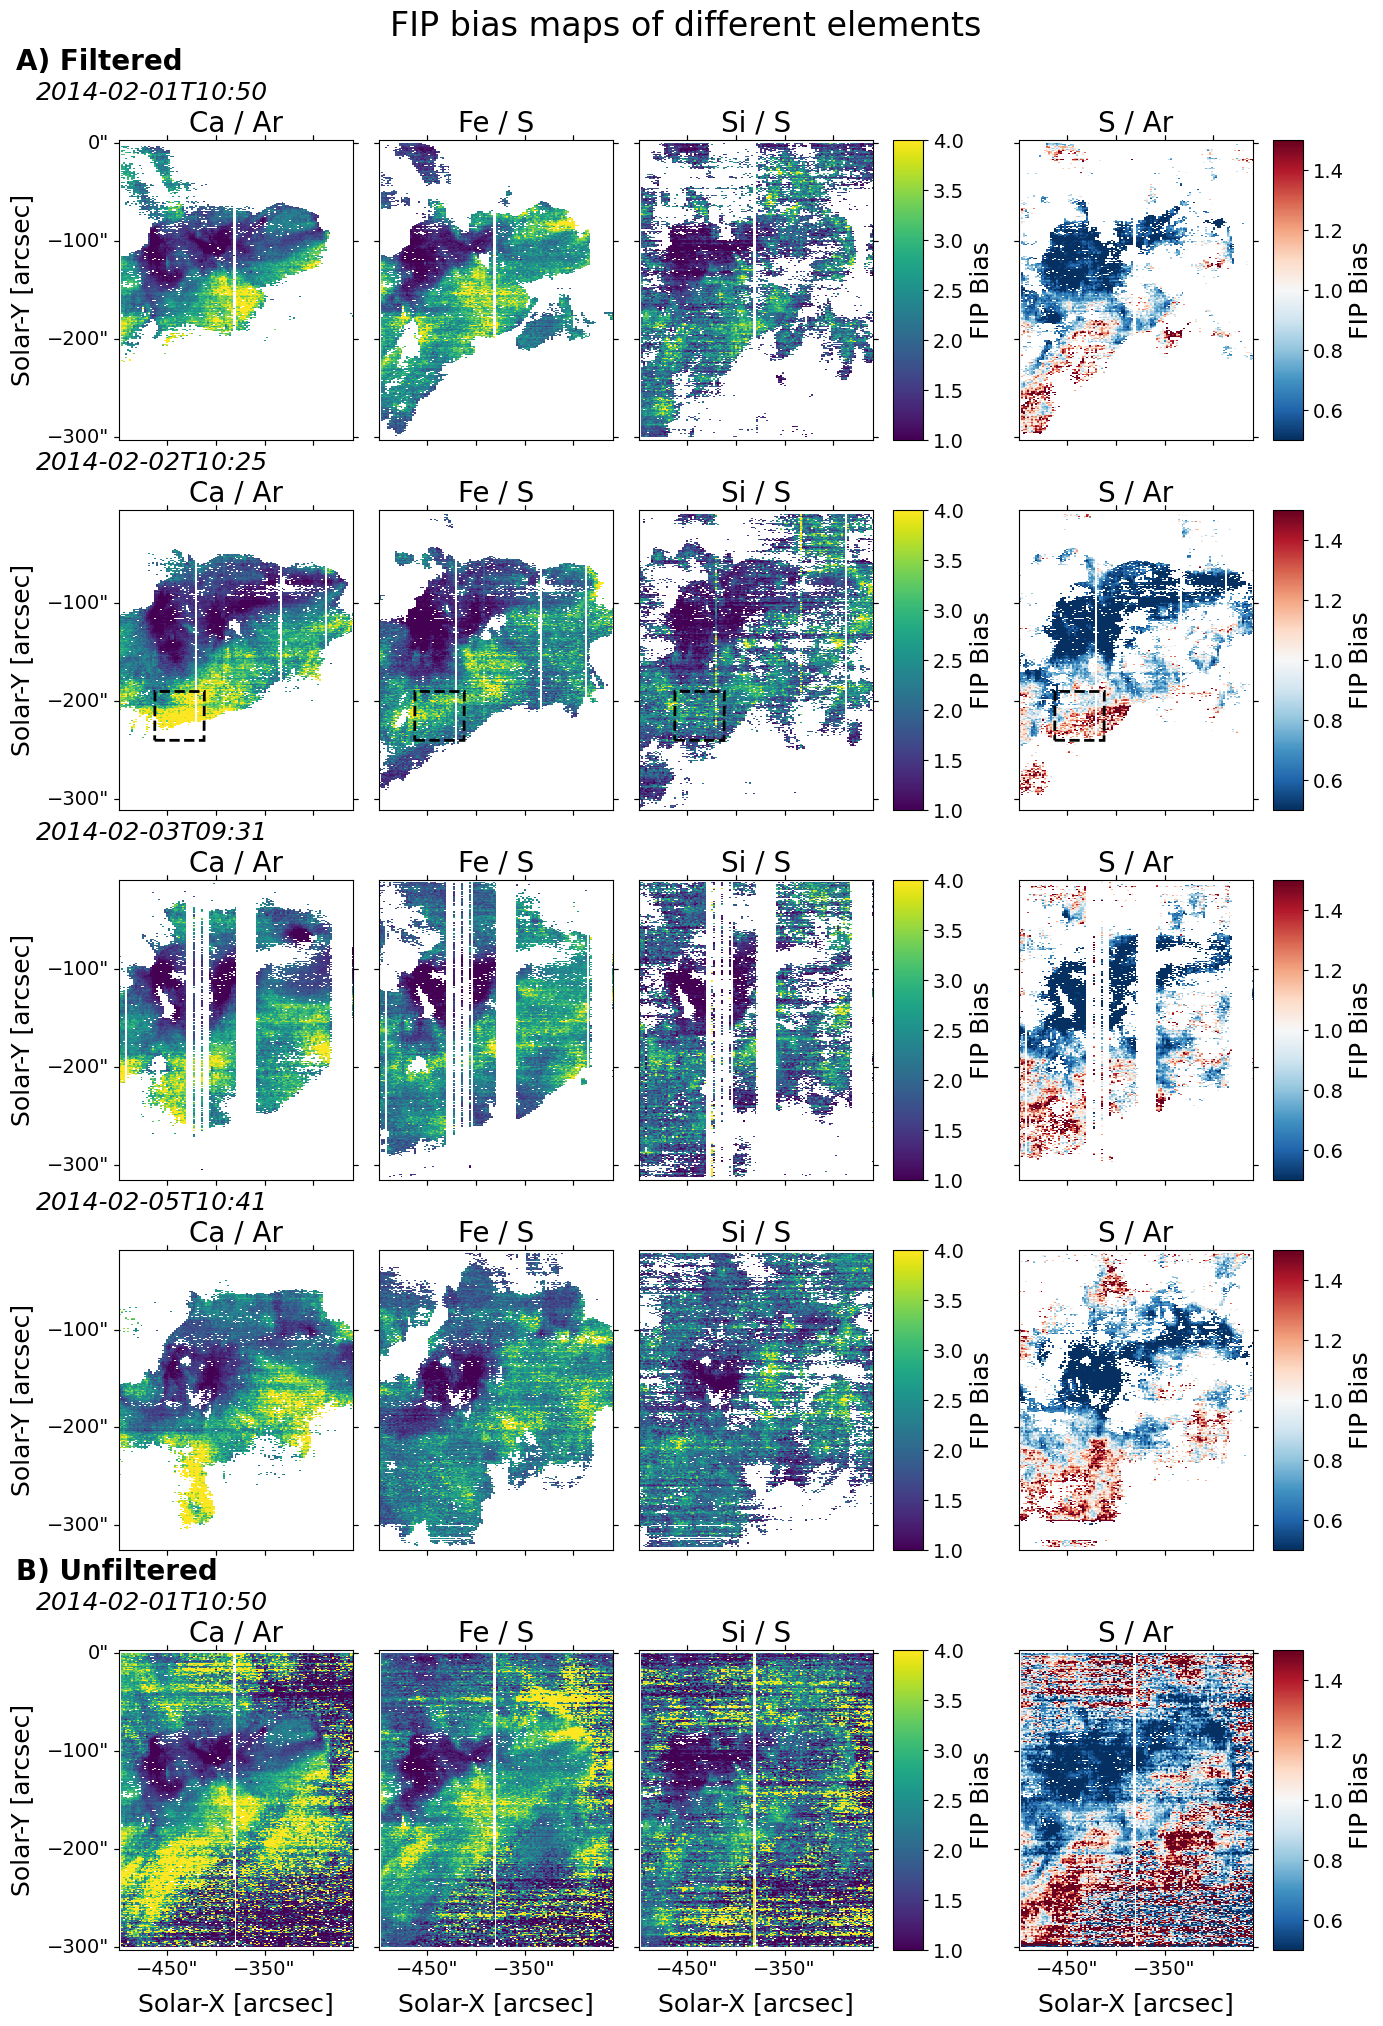

In [33]:
# Compostion maps (best)
import eispac

aligned_fits_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
fe12_map = Map(aligned_fits_path)
header_fe12 = fe12_map.meta

header_by_date = {
    "20140201_105035": Map("aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits").meta,
    "20140202_102527": Map("aligned_fe12_intensity_maps/aligned_eis_2014_02_02__10_25_27_intensity.fits").meta,
    "20140203_093134": Map("aligned_fe12_intensity_maps/aligned_eis_2014_02_03__09_31_34_intensity.fits").meta,
    "20140205_104127": Map("aligned_fe12_intensity_maps/aligned_eis_2014_02_05__10_41_27_intensity.fits").meta,
}

files_20140201_105035 = [
    ("Ca / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140201_105035/cleaned_eis_20140201_105035_sar.fits"),
]

files_20140202_102527 = [
    ("Ca / Ar – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140202_102527/cleaned_eis_20140202_102527_sar.fits"),
]

files_20140203_093134 = [
    ("Ca / Ar – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140203_093134/cleaned_eis_20140203_093134_sar.fits"),
]

files_20140205_104127 = [
    ("Ca / Ar – cleaned - labeled", "results/eis_20140205_104127/cleaned_eis_20140205_104127_CaAr.fits"),
    ("Fe / S – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_FeS.fits"),
    ("Si / S – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_sis.fits"),
    ("S / Ar – cleaned", "results/eis_20140205_104127/cleaned_eis_20140205_104127_sar.fits"),
]
files_20140201_105035_unfiltered = [
    ("Ca / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_CaAr.fits"),
    ("Fe / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_FeS.fits"),
    ("Si / S", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sis.fits"),
    ("S / Ar", "results/eis_20140201_105035/cleaned_for_plot_eis_20140201_105035_sar.fits"),
]

ylim_by_date = {
    "20140201_105035": (106, 413),
    "20140202_102527": (98, 405),
    "20140203_093134": (94, 401),
    "20140205_104127": (84, 391),
}


show_colorbar_for = {"Si / S", "S / Ar", "Si / S – cleaned", "S / Ar – cleaned"}

fig, axes = plt.subplots(5, 4, figsize=(20, 20), subplot_kw={"projection": fe12_map})
fig.suptitle("FIP bias maps of different elements", fontsize=24, y=0.97, x=0.365)
# Adjusted labels for 5-row layout
fig.text(0.03, 0.94, "A) Filtered", fontsize=20, weight="bold")
fig.text(0.03, 0.185, "B) Unfiltered", fontsize=20, weight="bold")
fig.text(0.04, 0.925, "2014-02-01T10:50", fontsize=18, style="italic")
fig.text(0.04, 0.74, "2014-02-02T10:25", fontsize=18, style="italic")
fig.text(0.04, 0.555, "2014-02-03T09:31", fontsize=18, style="italic")
fig.text(0.04, 0.37, "2014-02-05T10:41", fontsize=18, style="italic")
fig.text(0.04, 0.17, "2014-02-01T10:50", fontsize=18, style="italic")  



# Top row
# axes[0, 0].set_position([0.05, 0.48, 0.18, 0.38])
# Top row - Unfiltered
axes[0, 0].set_position([0.05, 0.755, 0.18, 0.15])
axes[0, 1].set_position([0.18, 0.755, 0.18, 0.15])
axes[0, 2].set_position([0.31, 0.755, 0.18, 0.15])
axes[0, 3].set_position([0.5, 0.755, 0.18, 0.15])

# Row 2 - 20140201_105035 cleaned
axes[1, 0].set_position([0.05, 0.57, 0.18, 0.15])
axes[1, 1].set_position([0.18, 0.57, 0.18, 0.15])
axes[1, 2].set_position([0.31, 0.57, 0.18, 0.15])
axes[1, 3].set_position([0.5, 0.57, 0.18, 0.15])

# Row 3 - 20140202_102527 cleaned
axes[2, 0].set_position([0.05, 0.385, 0.18, 0.15])
axes[2, 1].set_position([0.18, 0.385, 0.18, 0.15])
axes[2, 2].set_position([0.31, 0.385, 0.18, 0.15])
axes[2, 3].set_position([0.5, 0.385, 0.18, 0.15])

# Row 4 - 20140203_093134 cleaned
axes[3, 0].set_position([0.05, 0.2, 0.18, 0.15])
axes[3, 1].set_position([0.18, 0.2, 0.18, 0.15])
axes[3, 2].set_position([0.31, 0.2, 0.18, 0.15])
axes[3, 3].set_position([0.5, 0.2, 0.18, 0.15])

# Row 5 - 20140205_104127 cleaned
axes[4, 0].set_position([0.05, 0, 0.18, 0.15])
axes[4, 1].set_position([0.18, 0, 0.18, 0.15])
axes[4, 2].set_position([0.31, 0, 0.18, 0.15])
axes[4, 3].set_position([0.5, 0, 0.18, 0.15])

all_files = (
    files_20140201_105035 +
    files_20140202_102527 +
    files_20140203_093134 +
    files_20140205_104127 +
    files_20140201_105035_unfiltered 
)



for ax, (element, path) in zip(axes.flatten(), all_files):
    comp_data = fits.getdata(path)
    # comp_map = Map(comp_data, header_fe12)
    # extract the date tag from the path, e.g. "20140201_105035"
    date_tag = path.split("/")[1].replace("eis_", "")
    if date_tag not in header_by_date:
        print(f"[WARNING] No header found for {date_tag}, falling back to 20140201 header.")
    else:
        print(f"[OK] Using header for {date_tag}")
    header = header_by_date.get(date_tag, header_fe12)
    comp_map = Map(comp_data, header)
    
    # norm = ImageNormalize(vmin=0.5 if "S / Ar" in element else 1, vmax=1.5 if "S / Ar" in element else 4)
    # im = comp_map.plot(cmap="viridis", axes=ax, norm=norm)

    if "S / Ar" in element:
        cmap = "RdBu_r"                             # diverging for +/- from unity
        norm = ImageNormalize(vmin=0.5, vmax=1.5)
    else:
        cmap = "viridis"                              # keep sequential for others
        norm = ImageNormalize(vmin=1, vmax=4)
    im = comp_map.plot(cmap=cmap, axes=ax, norm=norm)

    # highlight ROI on 2014-02-02T10:25 only
    if date_tag == "20140202_102527":
        center = SkyCoord(Tx=(-450)*u.arcsec, Ty=(-215)*u.arcsec,
                          frame=comp_map.coordinate_frame)
        half = 25*u.arcsec 
        ll_tx_deg = (center.Tx - half).to_value(u.deg)
        ll_ty_deg = (center.Ty - half).to_value(u.deg)
        w_deg     = (2*half).to_value(u.deg)
        h_deg     = (2*half).to_value(u.deg)
    
        rect = Rectangle((ll_tx_deg, ll_ty_deg), w_deg, h_deg,
                         edgecolor="black", facecolor="none", linewidth=2, linestyle="--", 
                         transform=ax.get_transform(comp_map.coordinate_frame))
        ax.add_patch(rect)


    cleaned_label = (
        element.replace(" – cleaned - labeled", "")
               .replace(" – cleaned", "")
    )

    ax.set_title(f'{cleaned_label}', fontsize=20)
    # ax.set_ylim(106, 413)
    y0, y1 = ylim_by_date.get(date_tag, (106, 413))
    ax.set_ylim(y0, y1)
    if "Ca / Ar" in element:
        ax.set_ylabel("Solar-Y [arcsec]")
        if "– cleaned" not in element:
            ax.set_xlabel("Solar-X [arcsec]")
            ax.coords[0].set_ticklabel(visible=True)
        else:
            ax.set_xlabel("")
            ax.coords[0].set_ticklabel(visible=False)
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
        # ax.tick_params(axis='both', which='both', length=0)
    ax.grid(False)


    if element in show_colorbar_for:
        # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
        bbox = ax.get_position()
        cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
        cbar = plt.colorbar(im, cax=cax)
        cbar.set_label("FIP Bias")

    for a in axes.flatten():
        a.set_xlabel("")
        a.coords[0].set_ticklabel(visible=False)
    
    for a in axes[-1, :]:
        a.set_xlabel("Solar-X [arcsec]")
        a.coords[0].set_ticklabel(exclude_overlapping=True, visible=True)


plt.savefig(f'Composition_Maps.png', dpi=150, bbox_inches='tight')
plt.show()



2026-01-21 12:48:38 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-21 12:48:38 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


Reading fit result from, 
   /mnt/scratch/data/orlovsd2/sunpy/data/eis_20140205_104127.fe_12_195_119.2c-0.fit.h5
Number of valid pixels: 61440
Masked velocity min/max: -14.648460710372394 24.34059818857464
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]


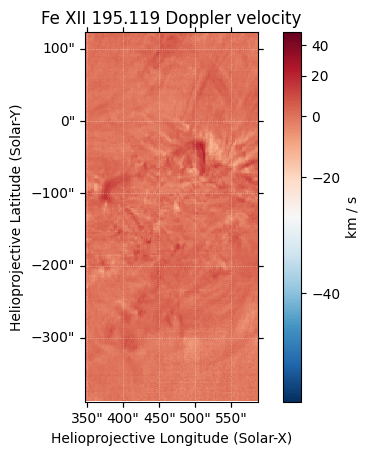

In [68]:
# Doppler Velocity

# fit_filepath = "/mnt/scratch/data/orlovsd2/sunpy/data/eis_20140203_093134.fe_12_195_119.2c-0.fit.h5"
fit_filepath = "/mnt/scratch/data/orlovsd2/sunpy/data/eis_20140205_104127.fe_12_195_119.2c-0.fit.h5"
fe12_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_05__10_41_27_intensity.fits"

fit_res = eispac.read_fit(fit_filepath)
vel_map = fit_res.get_map(component=0, measurement="vel")
vel = vel_map.data.astype(float).copy()
bad = np.abs(vel) > 500
vel_masked = np.ma.array(vel, mask=bad)
out_dir = f"{iris_dir}/doppler_velocity_maps"
# vel_out = f"{out_dir}/eis_20140203_093134_fe12_195119_doppler_velocity.fits"
vel_out = f"{out_dir}/eis_20140205_104127_fe12_195119_doppler_velocity.fits"
# vel_clean_map = Map(vel_masked, vel_map.meta)
vel_clean_map = Map(vel_masked, Map(fe12_path, silence_warnings=True).meta)
vel_clean_map.meta["BUNIT"] = "km/s"
vel_clean_map.plot_settings["norm"].vmin = -50
vel_clean_map.plot_settings["norm"].vmax = 50
vel_clean_map.save(vel_out, overwrite=True)

print("Number of valid pixels:", (~vel_masked.mask).sum())
print("Masked velocity min/max:", vel_masked.min(), vel_masked.max())
ax = vel_clean_map.plot(cmap="RdBu_r")
plt.colorbar(ax, label=str(vel_clean_map.unit))
plt.title("Fe XII 195.119 Doppler velocity")
plt.show()


In [56]:
# Open fieldline counts
open_pickles = sorted(glob.glob(f"{iris_dir}/adjusted_*_open_fieldlines.pickle"))

for p in open_pickles:
    with open(p, "rb") as f:
        open_fieldlines = pickle.load(f)
    n_open = len(open_fieldlines)
    if n_open > 0:
        print(f"{os.path.basename(p)}: n_open = {n_open}")

adjusted_eis_2014_02_02__10_25_27_open_fieldlines.pickle: n_open = 7
adjusted_eis_2014_02_03__09_31_34_open_fieldlines.pickle: n_open = 16
adjusted_eis_2014_02_05__10_41_27_open_fieldlines.pickle: n_open = 46


Files Downloaded:   0%|          | 0/4 [00:00<?, ?file/s]

HMI file used: /home/ug/orlovsd2/sunpy/data/hmi.m_45s.2014.02.05_10_41_15_TAI.magnetogram.fits
HMI map obstime: 2014-02-05T10:40:10.600


2026-01-21 12:51:13 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-21 12:51:13 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-21 12:51:13 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.
2026-01-21 12:51:13 - sunpy - INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere.


Doppler min/max: -14.648460710372394 24.34059818857464 km / s
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
HMI Min/Max: -4863.5 4863.5
Width Map Data - Min: -6.0, Max: 16383.0
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
INFO: Missing metadata for solar radius: assuming the standard radius of the photosphere. [sunpy.map.mapbase]
EIS FOV Pixel Coordinates - Bottom-left: PixelPair(x=<Quantity 528.9240628 pix>, y=<Quantity 237.50978629 pix>), Top-right: PixelPair(x=<Quantity 925.27045862 pix>, y=<Quantity 1087.62455843 pix>)


Plotting closed field lines: 100%|████████████████████████████████████████████████████████████████████████████████| 217/217 [00:08<00:00, 24.13it/s]


open_fieldlines in plot cell: 46
non-empty coords: 46


Plotting open field lines: 100%|████████████████████████████████████████████████████████████████████████████████████| 23/23 [00:01<00:00, 23.00it/s]


EIS FOV Pixel Coordinates - Bottom-left: PixelPair(x=<Quantity 528.9240628 pix>, y=<Quantity 237.50978629 pix>), Top-right: PixelPair(x=<Quantity 925.27045862 pix>, y=<Quantity 1087.62455843 pix>)


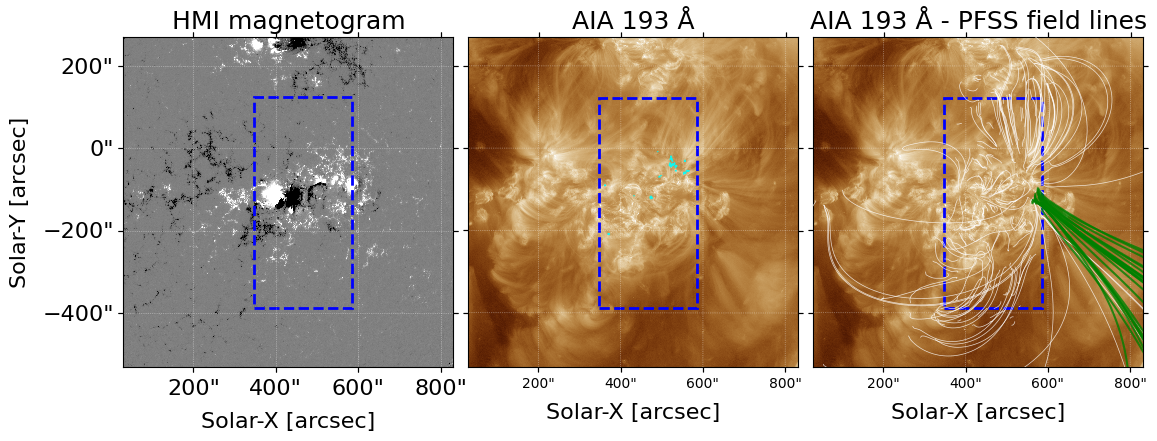

In [69]:
# HMI, AIA, AIA with PFSS
# eis_time = Time("2014-02-01T10:50:35")
# fe12_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
# width_map = sunpy.map.Map(f'{iris_dir}/AIA/aia.lev1.193A_2014_02_01T10_50_08.93Z.image_lev1.fits')

eis_time = Time("2014-02-03T09:31:34")
eis_time = Time("2014-02-05T10:41:27")
# fe12_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_03__09_31_34_intensity.fits"
fe12_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_05__10_41_27_intensity.fits"
# width_map = sunpy.map.Map(f'{iris_dir}/AIA/aia.lev1.193A_2014_02_03T09_31_30.84Z.image_lev1.fits')
width_map = sunpy.map.Map(f'{iris_dir}/AIA/aia.lev1.193A_2014_02_05T10_41_30.84Z.image_lev1.fits')

result = Fido.search(
    a.Time(eis_time - 100*u.s, eis_time + 100*u.s),
    a.Instrument("HMI"),
    a.Physobs("LOS_magnetic_field"),
    a.Source("SDO"),
    a.Provider("JSOC")
)


downloaded_files = Fido.fetch(result)
hmi_map = Map(downloaded_files[0])
print("HMI file used:", downloaded_files[0])
print("HMI map obstime:", hmi_map.date)
hmi_map.plot_settings['cmap'] = 'gray'
hmi_map.plot_settings['norm'] = plt.Normalize(-500, 500)
hmi_rotated = hmi_map.rotate(order=3)

original_time = "2014-01-29T20:00:08.22"
original_center = SkyCoord(
    (-600 + -1050) / 2 * u.arcsec,
    (0 - 350) / 2 * u.arcsec,
    frame='helioprojective',
    obstime=original_time,
    observer='earth'
)
rotated_center = solar_rotate_coordinate(original_center, time=hmi_rotated.date)

# margin = 550 * u.arcsec
margin = 400 * u.arcsec

new_bottom_left = SkyCoord(
    rotated_center.Tx - margin, rotated_center.Ty - margin, frame=hmi_rotated.coordinate_frame
)
new_top_right = SkyCoord(
    rotated_center.Tx + margin, rotated_center.Ty + margin, frame=hmi_rotated.coordinate_frame
)

# Crop the rotated HMI map
hmi_rotated = hmi_rotated.submap(new_bottom_left, top_right=new_top_right)

cropping = True

if cropping:
    original_time = "2014-01-29T20:00:08.22"
    original_center = SkyCoord(
        (-600 + -1050) / 2 * u.arcsec, 
        (0 - 350) / 2 * u.arcsec, 
        frame='helioprojective',
        obstime=original_time,
        observer='earth'
    )
    
    
    rotated_center = solar_rotate_coordinate(original_center, time=width_map.date)

    # margin = 550 * u.arcsec
    margin = 400 * u.arcsec

    new_bottom_left = SkyCoord(
        rotated_center.Tx - margin, rotated_center.Ty - margin, frame=width_map.coordinate_frame
    )
    new_top_right = SkyCoord(
        rotated_center.Tx + margin, rotated_center.Ty + margin, frame=width_map.coordinate_frame
    )
    
    cropped_map = width_map.submap(new_bottom_left, top_right=new_top_right)
    map_to_plot = cropped_map  # Use cropped version
else:
    map_to_plot = width_map  # Use the full map if cropping is disabled

fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 3, 1, projection=hmi_rotated)
ax2 = fig.add_subplot(1, 3, 2, projection=map_to_plot)
ax3 = fig.add_subplot(1, 3, 3, projection=map_to_plot)
axes = [ax1, ax2, ax3]
axes[0].set_position([0.05, 0.14, 0.22, 0.72])
axes[1].set_position([0.28, 0.14, 0.22, 0.72])
axes[2].set_position([0.51, 0.14, 0.22, 0.72])


# # Create figure and plot the HMI map
# fig = plt.figure(figsize=(5,5))
# ax = plt.subplot(projection=hmi_rotated)
ax = axes[0]

hmi_rotated.plot(axes=ax)
ax.set_xlabel("Solar-X [arcsec]", fontsize=16)
ax.set_ylabel("Solar-Y [arcsec]", fontsize=16)
axes[0].tick_params(axis='both', labelsize=16)


fe12_map = Map(fe12_path, silence_warnings=True)

# vel_path = f"{iris_dir}/doppler_velocity_maps/eis_20140203_093134_fe12_195119_doppler_velocity.fits"
vel_path = f"{iris_dir}/doppler_velocity_maps/eis_20140205_104127_fe12_195119_doppler_velocity.fits"
vel_clean_map = Map(vel_path)

print("Doppler min/max:", np.nanmin(vel_clean_map.data), np.nanmax(vel_clean_map.data), vel_clean_map.unit)

# Get EIS corners in world coordinates
bottom_left = fe12_map.bottom_left_coord
top_right = fe12_map.top_right_coord

# Convert those to HMI pixel coordinates
bl_pix = hmi_rotated.wcs.world_to_pixel(bottom_left)
tr_pix = hmi_rotated.wcs.world_to_pixel(top_right)

# Create rectangle patch for EIS FOV
rect = Rectangle((bl_pix[0], bl_pix[1]), tr_pix[0] - bl_pix[0], tr_pix[1] - bl_pix[1], 
                 edgecolor='blue', facecolor='none', linestyle='--', linewidth=2)

# Add rectangle to plot
ax.add_patch(rect)
# plt.tight_layout()
plt.title(f'HMI magnetogram', fontsize=18)
# plt.show()
print("HMI Min/Max:", np.nanmin(hmi_map.data), np.nanmax(hmi_map.data))


# AIA at the base, EIS FOV on top, with PFSS closed and opened fields

# fig = plt.figure(figsize=(5,5))
print(f"Width Map Data - Min: {np.nanmin(width_map.data)}, Max: {np.nanmax(width_map.data)}")



# AIA only
# fig = plt.figure(figsize=(5,5))
ax = axes[1]

# for i,m in enumerate([map_to_plot]):
    # ax = fig.add_subplot(1,1,i+1,projection=m)
map_to_plot.plot(axes=ax, vmin=0, vmax=9600)
bounds = ax.axis()

upflow_levels = [-10] * u.km/u.s
vel_clean_map.draw_contours(upflow_levels, axes=ax, colors='cyan', linewidths=1.2, alpha=0.9)
ax.axis(bounds)

ax.set_title('AIA 193 Å', fontsize=18)
# ax.set_xlabel('Solar-X (arcsec)', fontsize=14)
# ax.set_ylabel('Solar-Y (arcsec)', fontsize=14)
# ax.tick_params(axis='both', labelsize=12)


# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
ax.set_xlabel("Solar-X [arcsec]", fontsize=16)
ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=True)
ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
# ax.tick_params(axis='both', which='both', length=0)

# Plot EIS FOV rectangle
bottom_left = eis_map.bottom_left_coord
top_right = eis_map.top_right_coord


bl_pixel = map_to_plot.world_to_pixel(bottom_left)
tr_pixel = map_to_plot.world_to_pixel(top_right)
print(f"EIS FOV Pixel Coordinates - Bottom-left: {bl_pixel}, Top-right: {tr_pixel}")

rect = Rectangle((bl_pixel.x.value, bl_pixel.y.value), 
                 tr_pixel.x.value - bl_pixel.x.value, 
                 tr_pixel.y.value - bl_pixel.y.value, 
                 edgecolor='blue', facecolor='none', linestyle='--', linewidth=2)
ax.add_patch(rect)
ax.axis(bounds)


# fig = plt.figure(figsize=(5,5))
ax = axes[2]

# for i,m in enumerate([map_to_plot]):
    # ax = fig.add_subplot(1,1,i+1,projection=m)
map_to_plot.plot(axes=ax, vmin=0, vmax=9600)
# m.plot()
bounds = ax.axis()
ax.set_title('AIA 193 Å - PFSS field lines', fontsize=18)

# ax.set_xlabel("")
# ax.set_ylabel("")
# ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
ax.set_xlabel("Solar-X [arcsec]", fontsize=16)
ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=True)
ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
# ax.tick_params(axis='both', which='both', length=0)


# Plot closed field lines in white
if closed_fieldlines:
    for c in tqdm(closed_fieldlines[::20], desc="Plotting closed field lines"):
        coords = c.coords
        if coords.shape[0] > 0:
            coords_updated = change_obstime(coords, map_to_plot.date)
            ax.plot_coord(coords_updated, lw=0.5, color='white', alpha=0.8)

print("open_fieldlines in plot cell:", len(open_fieldlines))
print("non-empty coords:", sum(getattr(c, "coords", None) is not None and c.coords.shape[0] > 0 for c in open_fieldlines))


# Plot open field lines in blue
if open_fieldlines:
    for c in tqdm(open_fieldlines[::2], desc="Plotting open field lines"):
        coords = c.coords
        if coords.shape[0] > 0:
            coords_updated = change_obstime(coords, map_to_plot.date)
            ax.plot_coord(coords_updated, lw=1.5, color='green', alpha=0.8)

#rectangle
bottom_left = eis_map.bottom_left_coord
top_right = eis_map.top_right_coord
# Convert world coordinates to pixel coordinates in AIA map
bl_pixel = map_to_plot.world_to_pixel(bottom_left)
tr_pixel = map_to_plot.world_to_pixel(top_right)

print(f"EIS FOV Pixel Coordinates - Bottom-left: {bl_pixel}, Top-right: {tr_pixel}")

# Draw rectangle on AIA map
rect = Rectangle((bl_pixel.x.value, bl_pixel.y.value), 
                 tr_pixel.x.value - bl_pixel.x.value, 
                 tr_pixel.y.value - bl_pixel.y.value, 
                 edgecolor='blue', facecolor='none', linestyle='--', linewidth=2)

ax.add_patch(rect)
ax.axis(bounds)


# fig.savefig('Daves_IRIS_paper_PFSS.pdf',dpi=150)
# plt.tight_layout()
plt.savefig(f'HMI_AIA_PFSS.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# Intensity Maps (old)

import eispac

aligned_fits_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
fe12_map = Map(aligned_fits_path)
header_fe12 = fe12_map.meta

files = [
    ("Ca XIV", "intensity_map/2014_02_01__10_50_35_ca14193_87.fits"),
    ("Fe XVI", "intensity_map/2014_02_01__10_50_35_fe16262_98.fits"),
    ("Si X", "intensity_map/2014_02_01__10_50_35_si10258_37.fits"),
    ("S XI", "intensity_map/2014_02_01__10_50_35_s11188_68.fits"),
]

# show_colorbar_for = {"Si X", "S XI"}

fig, axes = plt.subplots(1, 4, figsize=(20, 5), subplot_kw={"projection": fe12_map})
# plt.subplots_adjust(wspace=0.8)
axes[0].set_position([0.05, 0.07, 0.18, 0.75])
axes[1].set_position([0.27, 0.07, 0.18, 0.75])
axes[2].set_position([0.495, 0.07, 0.18, 0.75])
axes[3].set_position([0.715, 0.07, 0.18, 0.75])

fig.suptitle("Intensity maps of diagnostic lines", fontsize=24, y=0.96)
for ax, (element, path) in zip(axes, files):
    comp_data = fits.getdata(path)
    comp_map = Map(comp_data, header_fe12)

    vmin = np.nanpercentile(comp_data, 1)
    vmax = np.nanpercentile(comp_data, 99)
    norm = ImageNormalize(vmin=vmin, vmax=vmax)


    im = comp_map.plot(cmap="inferno", axes=ax, norm=norm)
    # ax.set_title(f'{element}', fontsize=13)
    # ax.set_ylim(106, 413)
    # ax.grid(False)
    # bbox = ax.get_position()
    # cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.01, bbox.height])
    # cbar = plt.colorbar(im, cax=cax)
    # cbar.set_label("Counts")
    ax.set_title(f'{element}', fontsize=20)
    ax.set_ylim(106, 413)
    ax.grid(False)
    
    if element == "Ca XIV":
        ax.set_xlabel("Solar-X [arcsec]")
        ax.set_ylabel("Solar-Y [arcsec]")
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.tick_params(axis='both', which='both', length=0)
    
    bbox = ax.get_position()
    cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label("Counts")

    # if element in show_colorbar_for:
    #     # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    #     bbox = ax.get_position()
    #     cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
    #     cbar = plt.colorbar(im, cax=cax)
    #     cbar.set_label("FIP Bias")

plt.savefig(f'Intensity_Maps_2014_02_01_105035.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# Intensity Maps

import eispac

aligned_fits_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
fe12_map = Map(aligned_fits_path)
header_fe12 = fe12_map.meta

files = [
    ("Ca XIV", "intensity_map/2014_02_01__10_50_35_ca14193_87.fits"),
    ("Fe XVI", "intensity_map/2014_02_01__10_50_35_fe16262_98.fits"),
    ("Si X", "intensity_map/2014_02_01__10_50_35_si10258_37.fits"),
    ("S XI", "intensity_map/2014_02_01__10_50_35_s11188_68.fits"),
    ("Ar XIV", "intensity_map/2014_02_01__10_50_35_ar14194_40.fits"),
    ("S XIII", "intensity_map/2014_02_01__10_50_35_s13256_69.fits"),
    ("S X", "intensity_map/2014_02_01__10_50_35_s10264_23.fits"),
    ("Ar XI", "intensity_map/2014_02_01__10_50_35_ar11188_81.fits"),
]

# show_colorbar_for = {"Si X", "S XI"}

fig, axes = plt.subplots(2, 4, figsize=(20, 10), subplot_kw={"projection": fe12_map})
# plt.subplots_adjust(wspace=0.8)
# Row 1 (y ~ 0.55–0.75)
axes[0, 0].set_position([0.05, 0.56, 0.18, 0.35])
axes[0, 1].set_position([0.27, 0.56, 0.18, 0.35])
axes[0, 2].set_position([0.495, 0.56, 0.18, 0.35])
axes[0, 3].set_position([0.715, 0.56, 0.18, 0.35])

# Row 2 (y ~ 0.05–0.35)
axes[1, 0].set_position([0.05, 0.145, 0.18, 0.35])
axes[1, 1].set_position([0.27, 0.145, 0.18, 0.35])
axes[1, 2].set_position([0.495, 0.145, 0.18, 0.35])
axes[1, 3].set_position([0.715, 0.145, 0.18, 0.35])

fig.suptitle("Intensity maps of diagnostic lines", fontsize=24, y=0.99)
for ax, (element, path) in zip(axes.flatten(), files):
    comp_data = fits.getdata(path)
    comp_map = Map(comp_data, header_fe12)

    vmin = np.nanpercentile(comp_data, 1)
    vmax = np.nanpercentile(comp_data, 99)
    norm = ImageNormalize(vmin=vmin, vmax=vmax)


    im = comp_map.plot(cmap="inferno", axes=ax, norm=norm)
    # ax.set_title(f'{element}', fontsize=13)
    # ax.set_ylim(106, 413)
    # ax.grid(False)
    # bbox = ax.get_position()
    # cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.01, bbox.height])
    # cbar = plt.colorbar(im, cax=cax)
    # cbar.set_label("Counts")
    ax.set_title(f'{element}', fontsize=20)
    ax.set_ylim(106, 413)
    ax.grid(False)
    
    if element == "Ar XIV":
        ax.set_xlabel("Solar-X [arcsec]")
        ax.set_ylabel("Solar-Y [arcsec]")
    else:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.coords[0].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.coords[1].set_ticklabel(exclude_overlapping=True, visible=False)
        ax.tick_params(axis='both', which='both', length=0)
    
    bbox = ax.get_position()
    cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
    cbar = plt.colorbar(im, cax=cax)
    cbar.set_label("Counts")

    # if element in show_colorbar_for:
    #     # cbar = plt.colorbar(im, ax=ax, orientation='vertical', pad=0.02)
    #     bbox = ax.get_position()
    #     cax = fig.add_axes([bbox.x1 + 0.01, bbox.y0, 0.015, bbox.height])
    #     cbar = plt.colorbar(im, cax=cax)
    #     cbar.set_label("FIP Bias")

plt.savefig(f'Intensity_Maps_2014_02_01_105035.png', dpi=150, bbox_inches='tight')
plt.show()



In [ ]:
# All Compositon Maps

import matplotlib.pyplot as plt
from astropy.io import fits
from sunpy.map import Map
from matplotlib.colors import Normalize
from astropy.visualization import ImageNormalize
import os

# Use FE XII header as reference projection
aligned_fits_path = "aligned_fe12_intensity_maps/aligned_eis_2014_02_01__10_50_35_intensity.fits"
header_fe12 = Map(aligned_fits_path).meta
fe12_map = Map(aligned_fits_path)

# Define all file paths
timestamps = [
    "20140201_105035", "20140201_125441",
    "20140202_102527", "20140202_122934", "20140202_141952",
    "20140203_093134", "20140203_113540",
    "20140205_104127", "20140205_124534",
]

element_pairs = {
    "Ca / Ar": "CaAr",
    "Fe / S": "FeS",
    "Si / S": "sis",
    "S / Ar": "sar",
}

# Group file paths by element
all_files = {label: [f"results/eis_{t}/cleaned_eis_{t}_{short}.fits"
                     for t in timestamps] for label, short in element_pairs.items()}

# Extract timestamps in readable format
readable_labels = [t[:8] + "T" + t[9:] for t in timestamps]

# Create 9×4 grid (rows = rasters, cols = element ratios)
fig, axes = plt.subplots(9, 4, figsize=(22, 38), subplot_kw={"projection": fe12_map})
fig.suptitle("Cleaned FIP Bias Maps", fontsize=24, y=0.92)

# Choose which colorbars to show
show_colorbar_for = {"Si / S", "S / Ar"}

for row_idx, timestamp in enumerate(readable_labels):
    for col_idx, (label, file_list) in enumerate(all_files.items()):
        ax = axes[row_idx, col_idx]
        path = file_list[row_idx]
        comp_data = fits.getdata(path)
        comp_map = Map(comp_data, header_fe12)

        # Adjust normalization range
        norm = ImageNormalize(vmin=0.5 if "S / Ar" in label else 1,
                              vmax=1.5 if "S / Ar" in label else 4)
        
        im = comp_map.plot(axes=ax, cmap="viridis", norm=norm)
        ax.set_title(f"{label} — {timestamp}", fontsize=10)

        # if timestamp in {"20140201T105035", "20140202T102527", "20140203T093134", "20140205T104127"}:
        #     ax.set_ylim(106, 413)

        ax.grid(True)

        # Show tick labels
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.coords[0].set_ticklabel(visible=True)
        ax.coords[1].set_ticklabel(visible=True)
        # Add colorbar for selected ratios
        if label in show_colorbar_for:
            bbox = ax.get_position()
            cax = fig.add_axes([bbox.x1 + 0.005, bbox.y0, 0.01, bbox.height])
            cbar = plt.colorbar(im, cax=cax)
            cbar.set_label("FIP Bias")
plt.savefig("All_Composition.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# All HMI Maps

# Time strings and FE XII file paths
timestamps = [
    "2014-02-01T10:50:35", "2014-02-01T12:54:41",
    "2014-02-02T10:25:27", "2014-02-02T12:29:34", "2014-02-02T14:19:52",
    "2014-02-03T09:31:34", "2014-02-03T11:35:40",
    "2014-02-05T10:41:27", "2014-02-05T12:45:34",
]
fe12_paths = [
    f"aligned_fe12_intensity_maps/aligned_eis_{t.replace('-', '_').replace(':', '_').replace('T', '__')}_intensity.fits"
    for t in timestamps
]

# Umbra-centered crop reference
original_time = "2014-01-29T20:00:08.22"
original_center = SkyCoord(
    (-600 + -1050) / 2 * u.arcsec,
    (0 - 350) / 2 * u.arcsec,
    frame='helioprojective',
    obstime=original_time,
    observer='earth'
)
margin = 550 * u.arcsec

# Plot setup
fig, axes = plt.subplots(3, 3, figsize=(18, 18), subplot_kw={'projection': None})
fig.suptitle('HMI Magnetograms with EIS FOV Overlay', fontsize=26, y=0.92)
axes = axes.flatten()

for i, (eis_time_str, fe12_path) in enumerate(zip(timestamps, fe12_paths)):
    eis_time = Time(eis_time_str)
    ax = axes[i]

    # Download HMI magnetogram
    result = Fido.search(
        a.Time(eis_time - 300*u.s, eis_time + 300*u.s),
        a.Instrument("HMI"),
        a.Physobs("LOS_magnetic_field"),
        a.Source("SDO"),
        a.Provider("JSOC")
    )
    downloaded_files = Fido.fetch(result)
    hmi_map = Map(downloaded_files[0])
    hmi_map.plot_settings['cmap'] = 'gray'
    hmi_map.plot_settings['norm'] = plt.Normalize(-500, 500)

    # Rotate and crop HMI
    hmi_rotated = hmi_map.rotate(order=3)
    rotated_center = solar_rotate_coordinate(original_center, time=hmi_rotated.date)
    new_bottom_left = SkyCoord(
        rotated_center.Tx - margin,
        rotated_center.Ty - margin,
        frame=hmi_rotated.coordinate_frame
    )
    new_top_right = SkyCoord(
        rotated_center.Tx + margin,
        rotated_center.Ty + margin,
        frame=hmi_rotated.coordinate_frame
    )
    hmi_rotated = hmi_rotated.submap(new_bottom_left, top_right=new_top_right)

    # FE XII map for FOV overlay
    fe12_map = Map(fe12_path, silence_warnings=True)
    bottom_left = fe12_map.bottom_left_coord
    top_right = fe12_map.top_right_coord

    bl_pix = hmi_rotated.wcs.world_to_pixel(bottom_left)
    tr_pix = hmi_rotated.wcs.world_to_pixel(top_right)

    # Plotting
    ax = plt.subplot(3, 3, i+1, projection=hmi_rotated)
    hmi_rotated.plot(axes=ax)
    ax.set_xlabel("Solar-X [arcsec]", fontsize=13)
    ax.set_ylabel("Solar-Y [arcsec]", fontsize=13)
    ax.tick_params(axis='both', labelsize=11)

    # Add rectangle showing EIS FOV
    rect = Rectangle((bl_pix[0], bl_pix[1]), tr_pix[0] - bl_pix[0], tr_pix[1] - bl_pix[1], 
                     edgecolor='blue', facecolor='none', linestyle='--', linewidth=2)
    ax.add_patch(rect)

    ax.set_title(f"HMI: {eis_time_str}", fontsize=14)

plt.tight_layout()
plt.subplots_adjust(top=0.92, hspace=0.35)
plt.savefig("All_HMI.png", dpi=300, bbox_inches="tight")
plt.show()
